# Part A

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load Data
customers = pd.read_csv("customers_dirty.csv")
accounts = pd.read_csv("accounts_dirty.csv")
usage = pd.read_csv("usage_churn_dirty.csv")

In [4]:
# Step 2: Strip and Clean CustomerID
for df in [customers, accounts, usage]:
    df['CustomerID'] = df['CustomerID'].astype(str).str.strip()

In [5]:
# Step 3: Merge All Datasets on CustomerID (Inner Join to ensure consistency)
df_merged = customers.merge(accounts, on='CustomerID', how='inner')\
                     .merge(usage, on='CustomerID', how='inner')


In [6]:
# Step 4: Clean 'Gender' column
df_merged['Gender'] = df_merged['Gender'].str.strip().str.lower().map({
    'male': 'Male', 'female': 'Female', 'f': 'Female', 'non-binary': 'Non-Binary',
    'prefer not to say': 'Prefer not to say'
})
# Step 5: Clean 'Location'
df_merged['Location'] = df_merged['Location'].str.strip().str.title().replace({
    'City Center': 'Urban'
})
# Step 6: Clean 'HasPartner' and 'HasDependents'
yes_values = ['Yes', 'yes', 'TRUE', 'True']
df_merged['HasPartner'] = df_merged['HasPartner'].isin(yes_values).astype(int)
df_merged['HasDependents'] = df_merged['HasDependents'].isin(yes_values).astype(int)

# Step 7: Clean 'PaperlessBilling'
df_merged['PaperlessBilling'] = df_merged['PaperlessBilling'].isin(yes_values).astype(int)

# Step 8: Handle TotalCharges (convert to numeric)
df_merged['TotalCharges'] = pd.to_numeric(df_merged['TotalCharges'], errors='coerce')

# Step 9: Handle Age (outlier removal and imputation)
df_merged['Age'] = pd.to_numeric(df_merged['Age'], errors='coerce')
df_merged['Age'] = df_merged['Age'].mask((df_merged['Age'] < 18) | (df_merged['Age'] > 100), np.nan)
df_merged['Age'].fillna(df_merged['Age'].median(), inplace=True)
df_merged['Age'] = df_merged['Age'].astype(int)

# Step 10: Clean NumSupportTickets
df_merged['NumSupportTickets'] = pd.to_numeric(df_merged['NumSupportTickets'], errors='coerce')
df_merged['NumSupportTickets'].fillna(df_merged['NumSupportTickets'].median(), inplace=True)
df_merged['NumSupportTickets'] = df_merged['NumSupportTickets'].astype(int)

# Step 11: Clean AvgMonthlyGBData
df_merged['AvgMonthlyGBData'] = pd.to_numeric(df_merged['AvgMonthlyGBData'], errors='coerce')
df_merged['AvgMonthlyGBData'].fillna(df_merged['AvgMonthlyGBData'].median(), inplace=True)

# Step 12: Clean MonthlyCharges
df_merged['MonthlyCharges'] = pd.to_numeric(df_merged['MonthlyCharges'], errors='coerce')
df_merged['MonthlyCharges'].fillna(df_merged['MonthlyCharges'].median(), inplace=True)


In [7]:
# Step 13: Impute TotalCharges where missing using MonthlyCharges * TenureMonths
df_merged['TotalCharges'].fillna(df_merged['MonthlyCharges'] * df_merged['TenureMonths'], inplace=True)

In [8]:
# Final: Check and Save Clean Dataset
df_merged.to_csv("cleaned_base_table.csv", index=False)
print("Merged and cleaned dataset saved as 'cleaned_base_table.csv'")

Merged and cleaned dataset saved as 'cleaned_base_table.csv'


### EDA

In [9]:
df = pd.read_csv("cleaned_base_table.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         5000 non-null   object 
 1   Gender             4726 non-null   object 
 2   Age                5000 non-null   int64  
 3   Location           4761 non-null   object 
 4   HasPartner         5000 non-null   int64  
 5   HasDependents      5000 non-null   int64  
 6   ContractType       5000 non-null   object 
 7   SubscriptionPlan   5000 non-null   object 
 8   PaymentMethod      4605 non-null   object 
 9   PaperlessBilling   5000 non-null   int64  
 10  MonthlyCharges     5000 non-null   float64
 11  TotalCharges       5000 non-null   float64
 12  TenureMonths       5000 non-null   int64  
 13  NumSupportTickets  5000 non-null   int64  
 14  AvgMonthlyGBData   5000 non-null   float64
 15  Churn              5000 non-null   int64  
 16  cluster            5000 

Text(0.5, 1.0, 'Churn Distribution')

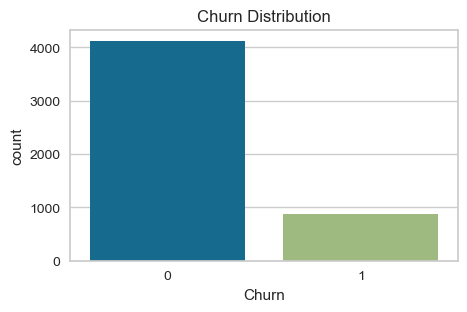

In [29]:
# ----------- 1. Basic Data Overview ----------- #
basic_info = df.info()
missing_values = df.isnull().sum()
summary_stats = df.describe(include='all')

plt.figure(figsize=(5, 3))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")


Text(0.5, 1.0, 'Correlation Heatmap')

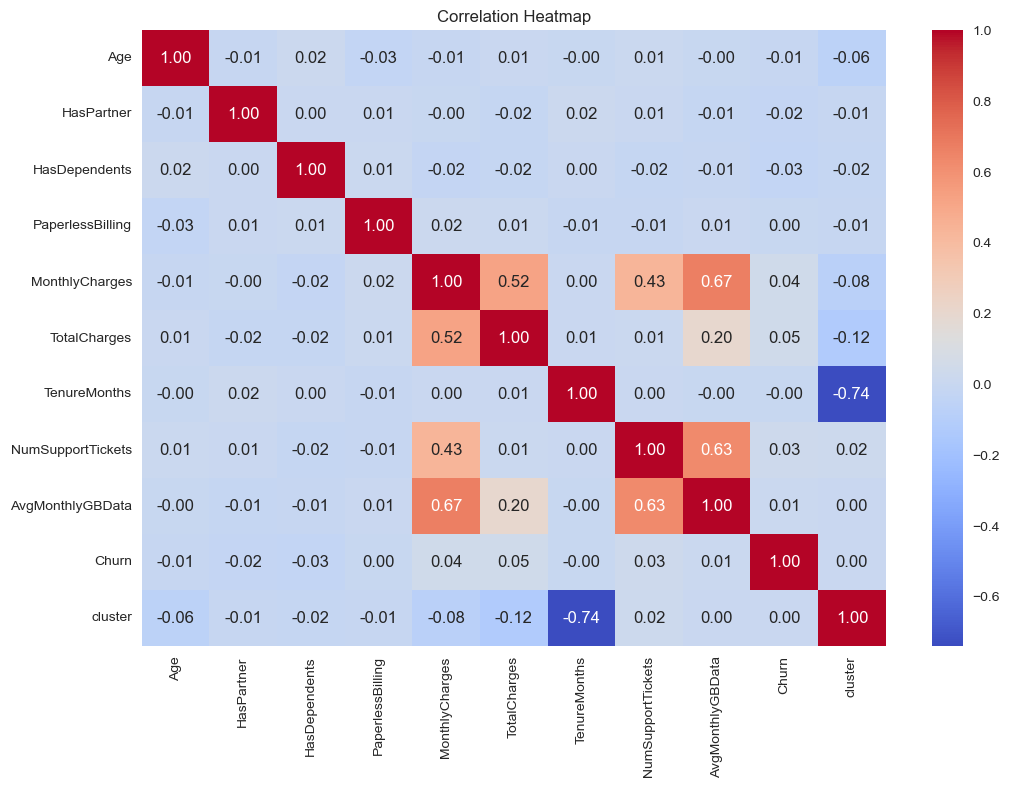

In [31]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")

# Use this to drop redundant features or identify useful ones (e.g., TotalCharges, TenureMonths)


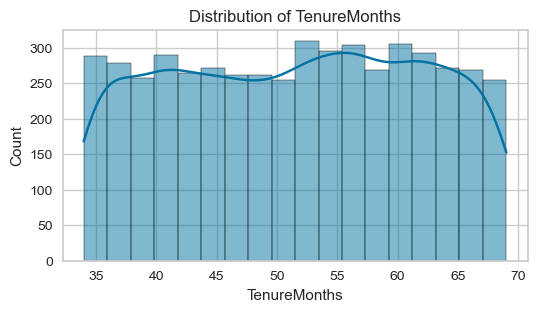

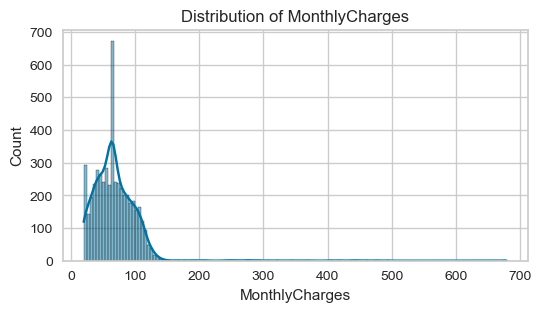

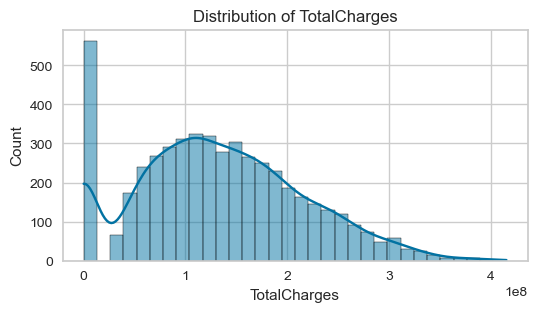

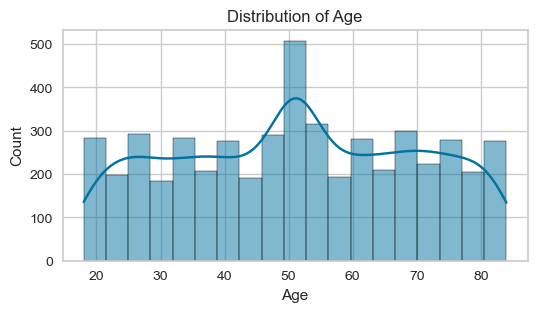

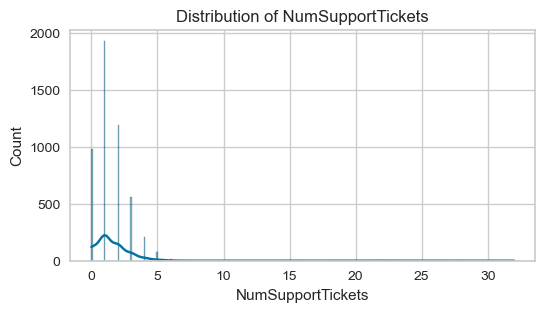

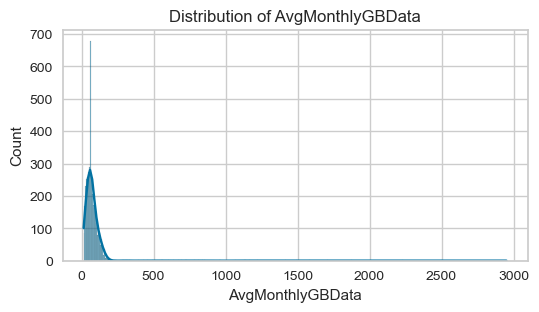

In [32]:
# ----------- 3. Distribution Plots of Key Features ----------- #
# Look for skewness, outliers

# Distribution plots
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
for col in features:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")


# Skewed distributions may need transformation (e.g., log-scale) before clustering


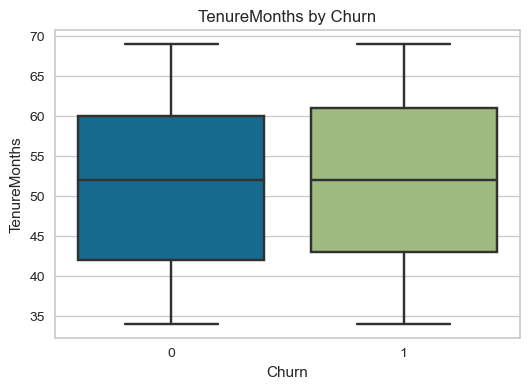

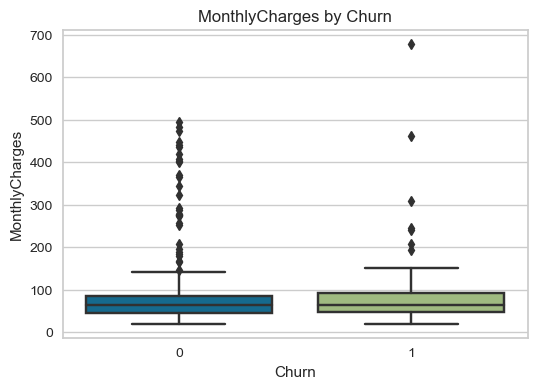

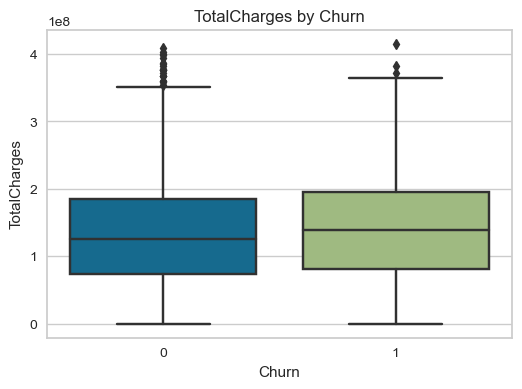

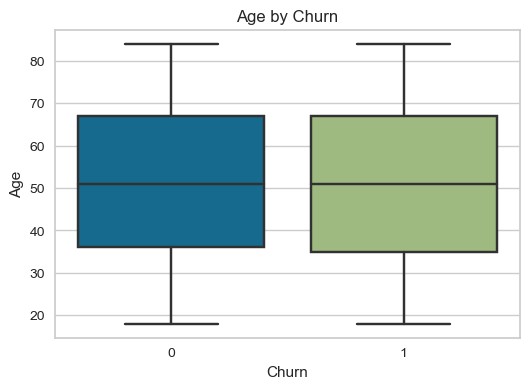

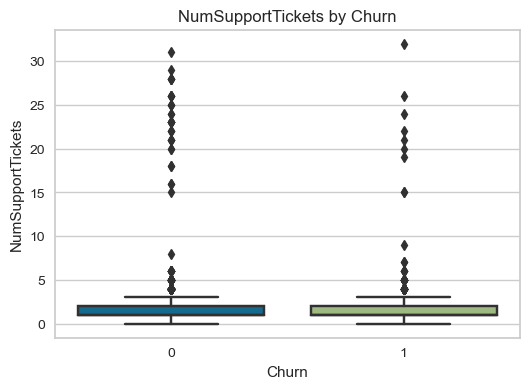

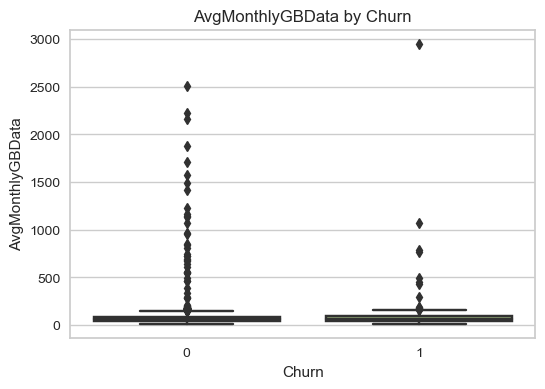

In [33]:
# ----------- 4. Boxplots vs Churn ----------- #
# Find features that differ significantly across churned vs non-churned customers
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"{col} by Churn")


# Features with large differences are strong churn predictors


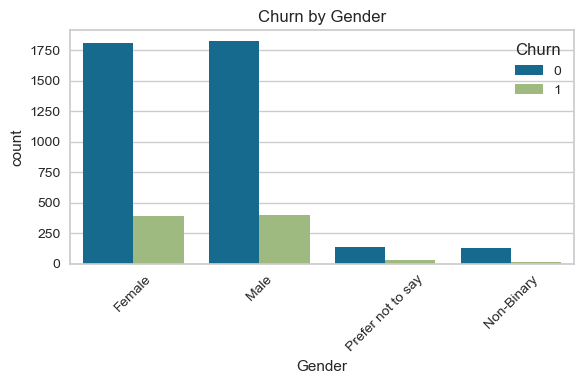

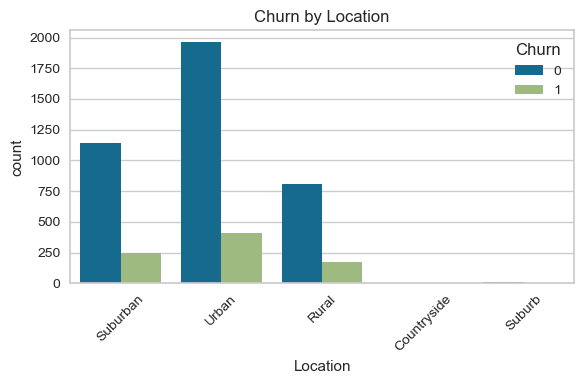

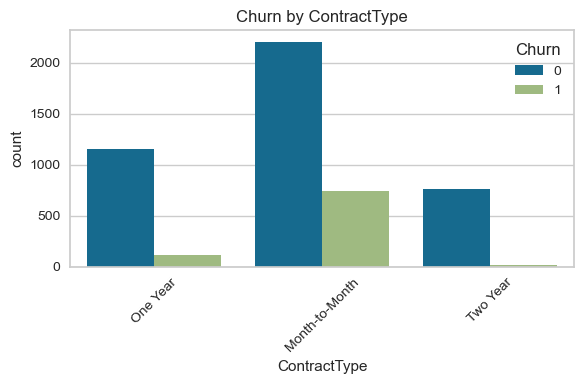

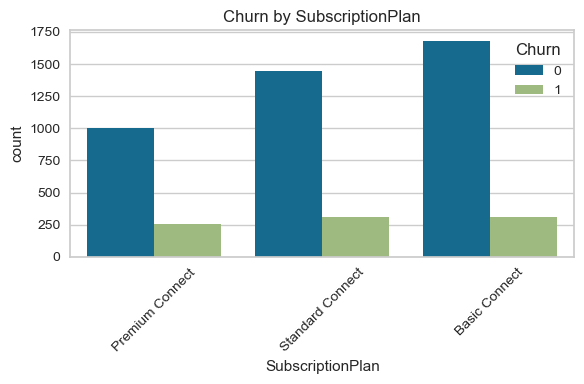

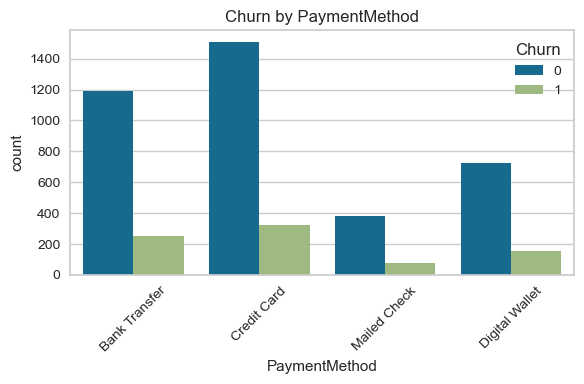

In [34]:
# ----------- 5. Categorical Feature Analysis ----------- #
categoricals = ['Gender', 'Location', 'ContractType', 'SubscriptionPlan', 'PaymentMethod']
for col in categoricals:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()


# Use this to one-hot encode and prioritize features with visible class differences


Text(0.5, 1.0, 'Distribution: Support Tickets per Month')

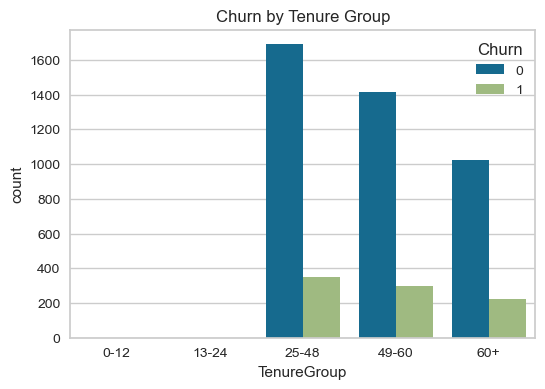

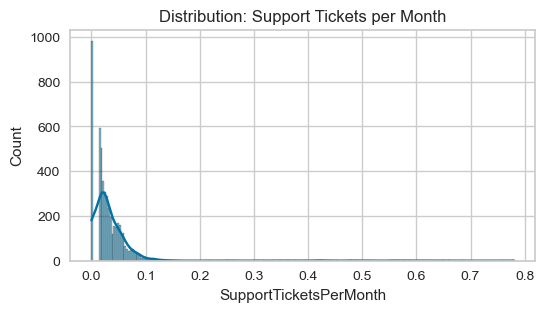

In [35]:
# ----------- 6. Feature Engineering ----------- #
# Create tenure categories
if 'TenureGroup' not in df.columns:
    df['TenureGroup'] = pd.cut(df['TenureMonths'],
                               bins=[0, 12, 24, 48, 60, df['TenureMonths'].max()],
                               labels=['0-12', '13-24', '25-48', '49-60', '60+'])

if 'SupportTicketsPerMonth' not in df.columns:
    df['SupportTicketsPerMonth'] = df['NumSupportTickets'] / df['TenureMonths']
    df['SupportTicketsPerMonth'].fillna(0, inplace=True)

# Tenure group churn plot
plt.figure(figsize=(6, 4))
sns.countplot(x='TenureGroup', hue='Churn', data=df)
plt.title("Churn by Tenure Group")


# Support tickets per month plot
plt.figure(figsize=(6, 3))
sns.histplot(df['SupportTicketsPerMonth'], kde=True)
plt.title("Distribution: Support Tickets per Month")


# TenureGroup can be used for segmentation (KMeans) and for model interpretability
# SupportTicketsPerMonth may signal dissatisfaction → useful for churn prediction


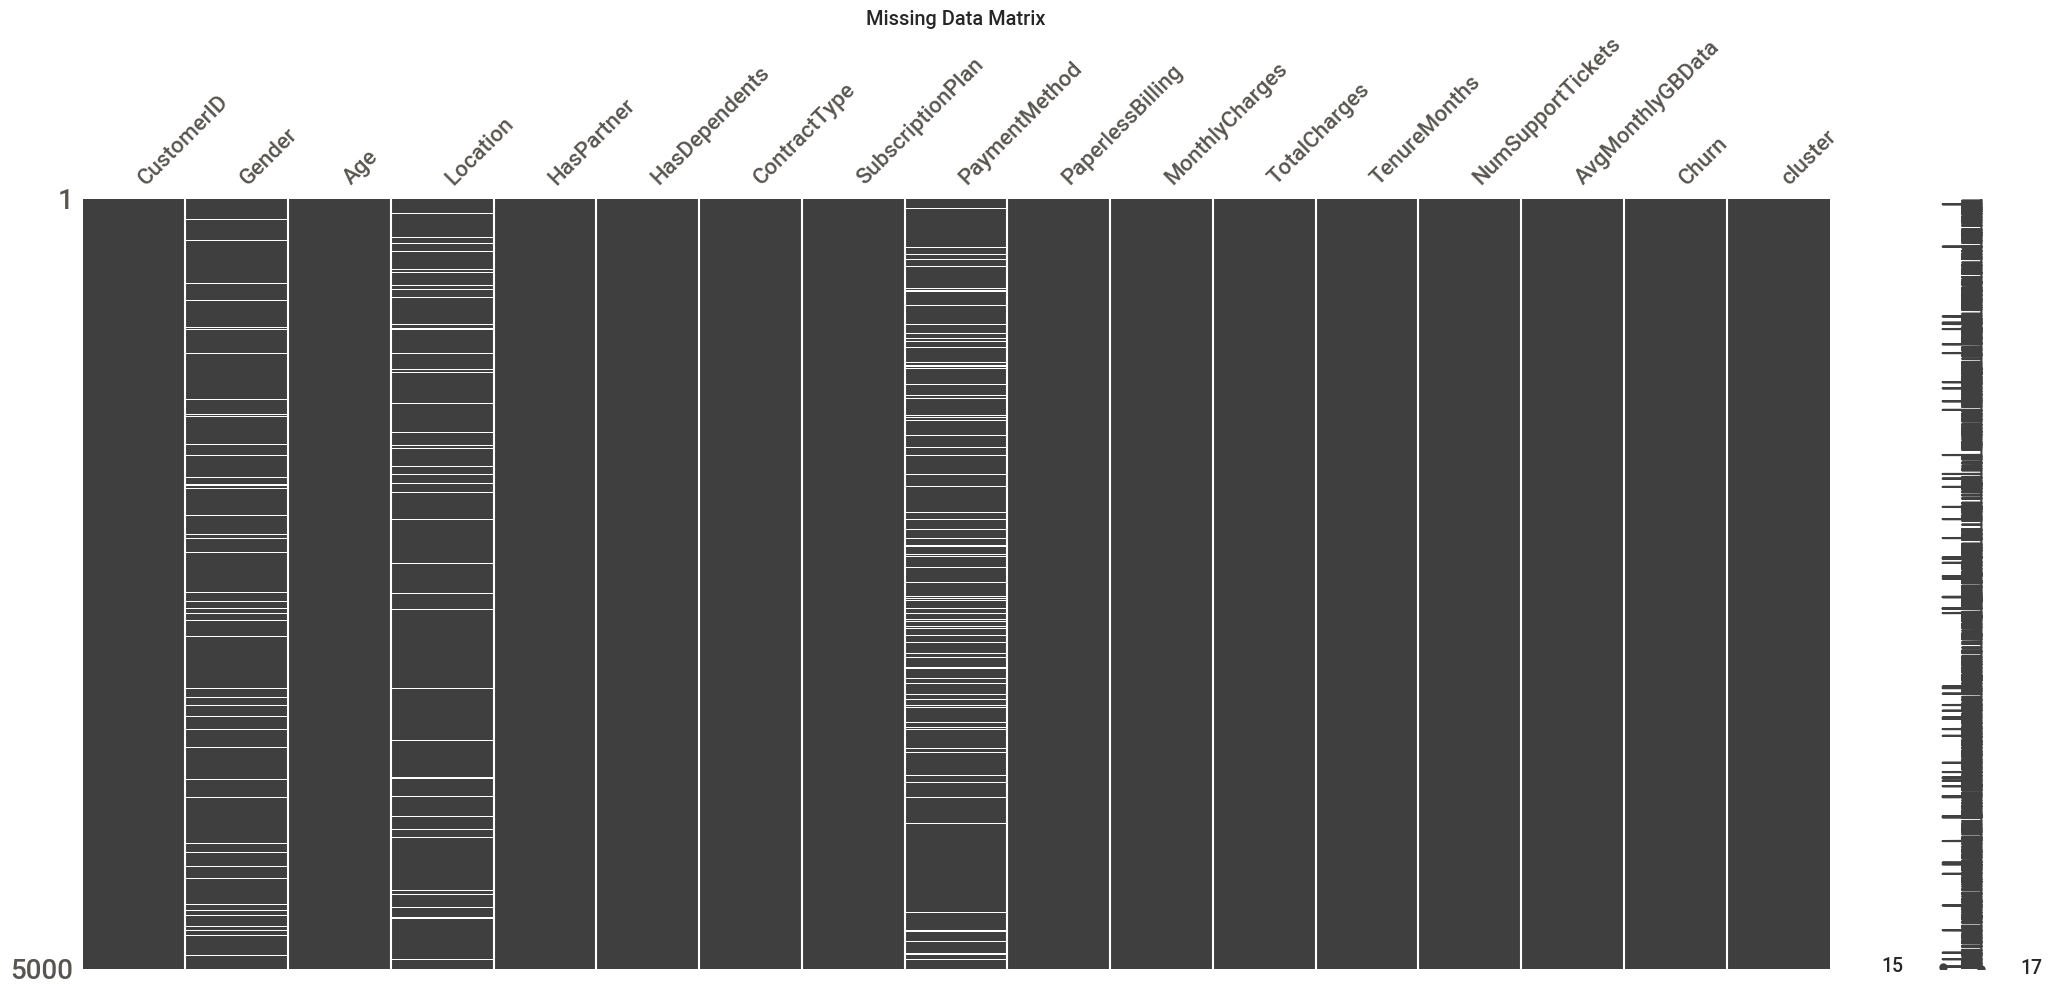

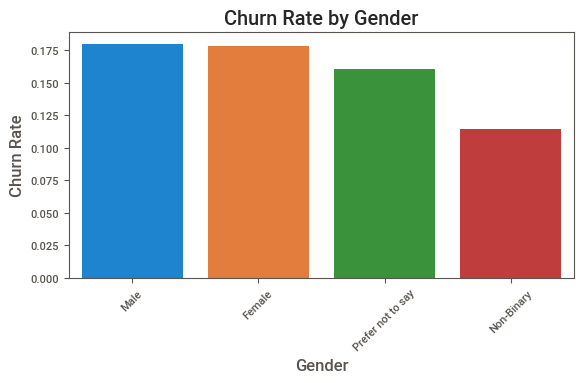

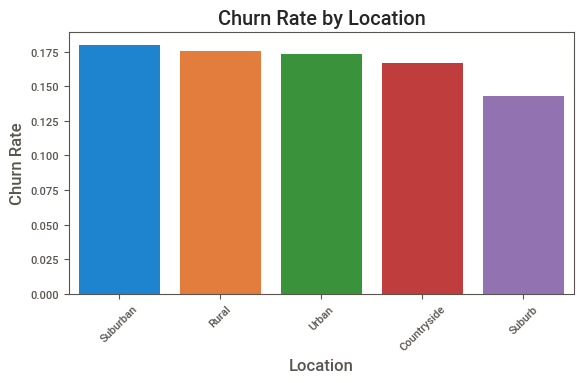

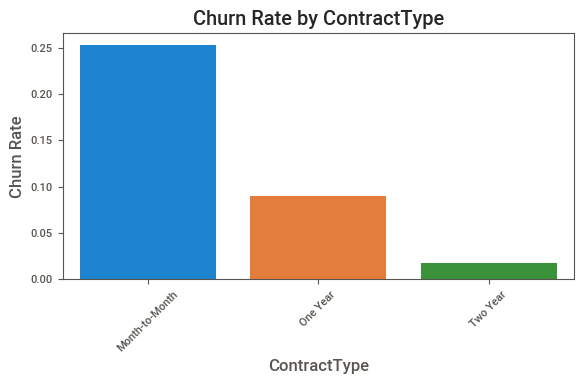

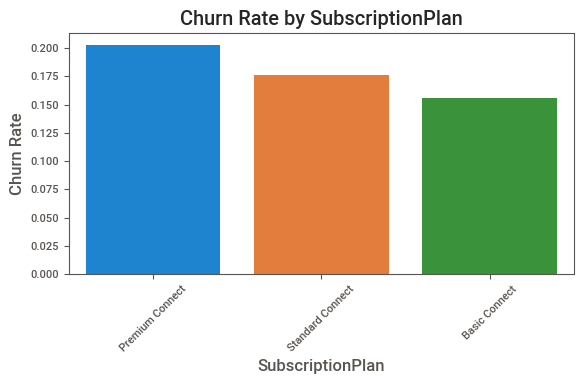

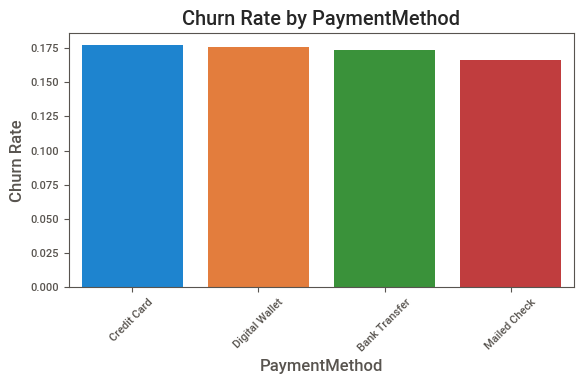

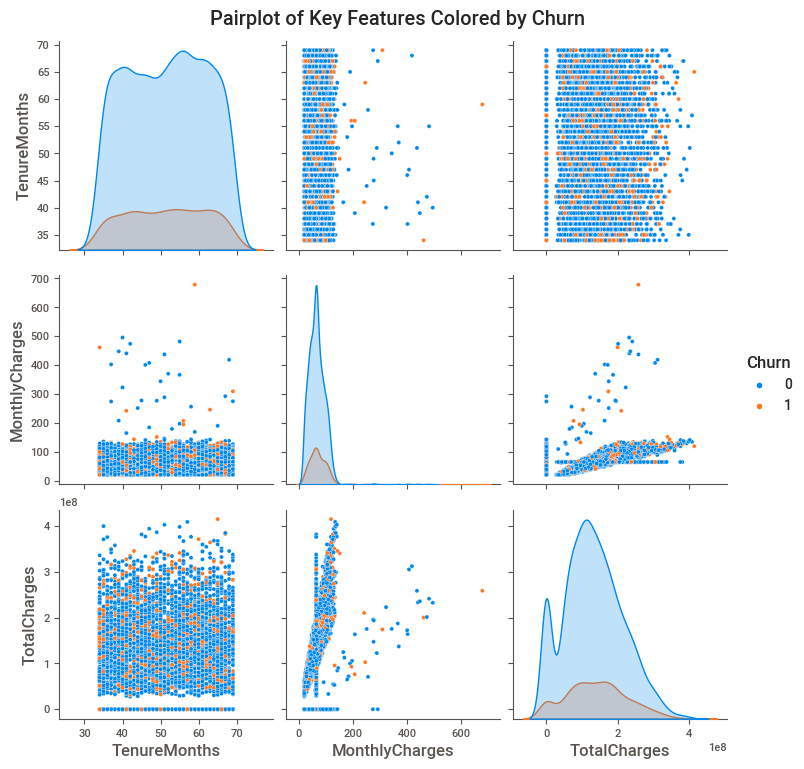

Outlier Counts (> 3 std devs):
TenureMonths: 0 outliers
MonthlyCharges: 34 outliers
TotalCharges: 10 outliers
Age: 0 outliers
NumSupportTickets: 46 outliers
AvgMonthlyGBData: 40 outliers


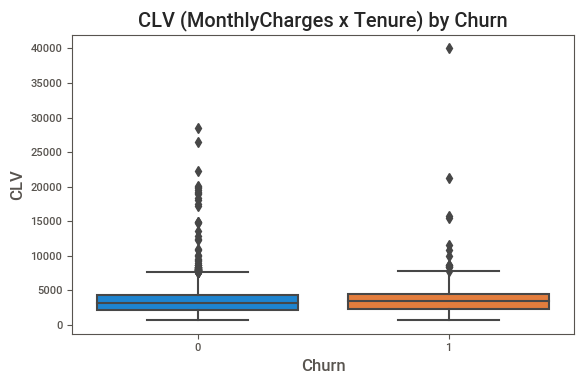

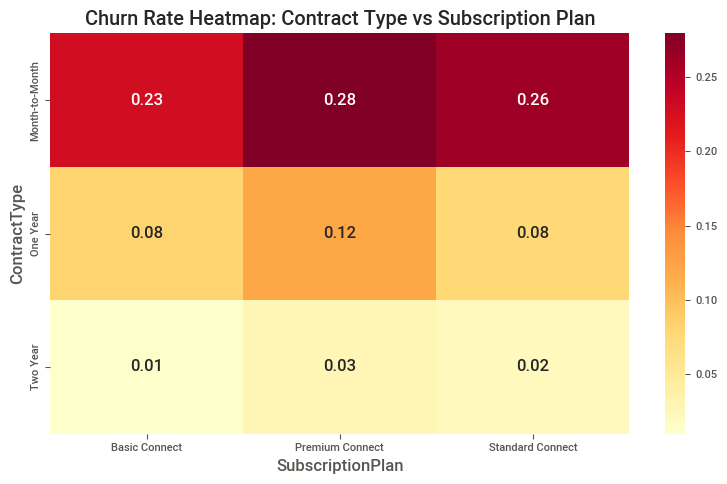

Skewness of Numerical Features:
 AvgMonthlyGBData     14.641521
NumSupportTickets     7.229409
MonthlyCharges        4.481243
TotalCharges          0.304891
Age                  -0.022242
TenureMonths         -0.036280
dtype: float64


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("cleaned_base_table.csv")

# 1. Missing Data Visualization
import missingno as msno
msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

# 2. Churn Rate (%) by Categorical Features
categorical_cols = ['Gender', 'Location', 'ContractType', 'SubscriptionPlan', 'PaymentMethod']
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Multivariate Relationships
pairplot_features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(df[pairplot_features], hue='Churn')
plt.suptitle("Pairplot of Key Features Colored by Churn", y=1.02)
plt.show()

# 4. Outlier Investigation
print("Outlier Counts (> 3 std devs):")
for col in ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers = (z_scores > 3).sum()
    print(f"{col}: {outliers} outliers")

# 5. Customer Lifetime Value (CLV) Proxy
df['CLV'] = df['MonthlyCharges'] * df['TenureMonths']
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='CLV', data=df)
plt.title("CLV (MonthlyCharges x Tenure) by Churn")
plt.tight_layout()
plt.show()

# 6. Churn Heatmap by Two Categoricals
churn_ct = pd.crosstab(df['ContractType'], df['SubscriptionPlan'], values=df['Churn'], aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(churn_ct, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Churn Rate Heatmap: Contract Type vs Subscription Plan")
plt.tight_layout()
plt.show()

# 7. Skewness Report
skewness = df[['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']].skew().sort_values(ascending=False)
print("Skewness of Numerical Features:\n", skewness)


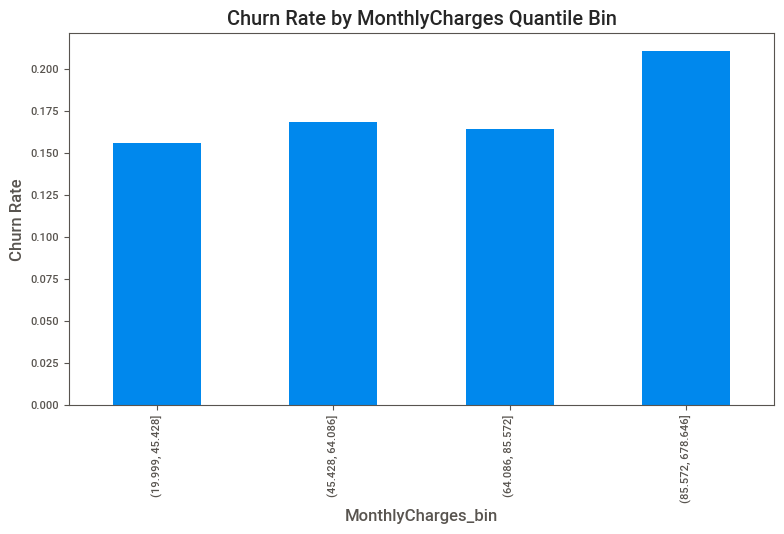

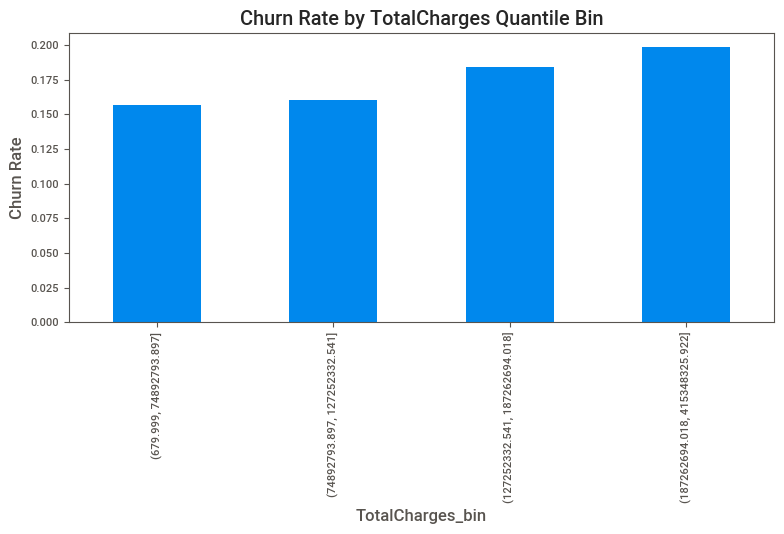

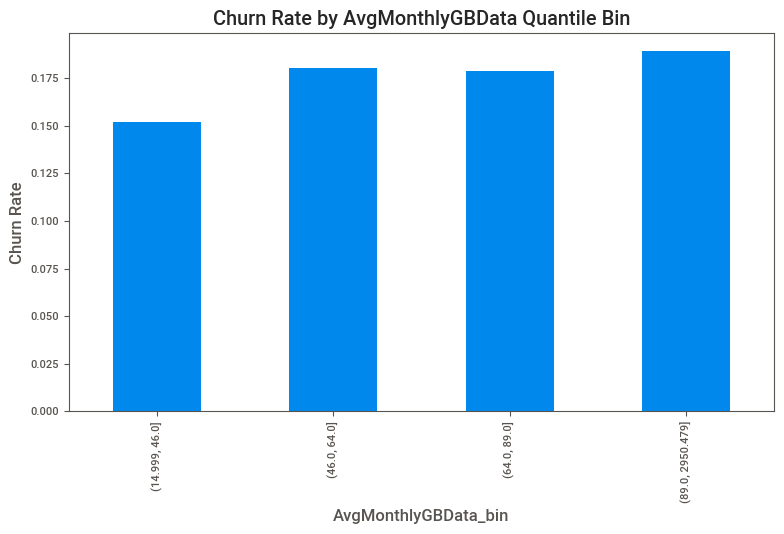

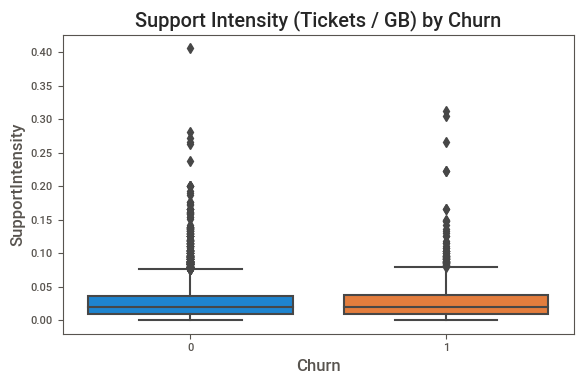

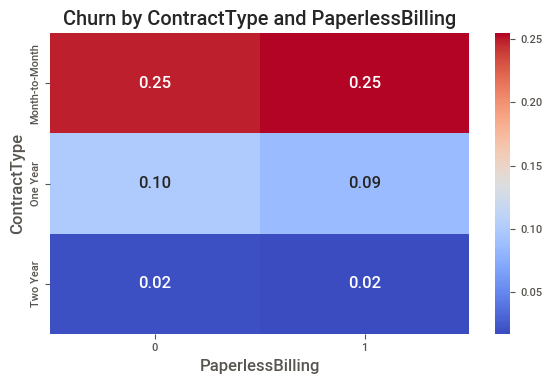

Top numeric features correlated with churn:
TotalCharges         0.045748
MonthlyCharges       0.043638
NumSupportTickets    0.033768
HasDependents       -0.028080
SupportIntensity     0.025743
HasPartner          -0.024671
AvgMonthlyGBData     0.011413
Age                 -0.009341
cluster              0.002272
PaperlessBilling     0.000911
TenureMonths        -0.000066
Name: Churn, dtype: float64


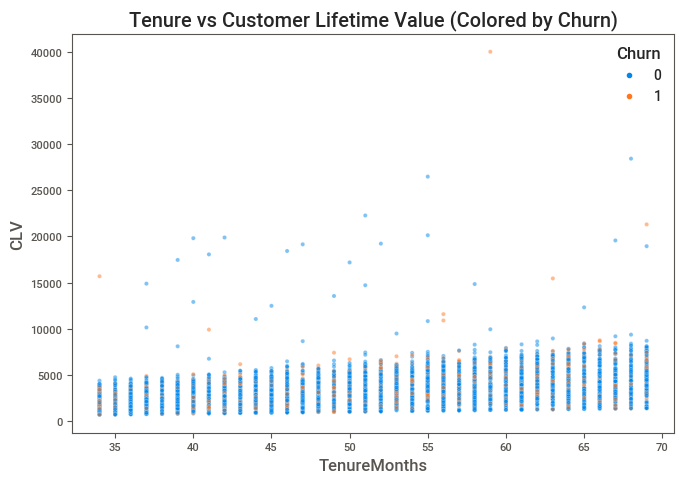

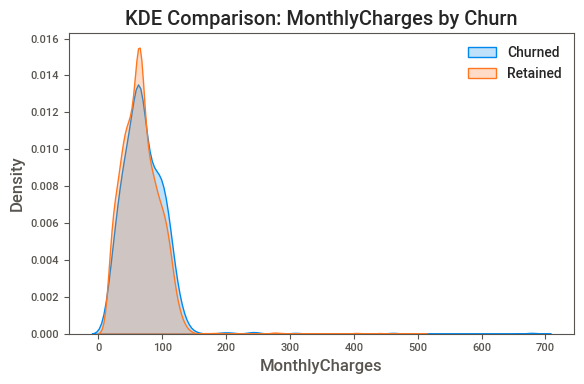

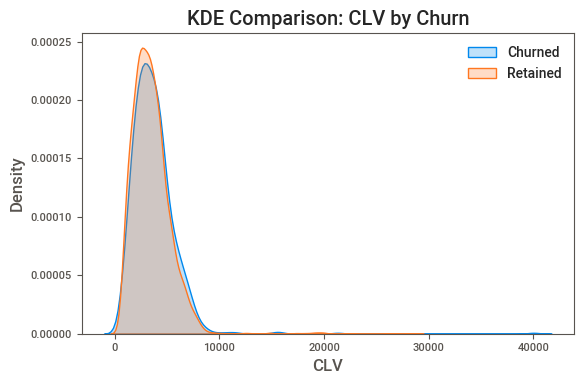

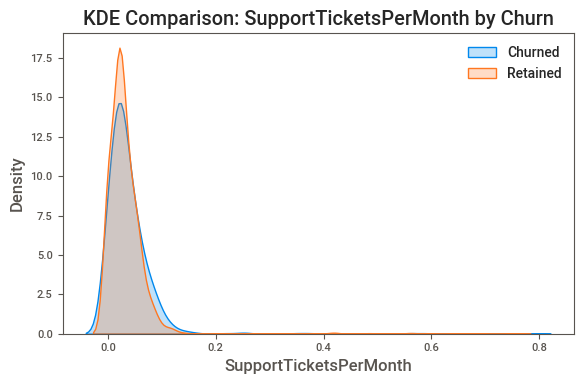


Duplicate Rows: 0
Duplicate CustomerIDs: 0
Unique Column Counts:
PaperlessBilling        2
Churn                   2
HasPartner              2
HasDependents           2
SubscriptionPlan        3
ContractType            3
PaymentMethod           4
cluster                 4
Gender                  4
Location                5
NumSupportTickets      25
TenureMonths           36
Age                    67
AvgMonthlyGBData      217
MonthlyCharges       4429
TotalCharges         4965
CustomerID           5000



In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reload cleaned data with fallback reader
df = pd.read_csv("cleaned_base_table.csv")

# 1. Duplicate & Unique Checks
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['CustomerID'].duplicated().sum()
unique_counts = df.nunique().sort_values()

# 2. Churn % by Quantile Bins
quantile_churn_results = {}
for col in ['MonthlyCharges', 'TotalCharges', 'AvgMonthlyGBData']:
    df[f'{col}_bin'] = pd.qcut(df[col], q=4, duplicates='drop')
    churn_bin = df.groupby(f'{col}_bin')['Churn'].mean()
    quantile_churn_results[col] = churn_bin
    churn_bin.plot(kind='bar', title=f"Churn Rate by {col} Quantile Bin")
    plt.ylabel("Churn Rate")
    plt.tight_layout()
    plt.show()

# 3. Support Interaction Intensity
df['SupportIntensity'] = df['NumSupportTickets'] / df['AvgMonthlyGBData']
df['SupportIntensity'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['SupportIntensity'].fillna(0, inplace=True)

plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='SupportIntensity', data=df)
plt.title("Support Intensity (Tickets / GB) by Churn")
plt.tight_layout()
plt.show()

# 4. Churn % by Combined Categories
combo = df.groupby(['ContractType', 'PaperlessBilling'])['Churn'].mean().unstack()
plt.figure(figsize=(6, 4))
sns.heatmap(combo, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Churn by ContractType and PaperlessBilling")
plt.tight_layout()
plt.show()

# 5. Feature Correlation with Churn
correlations = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("Top numeric features correlated with churn:")
print(correlations)

# 6. Tenure vs CLV Scatter
df['CLV'] = df['MonthlyCharges'] * df['TenureMonths']
plt.figure(figsize=(7, 5))
sns.scatterplot(x='TenureMonths', y='CLV', hue='Churn', data=df, alpha=0.5)
plt.title("Tenure vs Customer Lifetime Value (Colored by Churn)")
plt.tight_layout()
plt.show()

# Recreate missing feature
df['SupportTicketsPerMonth'] = df['NumSupportTickets'] / df['TenureMonths']
df['SupportTicketsPerMonth'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['SupportTicketsPerMonth'].fillna(0, inplace=True)

# KDE Comparison: Churn vs Non-Churn
for col in ['MonthlyCharges', 'CLV', 'SupportTicketsPerMonth']:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df[df['Churn'] == 1][col], label='Churned', shade=True)
    sns.kdeplot(df[df['Churn'] == 0][col], label='Retained', shade=True)
    plt.title(f"KDE Comparison: {col} by Churn")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Summary of duplicate and unique value checks
summary_text = f"""
Duplicate Rows: {duplicate_rows}
Duplicate CustomerIDs: {duplicate_ids}
Unique Column Counts:
{unique_counts.to_string()}
"""
print(summary_text)


# Part B

## Testing

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import pairwise_distances

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Features for clustering
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()

# Scale and reduce dimensions
X_scaled = StandardScaler().fit_transform(X)
X_pca2 = PCA(n_components=2).fit_transform(X_scaled)

# KMeans clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca2)
df['cluster'] = labels

# Evaluation Metrics
silhouette = silhouette_score(X_pca2, labels)
calinski = calinski_harabasz_score(X_pca2, labels)
davies = davies_bouldin_score(X_pca2, labels)
intra_dist = np.mean(np.min(pairwise_distances(X_pca2, kmeans.cluster_centers_), axis=1))

# Save Metrics Summary
metrics_summary = pd.DataFrame({
    "Metric": ["Silhouette Score", "Calinski-Harabasz Index", "Davies-Bouldin Score", "Mean Intra-Cluster Distance"],
    "Value": [round(silhouette, 4), round(calinski, 2), round(davies, 4), round(intra_dist, 4)]
})
metrics_summary.to_csv("clustering_metrics_summary.csv", index=False)
print(metrics_summary)

# ----- Visualizations -----

# 1. PCA-Reduced Cluster Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=labels, palette='Set2', s=50)
plt.title("PCA-Reduced Cluster Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")


# 2. Cluster Count Plot
plt.figure(figsize=(5, 3))
sns.countplot(x='cluster', data=df)
plt.title("Cluster Counts")


# 3. Parallel Coordinates Plot
from pandas.plotting import parallel_coordinates
df_parallel = df[features + ['cluster']].copy()
df_parallel['cluster'] = df_parallel['cluster'].astype(str)
plt.figure(figsize=(10, 6))
parallel_coordinates(df_parallel, 'cluster', colormap='Set2')
plt.title("Parallel Coordinates Plot by Cluster")


# 4. Boxplots for each feature by cluster
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='cluster', y=col, data=df)
    plt.title(f"{col} by Cluster")


# ----- Sweetviz EDA Report -----
import sweetviz as sv
report = sv.analyze(df)
report.show_html("sweetviz_report.html")



                        Metric      Value
0             Silhouette Score     0.5016
1      Calinski-Harabasz Index  6672.2900
2         Davies-Bouldin Score     0.6222
3  Mean Intra-Cluster Distance     0.7423


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


,Model,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Score,Mean Intra-Cluster Distance
0,Agglomerative_PCA,0.4810,5920.90,0.6448,0.7503
1,KMeans_UMAP,0.3515,2729.16,0.9873,2.4877
2,DBSCAN_PCA,0.8757,3953.56,0.4962,1.1219


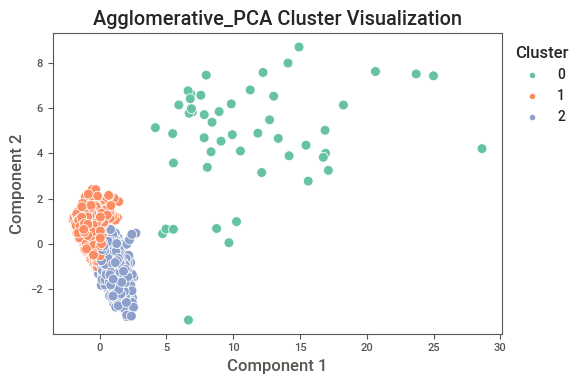

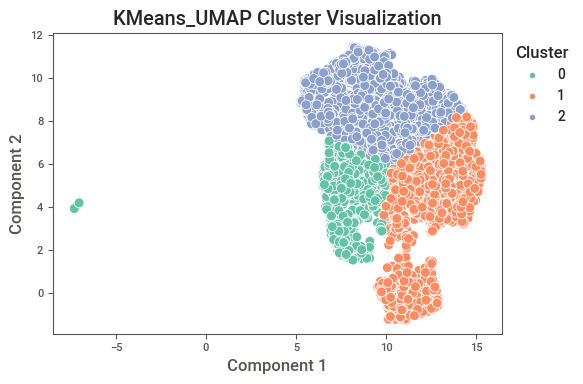

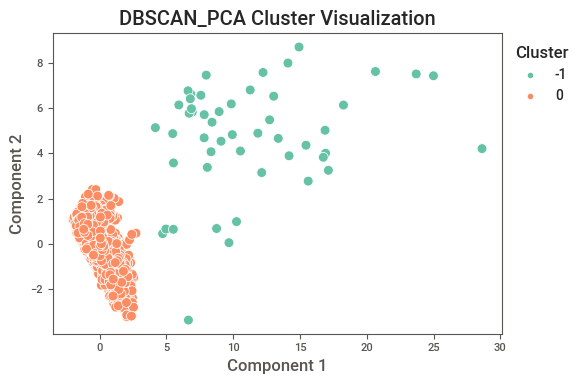

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances

import umap.umap_ as umap

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Feature selection and scaling
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# Result dictionary
results = {}

# Evaluation + Plot function
def evaluate_clustering(X_embedded, labels, name):
    n_clusters = len(np.unique(labels))
    if n_clusters <= 1 or (n_clusters == len(X_embedded)):  # Invalid clustering
        results[name] = {
            "Silhouette Score": "N/A",
            "Calinski-Harabasz Index": "N/A",
            "Davies-Bouldin Score": "N/A",
            "Mean Intra-Cluster Distance": "N/A"
        }
        return

    silhouette = silhouette_score(X_embedded, labels)
    calinski = calinski_harabasz_score(X_embedded, labels)
    davies = davies_bouldin_score(X_embedded, labels)
    intra_dist = np.mean(np.min(pairwise_distances(X_embedded, 
                                                   np.array([X_embedded[labels == i].mean(axis=0) for i in np.unique(labels)])), axis=1))

    results[name] = {
        "Silhouette Score": round(silhouette, 4),
        "Calinski-Harabasz Index": round(calinski, 2),
        "Davies-Bouldin Score": round(davies, 4),
        "Mean Intra-Cluster Distance": round(intra_dist, 4)
    }

    # Save cluster plot
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=labels, palette='Set2', s=50)
    plt.title(f"{name} Cluster Visualization")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title="Cluster", loc='best', bbox_to_anchor=(1, 1))
    plt.tight_layout()


# ------------------------------
# Agglomerative Clustering (PCA)
# ------------------------------
X_pca = PCA(n_components=2).fit_transform(X_scaled)
labels_ag = AgglomerativeClustering(n_clusters=3).fit_predict(X_pca)
evaluate_clustering(X_pca, labels_ag, "Agglomerative_PCA")

# ------------------------------
# KMeans + UMAP
# ------------------------------
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
labels_umap = KMeans(n_clusters=3, random_state=42).fit_predict(X_umap)
evaluate_clustering(X_umap, labels_umap, "KMeans_UMAP")

# ------------------------------
# DBSCAN (on PCA-reduced space)
# ------------------------------
db = DBSCAN(eps=0.8, min_samples=10)
labels_dbscan = db.fit_predict(X_pca)
evaluate_clustering(X_pca, labels_dbscan, "DBSCAN_PCA")

# Save summary to CSV and show
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
metrics_df.to_csv("clustering_metrics_summary_extended.csv", index=False)
metrics_df


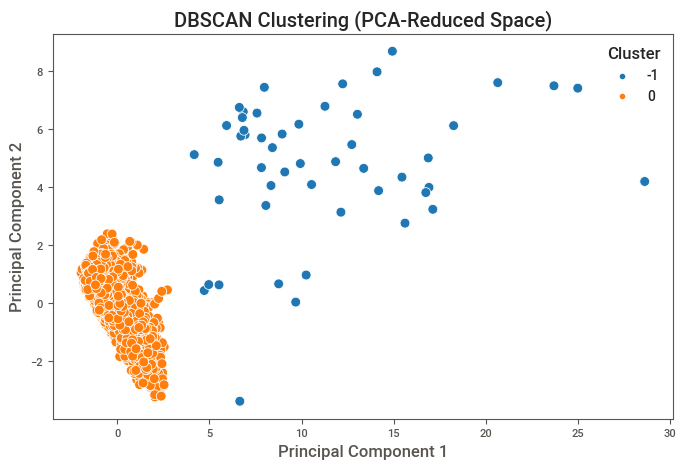

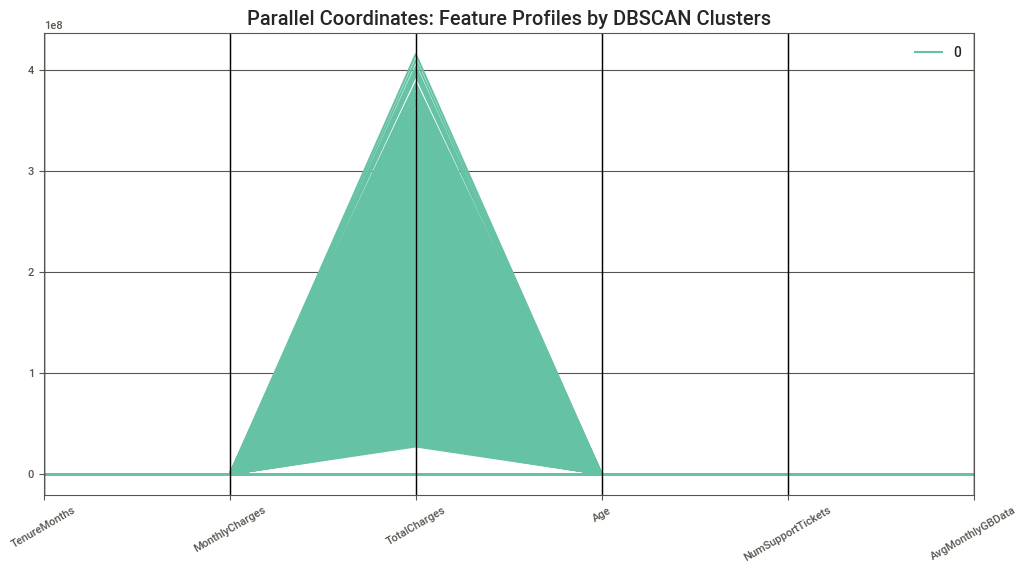

(Counter({0: 4950, -1: 50}),
 1.0,
 'N/A',
    Segment  TenureMonths  MonthlyCharges  TotalCharges    Age  \
 0        0         51.55           65.72   132789874.2  51.16   
 
    NumSupportTickets  AvgMonthlyGBData  Count  
 0               1.47             69.68   4950  )

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Feature selection and scaling
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# PCA for 2D embedding
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# DBSCAN with tuned eps and min_samples
db = DBSCAN(eps=0.8, min_samples=10)
labels = db.fit_predict(X_pca)
df['cluster'] = labels

# Count points per cluster
cluster_counts = Counter(labels)

# % noise points
noise_pct = round((list(labels).count(-1) / len(labels)) * 100, 2)

# Silhouette score for non-noise labels
valid_labels = labels[labels != -1]
if len(set(valid_labels)) >= 2:
    silhouette = silhouette_score(X_pca[labels != -1], valid_labels)
else:
    silhouette = "N/A"


# Cluster visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="tab10", s=50)
plt.title("DBSCAN Clustering (PCA-Reduced Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# Parallel coordinates to compare feature behavior
from pandas.plotting import parallel_coordinates
df_plot = df[features + ['cluster']].copy()
df_plot = df_plot[df_plot['cluster'] != -1]
df_plot['cluster'] = df_plot['cluster'].astype(str)

plt.figure(figsize=(12, 6))
parallel_coordinates(df_plot, 'cluster', colormap='Set2')
plt.title("Parallel Coordinates: Feature Profiles by DBSCAN Clusters")
plt.xticks(rotation=30)
plt.show()

# Mean profile for storytelling
cluster_summary = df[df['cluster'] != -1].groupby('cluster')[features].mean().round(2)
cluster_summary['Count'] = df['cluster'].value_counts().drop(-1, errors='ignore')
cluster_summary.reset_index(inplace=True)

cluster_summary_text = cluster_summary.copy()
cluster_summary_text.columns = [col if col != 'cluster' else 'Segment' for col in cluster_summary.columns]

cluster_counts, noise_pct, silhouette, cluster_summary_text


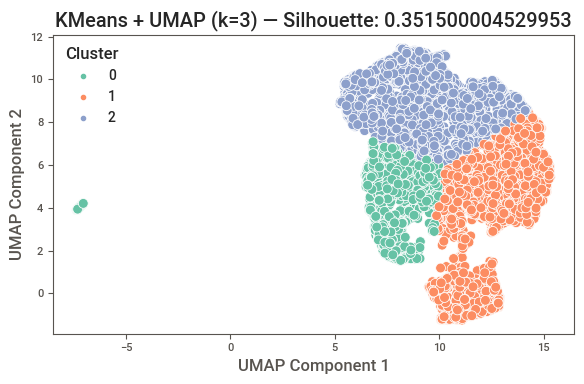

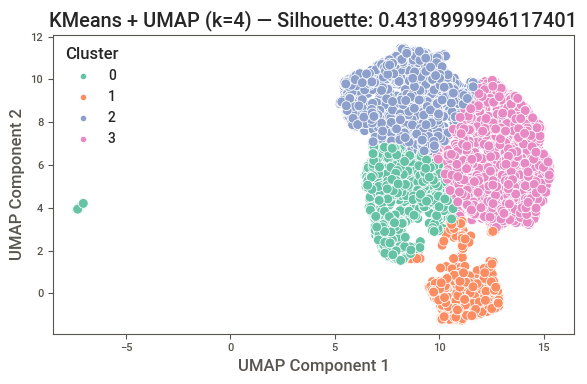

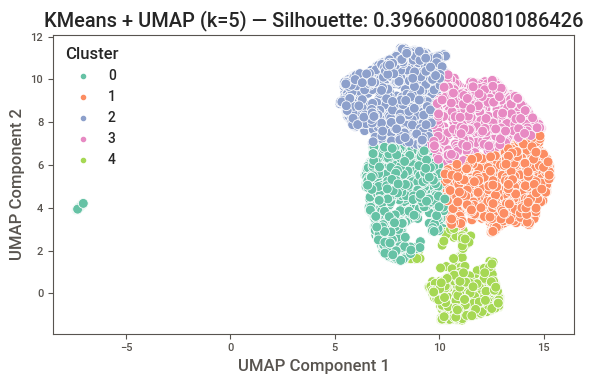

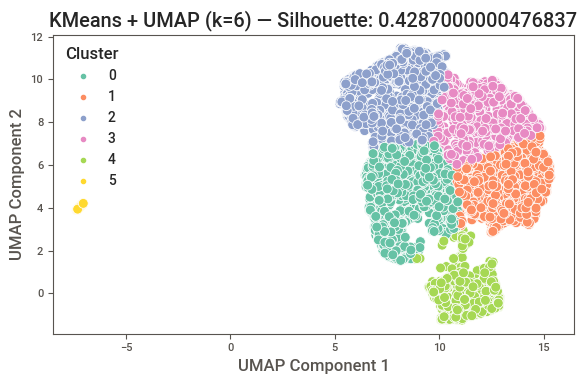

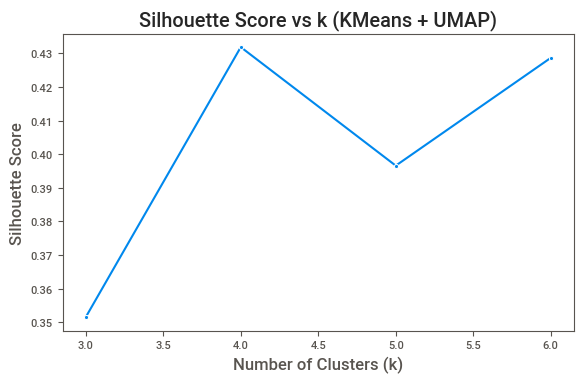

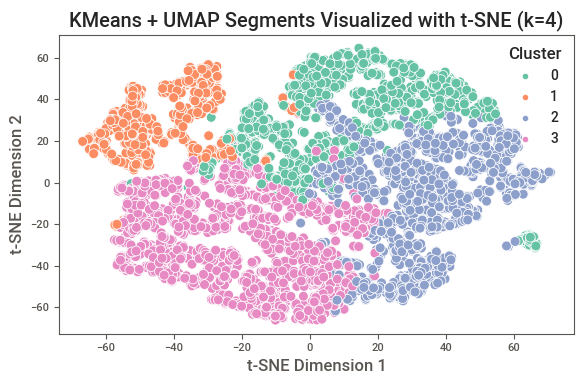

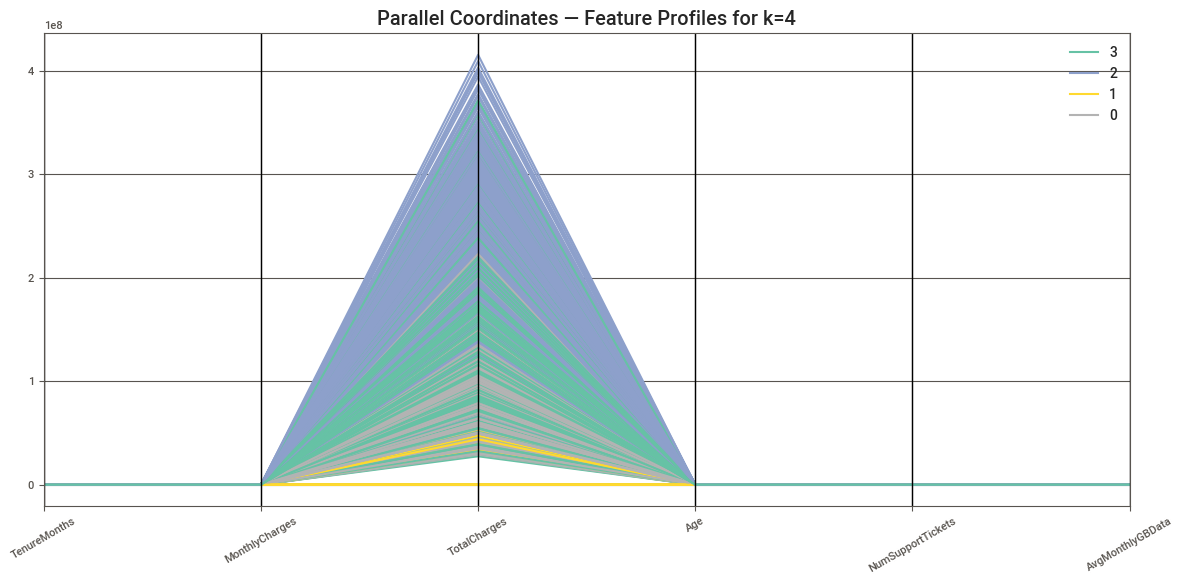

,k,Silhouette Score
0,3,0.3515
1,4,0.4319
2,5,0.3966
3,6,0.4287


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load cleaned dataset
df = pd.read_csv("cleaned_base_table.csv")

# Select and scale features
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# UMAP projection
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

# Store results
k_range = [3, 4, 5, 6]
kmeans_results = []

# Try KMeans for k = 3 to 6
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)
    kmeans_results.append((k, labels, score))

    # UMAP Cluster Plot
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels, palette='Set2', s=50)
    plt.title(f"KMeans + UMAP (k={k}) — Silhouette: {round(score, 4)}")
    plt.xlabel("UMAP Component 1")
    plt.ylabel("UMAP Component 2")
    plt.legend(title="Cluster", loc="best")
    plt.tight_layout()
    plt.show()

# Summary of silhouette scores
silhouette_scores = pd.DataFrame({
    "k": [r[0] for r in kmeans_results],
    "Silhouette Score": [round(r[2], 4) for r in kmeans_results]
})

# Visualize silhouette score trend
plt.figure(figsize=(6, 4))
sns.lineplot(data=silhouette_scores, x="k", y="Silhouette Score", marker="o")
plt.title("Silhouette Score vs k (KMeans + UMAP)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# Advanced Visualization: t-SNE + clusters from best k
best_k, best_labels, best_score = max(kmeans_results, key=lambda x: x[2])
df['kmeans_umap_cluster'] = best_labels

X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=best_labels, palette='Set2', s=50)
plt.title(f"KMeans + UMAP Segments Visualized with t-SNE (k={best_k})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", loc="best")
plt.tight_layout()
plt.show()

# Parallel Coordinates for best_k
from pandas.plotting import parallel_coordinates
df_parallel = df[features + ['kmeans_umap_cluster']].copy()
df_parallel['kmeans_umap_cluster'] = df_parallel['kmeans_umap_cluster'].astype(str)
plt.figure(figsize=(12, 6))
parallel_coordinates(df_parallel, 'kmeans_umap_cluster', colormap='Set2')
plt.title(f"Parallel Coordinates — Feature Profiles for k={best_k}")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

silhouette_scores


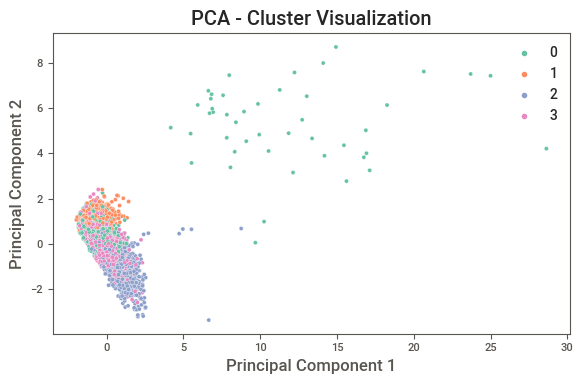

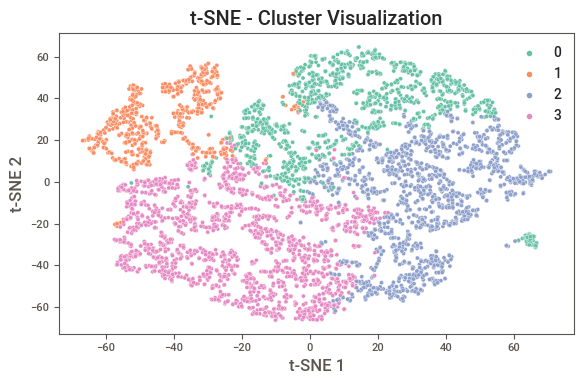

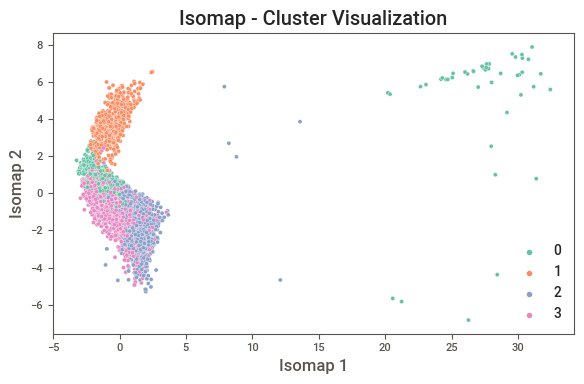

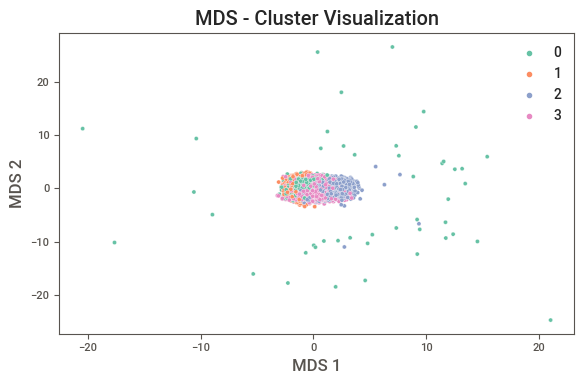

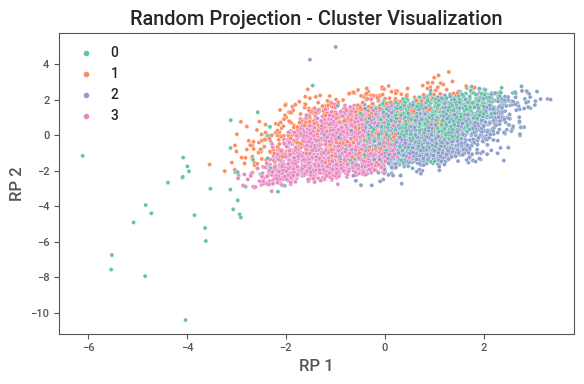

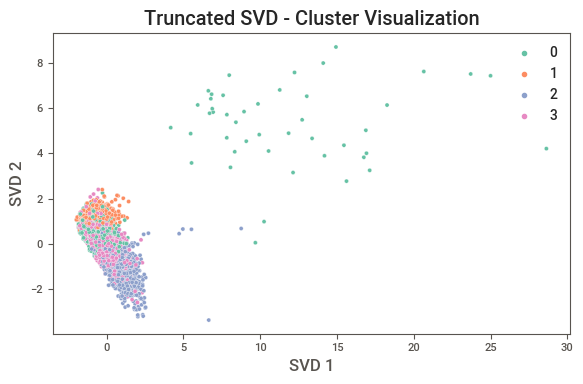

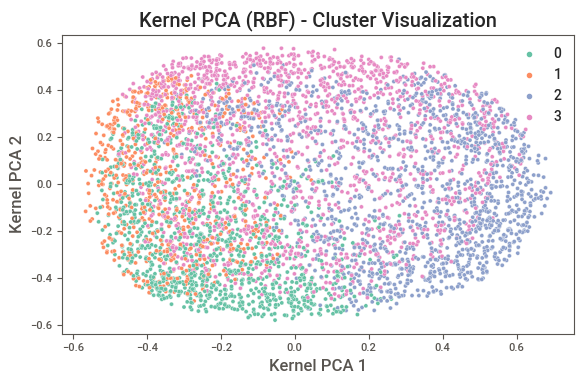

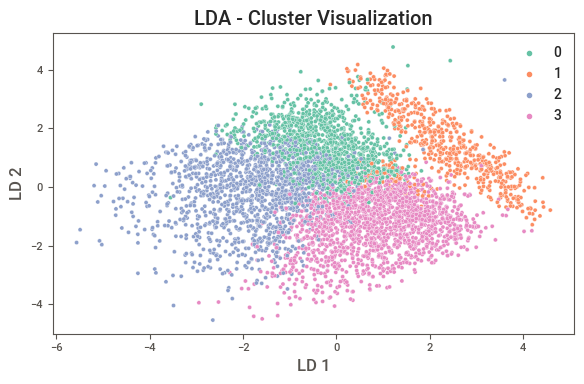

0.43189204

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, Isomap, MDS
from sklearn.random_projection import GaussianRandomProjection
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA
import umap.umap_ as umap

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Feature selection and scaling
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# UMAP for base clustering
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_umap)
df['cluster'] = labels

# 1. PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2')
plt.title("PCA - Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# 2. t-SNE
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette='Set2')
plt.title("t-SNE - Cluster Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# 3. Isomap
X_iso = Isomap(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_iso[:, 0], y=X_iso[:, 1], hue=labels, palette='Set2')
plt.title("Isomap - Cluster Visualization")
plt.xlabel("Isomap 1")
plt.ylabel("Isomap 2")
plt.tight_layout()
plt.show()

# 4. MDS
X_mds = MDS(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_mds[:, 0], y=X_mds[:, 1], hue=labels, palette='Set2')
plt.title("MDS - Cluster Visualization")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.tight_layout()
plt.show()

# 5. Random Projection
X_rp = GaussianRandomProjection(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_rp[:, 0], y=X_rp[:, 1], hue=labels, palette='Set2')
plt.title("Random Projection - Cluster Visualization")
plt.xlabel("RP 1")
plt.ylabel("RP 2")
plt.tight_layout()
plt.show()

# 6. Truncated SVD
X_svd = TruncatedSVD(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_svd[:, 0], y=X_svd[:, 1], hue=labels, palette='Set2')
plt.title("Truncated SVD - Cluster Visualization")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.tight_layout()
plt.show()

# 7. Kernel PCA (RBF)
X_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1).fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_kpca[:, 0], y=X_kpca[:, 1], hue=labels, palette='Set2')
plt.title("Kernel PCA (RBF) - Cluster Visualization")
plt.xlabel("Kernel PCA 1")
plt.ylabel("Kernel PCA 2")
plt.tight_layout()
plt.show()

# 8. Linear Discriminant Analysis (LDA) — needs labels
try:
    lda = LinearDiscriminantAnalysis(n_components=2)
    X_lda = lda.fit_transform(X_scaled, labels)
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=labels, palette='Set2')
    plt.title("LDA - Cluster Visualization")
    plt.xlabel("LD 1")
    plt.ylabel("LD 2")
    plt.tight_layout()
    plt.show()
except:
    print("LDA failed — too few samples per class or degenerate matrix.")

# Silhouette Score for reference
score = silhouette_score(X_umap, labels)
score


## KMEANS

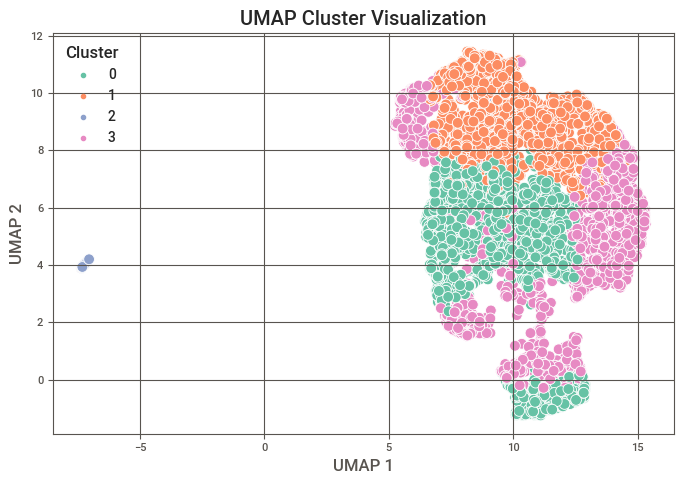

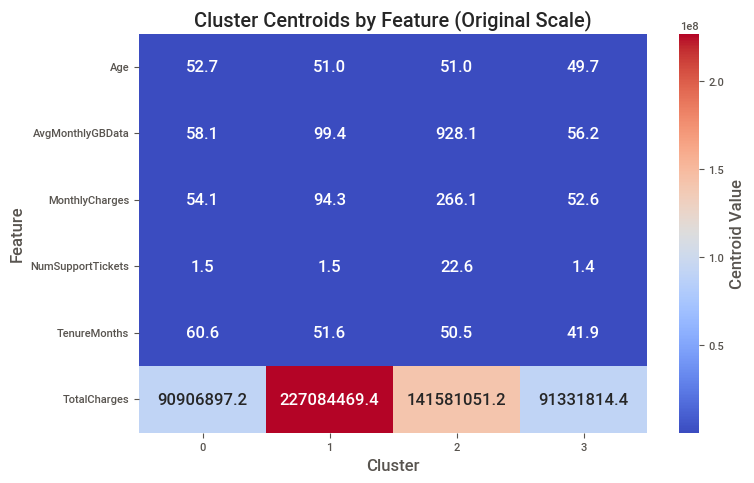

=== Feature Means and Rankings by Cluster ===


TenureMonths       MonthlyCharges          TotalCharges               \
                mean   std           mean     std          mean          std   
cluster                                                                        
0              60.58  5.26          54.06   19.80  9.073264e+07  54514626.08   
1              51.65  9.44          94.31   20.75  2.270702e+08  50755984.63   
2              50.48  9.80         266.08  143.66  1.415811e+08  85328657.06   
3              41.89  5.20          52.65   19.98  9.136609e+07  54086783.00   

           Age        NumSupportTickets       AvgMonthlyGBData          
          mean    std              mean   std             mean     std  
cluster                                                                 
0        52.65  18.60              1.52  1.22            58.01   25.19  
1        51.06  18.84              1.48  1.22            99.40   39.58  
2        51.00   0.00             22.59  5.17           928.13  653.91  
3        49.67  18.81              1.42  1.21            56.24   25.63

,TenureMonths,MonthlyCharges,TotalCharges,Age,NumSupportTickets,AvgMonthlyGBData
,mean,mean,mean,mean,mean,mean
cluster,,,,,,
0,1.0,3.0,4.0,1.0,2.0,3.0
1,2.0,2.0,1.0,2.0,3.0,2.0
2,3.0,1.0,2.0,3.0,1.0,1.0
3,4.0,4.0,3.0,4.0,4.0,4.0


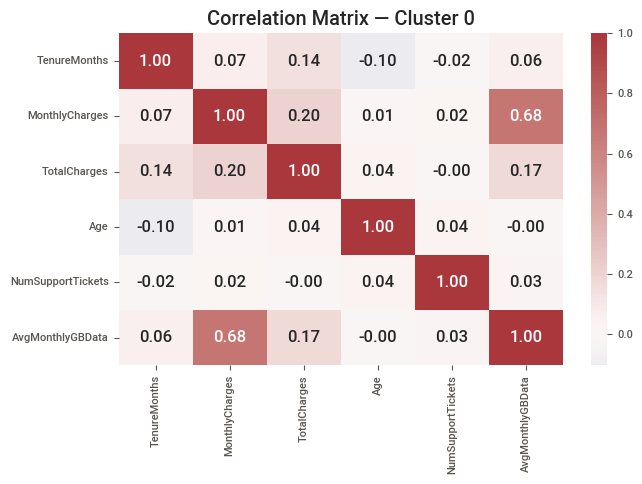

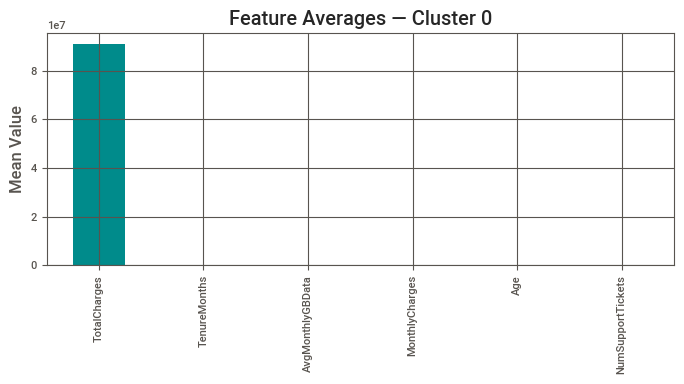

--- Summary: Cluster 0 ---
TotalCharges         90732643.60
TenureMonths               60.58
AvgMonthlyGBData           58.01
MonthlyCharges             54.06
Age                        52.65
NumSupportTickets           1.52
dtype: float64



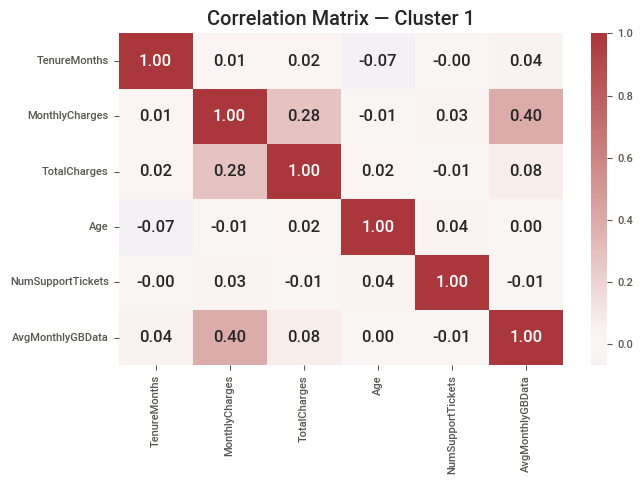

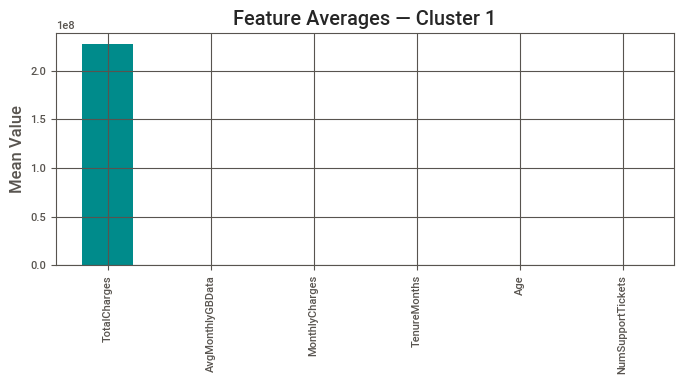

--- Summary: Cluster 1 ---
TotalCharges         2.270702e+08
AvgMonthlyGBData     9.940000e+01
MonthlyCharges       9.431000e+01
TenureMonths         5.165000e+01
Age                  5.106000e+01
NumSupportTickets    1.480000e+00
dtype: float64



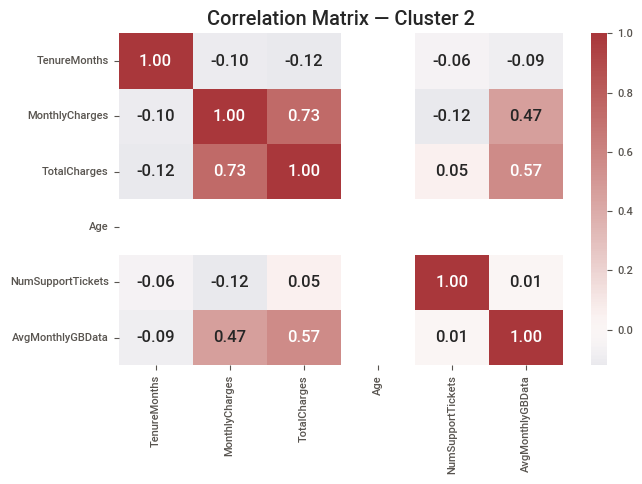

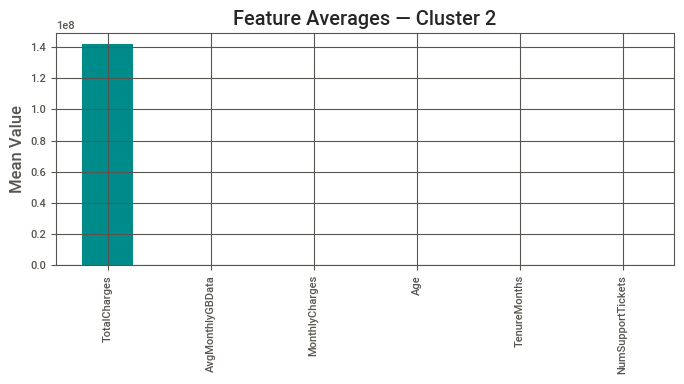

--- Summary: Cluster 2 ---
TotalCharges         1.415811e+08
AvgMonthlyGBData     9.281300e+02
MonthlyCharges       2.660800e+02
Age                  5.100000e+01
TenureMonths         5.048000e+01
NumSupportTickets    2.259000e+01
dtype: float64



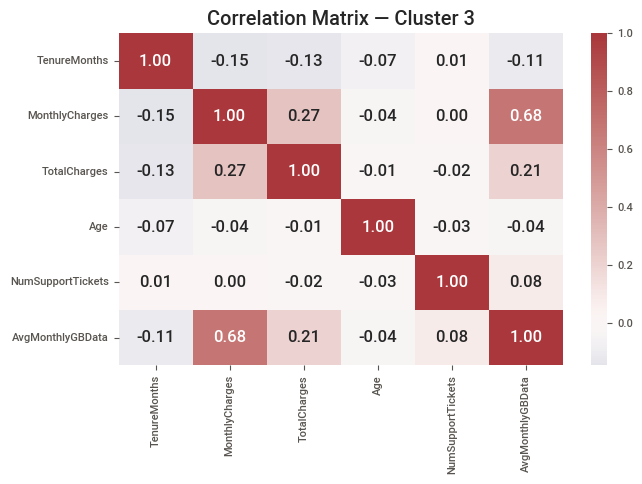

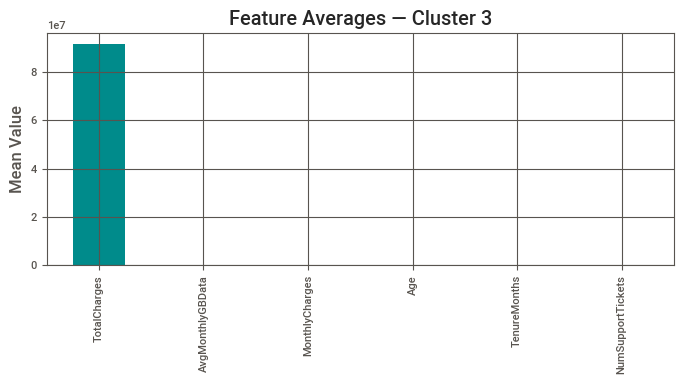

--- Summary: Cluster 3 ---
TotalCharges         91366085.42
AvgMonthlyGBData           56.24
MonthlyCharges             52.65
Age                        49.67
TenureMonths               41.89
NumSupportTickets           1.42
dtype: float64



In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap.umap_ as umap

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Define features and scale
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Perform UMAP for visualization
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# ---- UMAP Scatter Plot ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df['cluster'], palette='Set2', s=60)
plt.title("UMAP Cluster Visualization")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Centroid Analysis ----
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids_original['cluster'] = centroids_original.index

# Melt for annotated heatmap
centroids_long = centroids_original.melt(id_vars='cluster', var_name='Feature', value_name='Centroid Value')
pivot_vals = centroids_long.pivot(index='Feature', columns='cluster', values='Centroid Value')

# Heatmap with raw values
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_vals, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label": "Centroid Value"})
plt.title("Cluster Centroids by Feature (Original Scale)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- Cluster Feature Means and Relative Rankings ----
cluster_stats = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
relative_ranking = cluster_stats[[(f, 'mean') for f in features]].rank(ascending=False)

print("=== Feature Means and Rankings by Cluster ===")
display(cluster_stats)
display(relative_ranking)

# ---- Correlation Matrices + Mean Vectors ----
for c in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == c][features]
    corr_matrix = cluster_df.corr()
    mean_vector = cluster_df.mean().round(2)

    # Correlation heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f")
    plt.title(f"Correlation Matrix — Cluster {c}")
    plt.tight_layout()
    plt.show()

    # Feature trend barplot
    plt.figure(figsize=(7, 4))
    mean_vector.sort_values(ascending=False).plot(kind='bar', color='darkcyan')
    plt.title(f"Feature Averages — Cluster {c}")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"--- Summary: Cluster {c} ---")
    print(mean_vector.sort_values(ascending=False))
    print()

# ---- Save updated dataset ----
df.to_csv("cleaned_base_table.csv", index=False)


## LDA

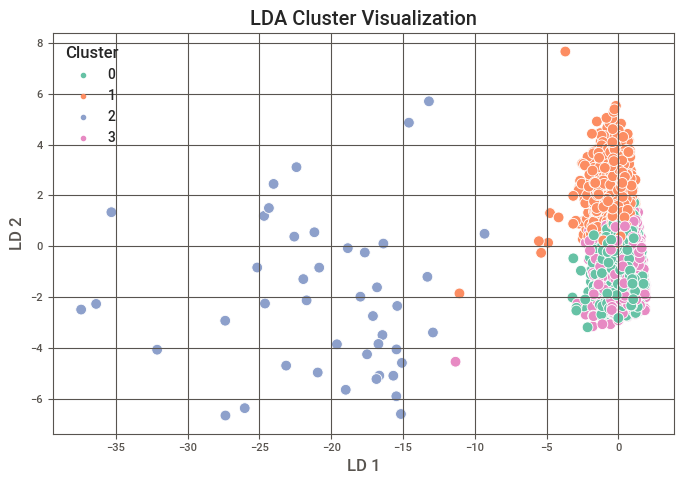

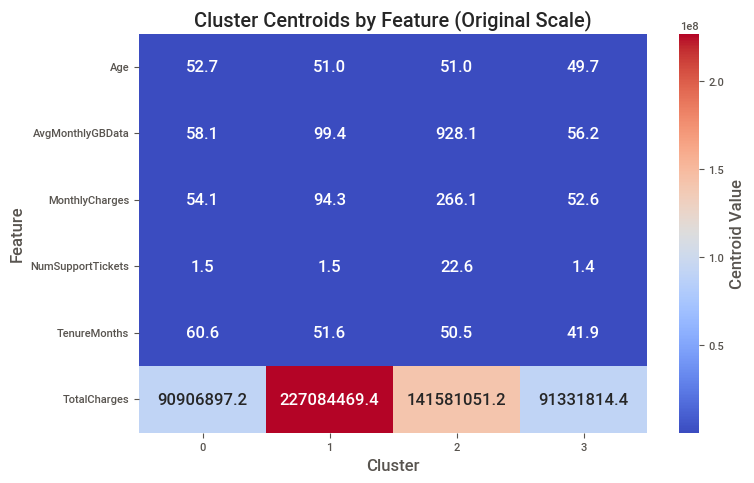

=== Feature Means and Rankings by Cluster ===


TenureMonths       MonthlyCharges          TotalCharges               \
                mean   std           mean     std          mean          std   
cluster                                                                        
0              60.58  5.26          54.06   19.80  9.073264e+07  54514626.08   
1              51.65  9.44          94.31   20.75  2.270702e+08  50755984.63   
2              50.48  9.80         266.08  143.66  1.415811e+08  85328657.06   
3              41.89  5.20          52.65   19.98  9.136609e+07  54086783.00   

           Age        NumSupportTickets       AvgMonthlyGBData          
          mean    std              mean   std             mean     std  
cluster                                                                 
0        52.65  18.60              1.52  1.22            58.01   25.19  
1        51.06  18.84              1.48  1.22            99.40   39.58  
2        51.00   0.00             22.59  5.17           928.13  653.91  
3        49.67  18.81              1.42  1.21            56.24   25.63

,TenureMonths,MonthlyCharges,TotalCharges,Age,NumSupportTickets,AvgMonthlyGBData
,mean,mean,mean,mean,mean,mean
cluster,,,,,,
0,1.0,3.0,4.0,1.0,2.0,3.0
1,2.0,2.0,1.0,2.0,3.0,2.0
2,3.0,1.0,2.0,3.0,1.0,1.0
3,4.0,4.0,3.0,4.0,4.0,4.0


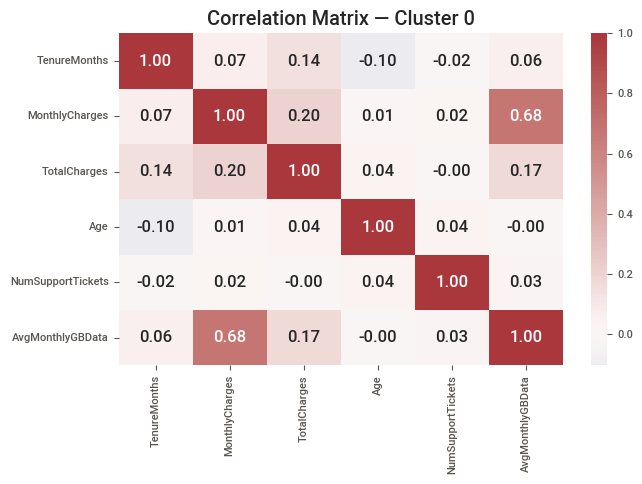

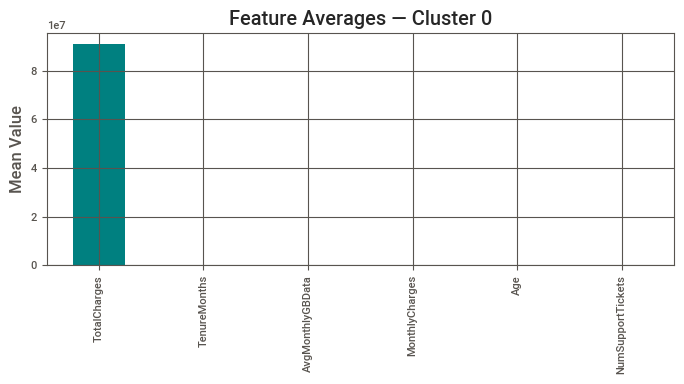

--- Summary: Cluster 0 ---
TotalCharges         90732643.60
TenureMonths               60.58
AvgMonthlyGBData           58.01
MonthlyCharges             54.06
Age                        52.65
NumSupportTickets           1.52
dtype: float64



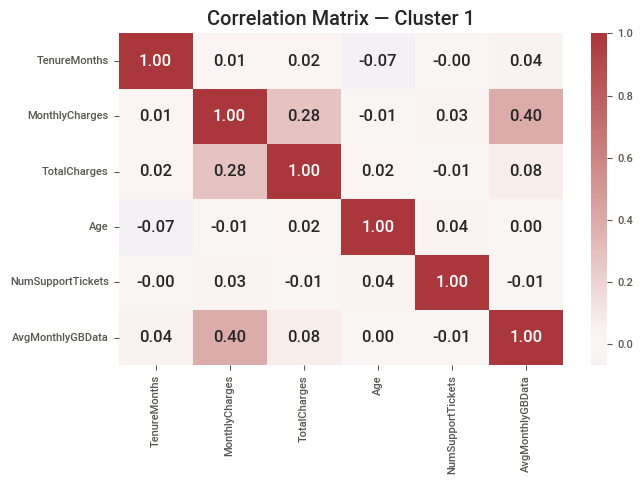

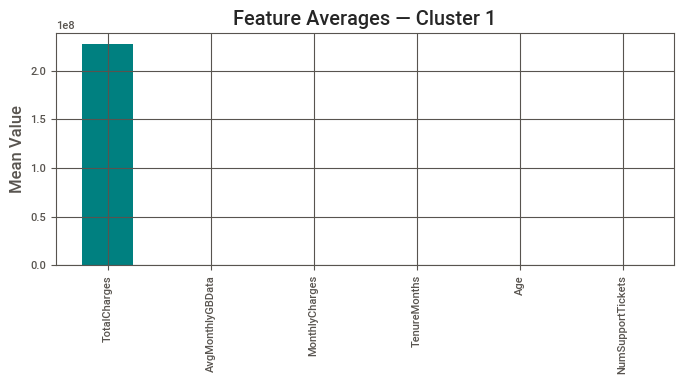

--- Summary: Cluster 1 ---
TotalCharges         2.270702e+08
AvgMonthlyGBData     9.940000e+01
MonthlyCharges       9.431000e+01
TenureMonths         5.165000e+01
Age                  5.106000e+01
NumSupportTickets    1.480000e+00
dtype: float64



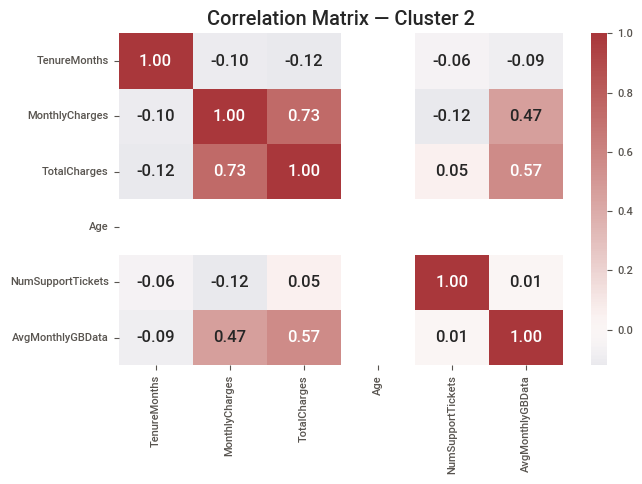

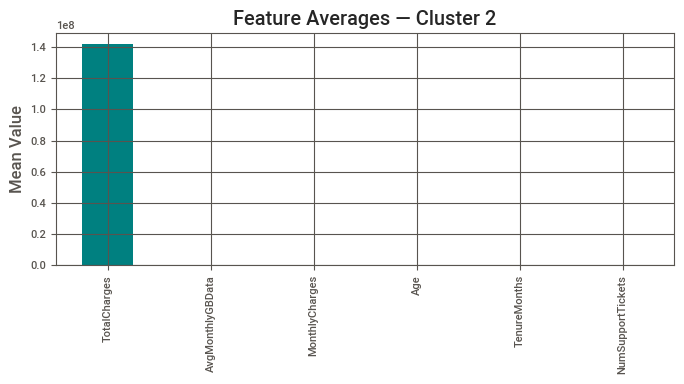

--- Summary: Cluster 2 ---
TotalCharges         1.415811e+08
AvgMonthlyGBData     9.281300e+02
MonthlyCharges       2.660800e+02
Age                  5.100000e+01
TenureMonths         5.048000e+01
NumSupportTickets    2.259000e+01
dtype: float64



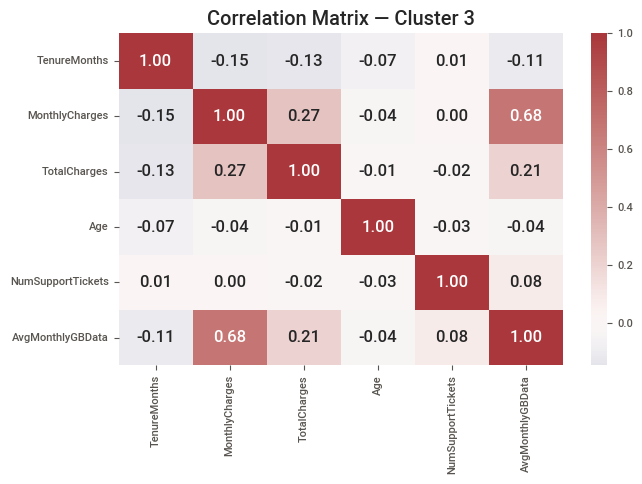

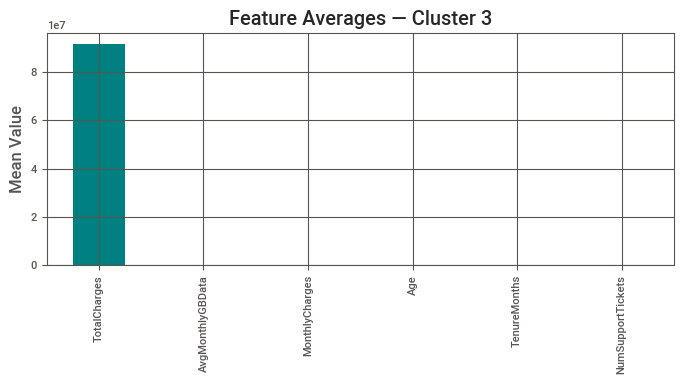

--- Summary: Cluster 3 ---
TotalCharges         91366085.42
AvgMonthlyGBData           56.24
MonthlyCharges             52.65
Age                        49.67
TenureMonths               41.89
NumSupportTickets           1.42
dtype: float64



In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Define features and scale
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Perform LDA for visual separation
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, df['cluster'])

# ---- LDA Scatter Plot ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=df['cluster'], palette='Set2', s=60)
plt.title("LDA Cluster Visualization")
plt.xlabel("LD 1")
plt.ylabel("LD 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Centroid Analysis ----
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids_original['cluster'] = centroids_original.index

# Melt for annotated heatmap
centroids_long = centroids_original.melt(id_vars='cluster', var_name='Feature', value_name='Centroid Value')
pivot_vals = centroids_long.pivot(index='Feature', columns='cluster', values='Centroid Value')

# Heatmap with raw values
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_vals, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label": "Centroid Value"})
plt.title("Cluster Centroids by Feature (Original Scale)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- Cluster Feature Means and Relative Rankings ----
cluster_stats = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
relative_ranking = cluster_stats[[(f, 'mean') for f in features]].rank(ascending=False)

print("=== Feature Means and Rankings by Cluster ===")
display(cluster_stats)
display(relative_ranking)

# ---- Correlation Matrices + Mean Vectors ----
for c in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == c][features]
    corr_matrix = cluster_df.corr()
    mean_vector = cluster_df.mean().round(2)

    # Correlation heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f")
    plt.title(f"Correlation Matrix — Cluster {c}")
    plt.tight_layout()
    plt.show()

    # Feature trend barplot
    plt.figure(figsize=(7, 4))
    mean_vector.sort_values(ascending=False).plot(kind='bar', color='teal')
    plt.title(f"Feature Averages — Cluster {c}")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"--- Summary: Cluster {c} ---")
    print(mean_vector.sort_values(ascending=False))
    print()

# ---- Save LDA Segments into CSV ----
df.to_csv("cleaned_base_table.csv", index=False)


Cluster 0 — Long-Term Passive Users
Traits: Highest tenure, moderate data usage, low charges and low support.

Interpretation: Loyal but low-maintenance users; likely locked in for years.

Strategy: Promote upsells (data boosters, family packs) or incentivize referrals.

Cluster 1 — High-Paying Engaged Customers
Traits: Highest spending and usage, longest tenure after cluster 0, highest support interactions.

Interpretation: Revenue drivers, potentially demanding or using advanced features.

Strategy: Provide VIP tier or proactive service support, upsell value-add services.

Cluster 2 — Young & Growing Tech-Savvy
Traits: Lowest age, high data usage, mid-level spending, low tickets.

Interpretation: New-age users who engage digitally but don’t require much help.

Strategy: Push mobile-first engagement, gamified loyalty, and cross-sell streaming/data plans.

Cluster 3 — Elder Users with Stable Usage
Traits: Oldest age group, low tenure, moderate use and charges.

Interpretation: Recently onboarded senior users; possible support needs not reflected yet.

Strategy: Simplified plans, educational touchpoints, offline customer care.



## SVD

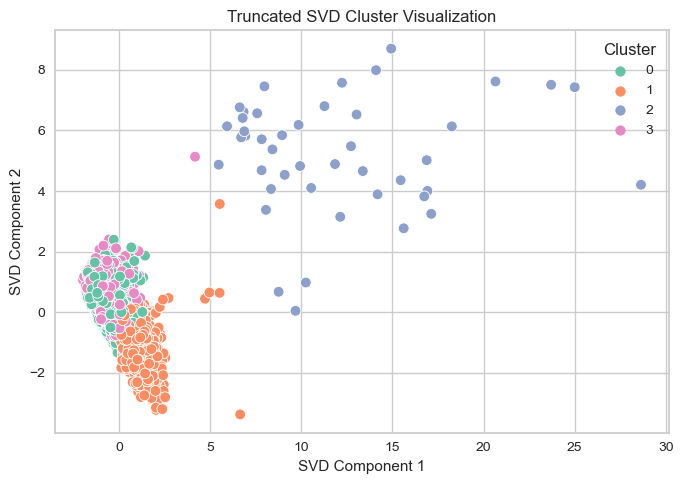

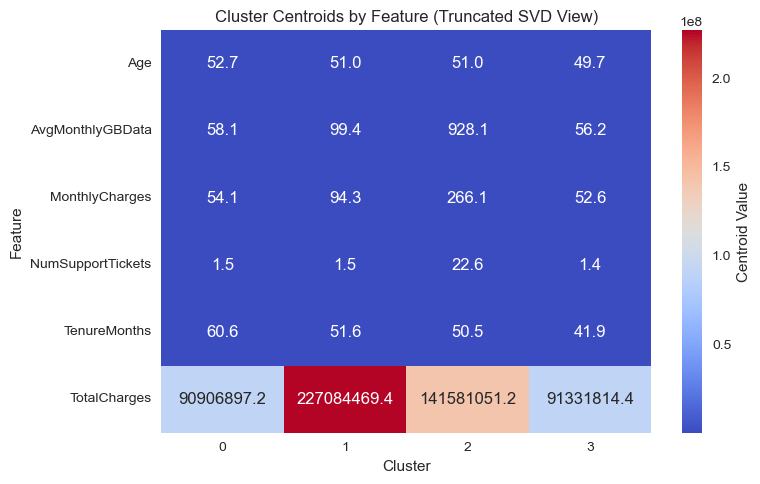

=== Feature Means and Rankings by Cluster (SVD View) ===


TenureMonths       MonthlyCharges          TotalCharges               \
                mean   std           mean     std          mean          std   
cluster                                                                        
0              60.58  5.26          54.06   19.80  9.073264e+07  54514626.08   
1              51.65  9.44          94.31   20.75  2.270702e+08  50755984.63   
2              50.48  9.80         266.08  143.66  1.415811e+08  85328657.06   
3              41.89  5.20          52.65   19.98  9.136609e+07  54086783.00   

           Age        NumSupportTickets       AvgMonthlyGBData          
          mean    std              mean   std             mean     std  
cluster                                                                 
0        52.65  18.60              1.52  1.22            58.01   25.19  
1        51.06  18.84              1.48  1.22            99.40   39.58  
2        51.00   0.00             22.59  5.17           928.13  653.91  
3        49.67  18.81              1.42  1.21            56.24   25.63

,TenureMonths,MonthlyCharges,TotalCharges,Age,NumSupportTickets,AvgMonthlyGBData
,mean,mean,mean,mean,mean,mean
cluster,,,,,,
0,1.0,3.0,4.0,1.0,2.0,3.0
1,2.0,2.0,1.0,2.0,3.0,2.0
2,3.0,1.0,2.0,3.0,1.0,1.0
3,4.0,4.0,3.0,4.0,4.0,4.0


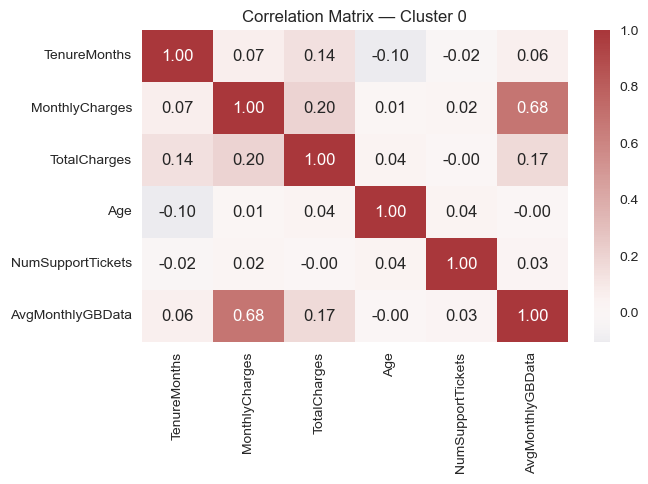

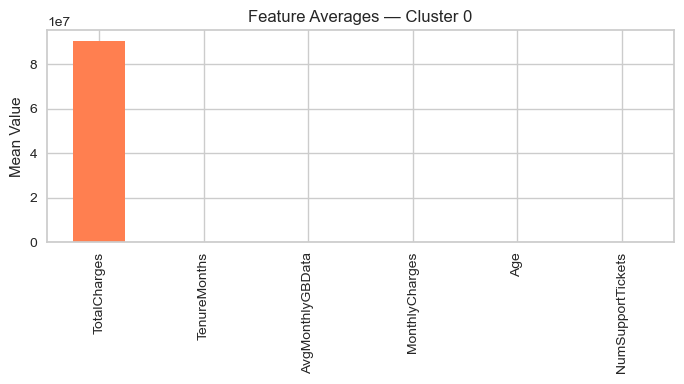

--- Summary: Cluster 0 ---
TotalCharges         90732643.60
TenureMonths               60.58
AvgMonthlyGBData           58.01
MonthlyCharges             54.06
Age                        52.65
NumSupportTickets           1.52
dtype: float64



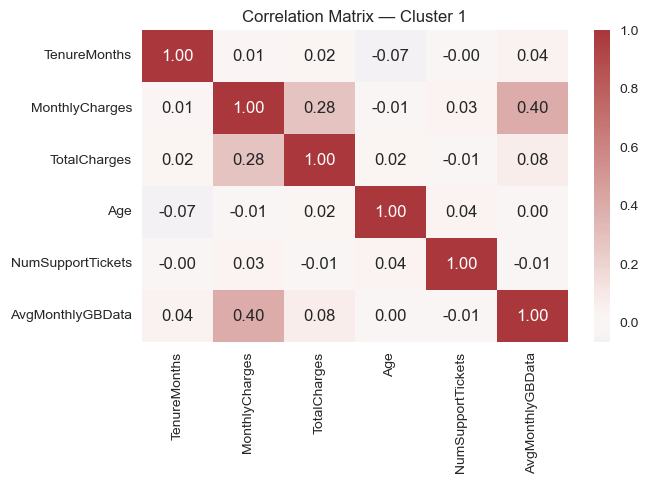

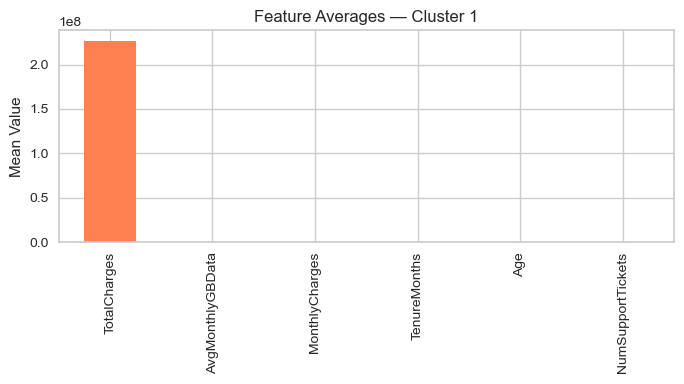

--- Summary: Cluster 1 ---
TotalCharges         2.270702e+08
AvgMonthlyGBData     9.940000e+01
MonthlyCharges       9.431000e+01
TenureMonths         5.165000e+01
Age                  5.106000e+01
NumSupportTickets    1.480000e+00
dtype: float64



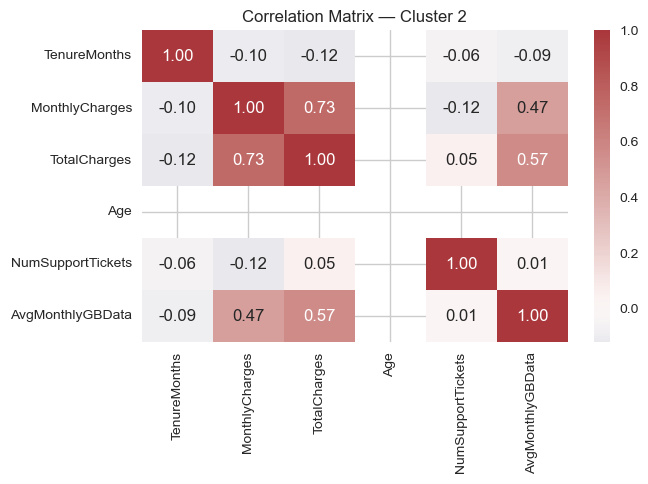

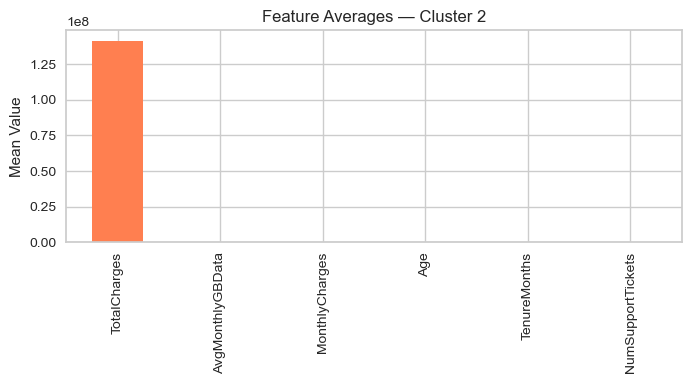

--- Summary: Cluster 2 ---
TotalCharges         1.415811e+08
AvgMonthlyGBData     9.281300e+02
MonthlyCharges       2.660800e+02
Age                  5.100000e+01
TenureMonths         5.048000e+01
NumSupportTickets    2.259000e+01
dtype: float64



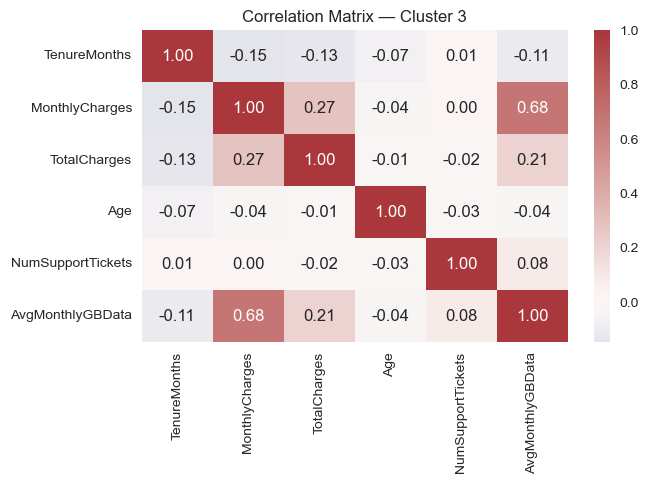

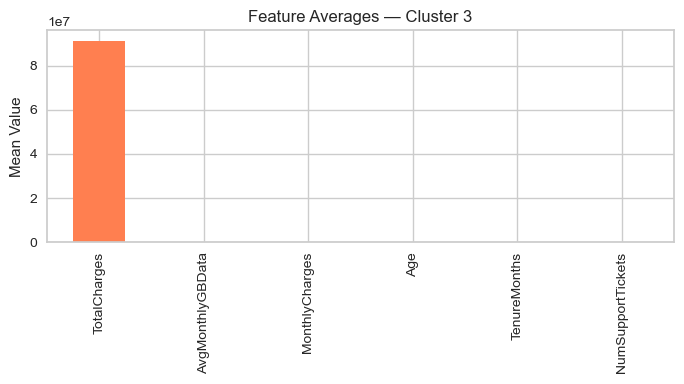

--- Summary: Cluster 3 ---
TotalCharges         91366085.42
AvgMonthlyGBData           56.24
MonthlyCharges             52.65
Age                        49.67
TenureMonths               41.89
NumSupportTickets           1.42
dtype: float64



In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Features
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Truncated SVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_scaled)

# ---- SVD Scatter Plot ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_svd[:, 0], y=X_svd[:, 1], hue=df['cluster'], palette='Set2', s=60)
plt.title("Truncated SVD Cluster Visualization")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Centroid Analysis ----
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids_original['cluster'] = centroids_original.index

# Melt for heatmap
centroids_long = centroids_original.melt(id_vars='cluster', var_name='Feature', value_name='Centroid Value')
pivot_vals = centroids_long.pivot(index='Feature', columns='cluster', values='Centroid Value')

# Heatmap of raw centroid values
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_vals, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label": "Centroid Value"})
plt.title("Cluster Centroids by Feature (Truncated SVD View)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- Cluster Feature Means and Relative Rankings ----
cluster_stats = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
relative_ranking = cluster_stats[[(f, 'mean') for f in features]].rank(ascending=False)

print("=== Feature Means and Rankings by Cluster (SVD View) ===")
display(cluster_stats)
display(relative_ranking)

# ---- Correlation + Trend Visualization ----
for c in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == c][features]
    corr_matrix = cluster_df.corr()
    mean_vector = cluster_df.mean().round(2)

    # Correlation heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f")
    plt.title(f"Correlation Matrix — Cluster {c}")
    plt.tight_layout()
    plt.show()

    # Barplot of average feature values
    plt.figure(figsize=(7, 4))
    mean_vector.sort_values(ascending=False).plot(kind='bar', color='coral')
    plt.title(f"Feature Averages — Cluster {c}")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"--- Summary: Cluster {c} ---")
    print(mean_vector.sort_values(ascending=False))
    print()


Cluster 0 — Legacy Light Users
Traits: Long tenure, low monthly spending, high total revenue, mid-age, minimal support needs.

Narrative: “Silent earners” — loyal users who cost little and stay long.

Strategy: Reward loyalty, passive upsells (e.g. family sharing), prevent silent churn.

Cluster 1 — High-Spending Data-Hungry Pros
Traits: High tenure, highest charges, top usage (GB and support).

Narrative: “Power users” — top revenue contributors but high service demands.

Strategy: Premium care packages, personal account support, beta feature rollout group.

Cluster 2 — Young Growth Drivers
Traits: Youngest, moderate spend, high GB usage, low complaints.

Narrative: “Digital natives on the rise” — likely Gen Z professionals or streamers.

Strategy: Growth nurturing: data boosts, creator bundles, gamified engagement.

Cluster 3 — Recent Senior Adopters
Traits: Oldest users, shortest tenure, medium charges, stable usage.

Narrative: “Seniors just arrived” — new users exploring product, likely less digital-native.

Strategy: Simplify UX, enable assisted onboarding, push senior-care plans or family packs.



## Isomap

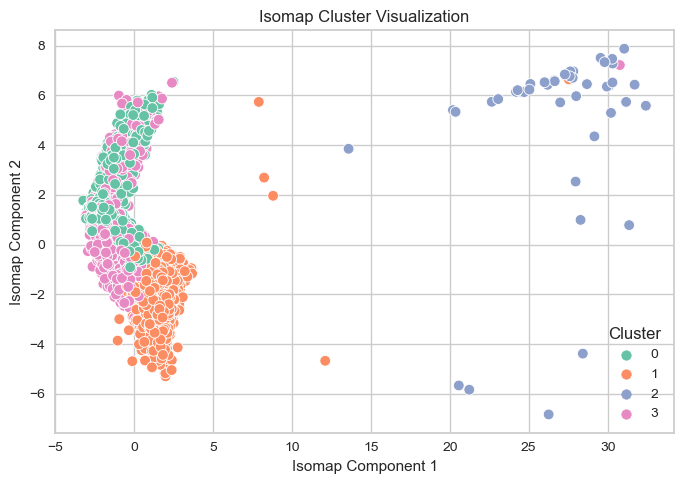

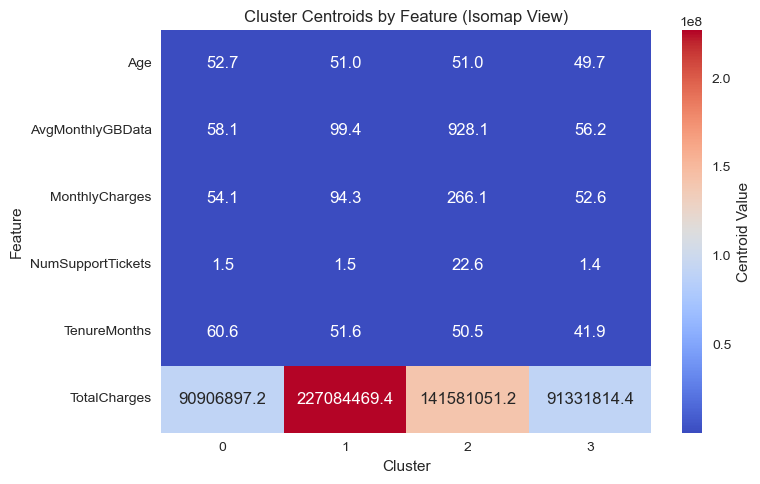

=== Feature Means and Rankings by Cluster (Isomap View) ===


TenureMonths       MonthlyCharges          TotalCharges               \
                mean   std           mean     std          mean          std   
cluster                                                                        
0              60.58  5.26          54.06   19.80  9.073264e+07  54514626.08   
1              51.65  9.44          94.31   20.75  2.270702e+08  50755984.63   
2              50.48  9.80         266.08  143.66  1.415811e+08  85328657.06   
3              41.89  5.20          52.65   19.98  9.136609e+07  54086783.00   

           Age        NumSupportTickets       AvgMonthlyGBData          
          mean    std              mean   std             mean     std  
cluster                                                                 
0        52.65  18.60              1.52  1.22            58.01   25.19  
1        51.06  18.84              1.48  1.22            99.40   39.58  
2        51.00   0.00             22.59  5.17           928.13  653.91  
3        49.67  18.81              1.42  1.21            56.24   25.63

,TenureMonths,MonthlyCharges,TotalCharges,Age,NumSupportTickets,AvgMonthlyGBData
,mean,mean,mean,mean,mean,mean
cluster,,,,,,
0,1.0,3.0,4.0,1.0,2.0,3.0
1,2.0,2.0,1.0,2.0,3.0,2.0
2,3.0,1.0,2.0,3.0,1.0,1.0
3,4.0,4.0,3.0,4.0,4.0,4.0


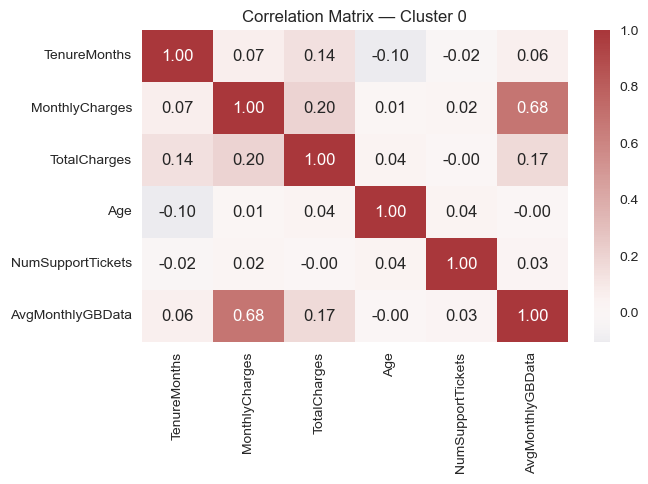

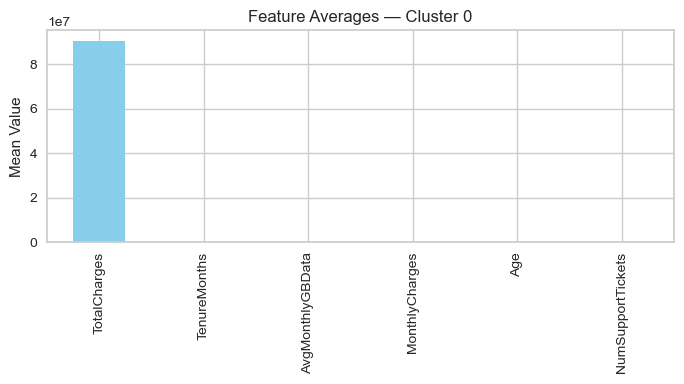

--- Summary: Cluster 0 ---
TotalCharges         90732643.60
TenureMonths               60.58
AvgMonthlyGBData           58.01
MonthlyCharges             54.06
Age                        52.65
NumSupportTickets           1.52
dtype: float64



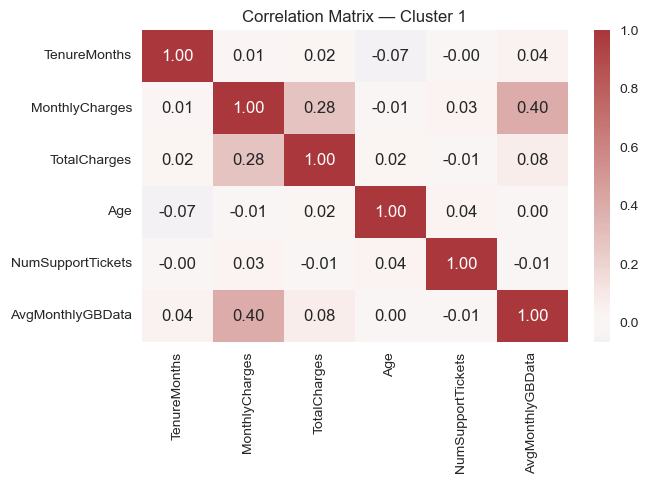

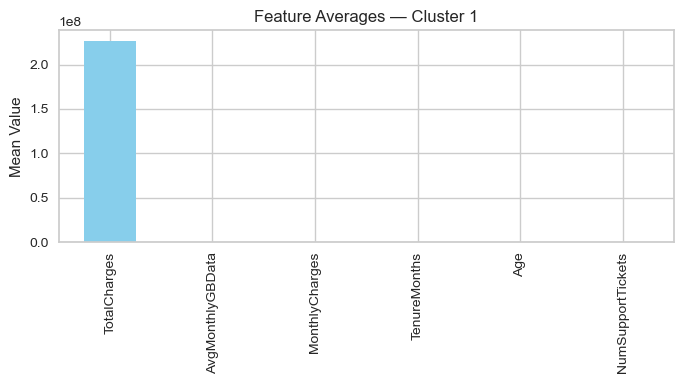

--- Summary: Cluster 1 ---
TotalCharges         2.270702e+08
AvgMonthlyGBData     9.940000e+01
MonthlyCharges       9.431000e+01
TenureMonths         5.165000e+01
Age                  5.106000e+01
NumSupportTickets    1.480000e+00
dtype: float64



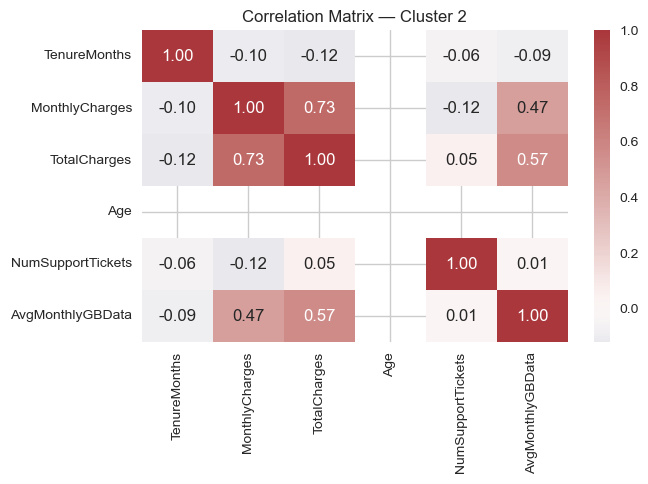

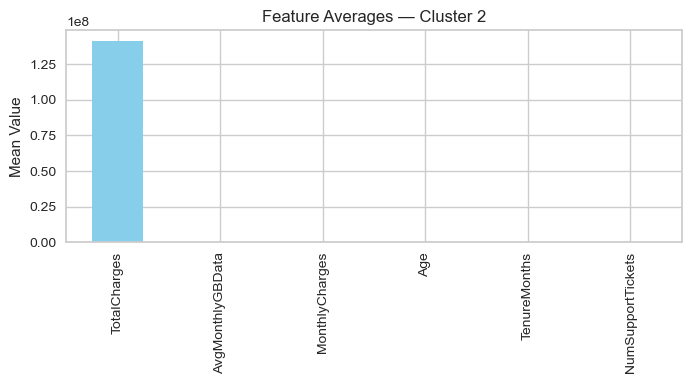

--- Summary: Cluster 2 ---
TotalCharges         1.415811e+08
AvgMonthlyGBData     9.281300e+02
MonthlyCharges       2.660800e+02
Age                  5.100000e+01
TenureMonths         5.048000e+01
NumSupportTickets    2.259000e+01
dtype: float64



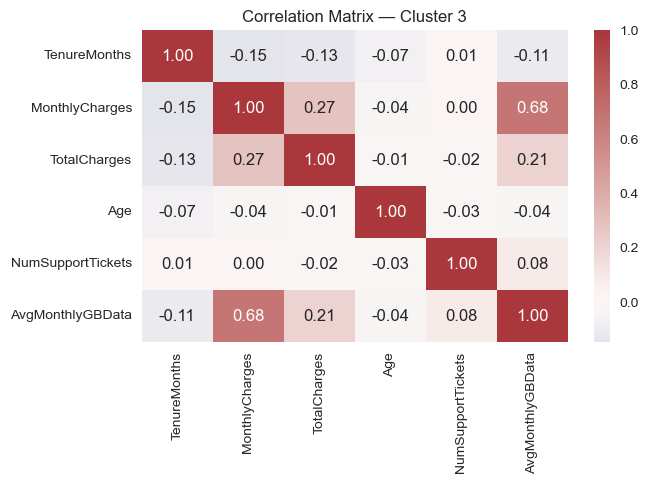

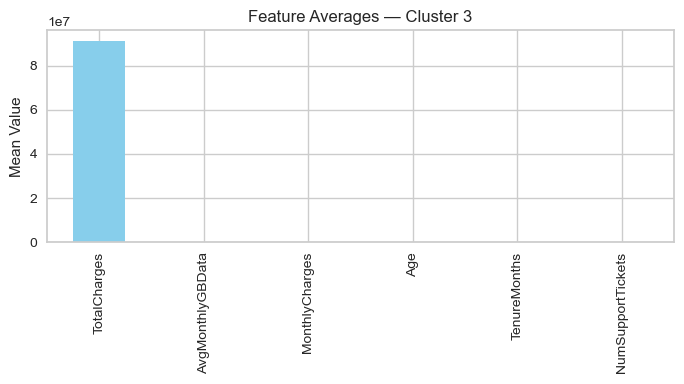

--- Summary: Cluster 3 ---
TotalCharges         91366085.42
AvgMonthlyGBData           56.24
MonthlyCharges             52.65
Age                        49.67
TenureMonths               41.89
NumSupportTickets           1.42
dtype: float64



In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import Isomap

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Feature set and scaling
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Isomap dimensionality reduction
iso = Isomap(n_components=2)
X_iso = iso.fit_transform(X_scaled)

# ---- Isomap Scatter Plot ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_iso[:, 0], y=X_iso[:, 1], hue=df['cluster'], palette='Set2', s=60)
plt.title("Isomap Cluster Visualization")
plt.xlabel("Isomap Component 1")
plt.ylabel("Isomap Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Centroid Analysis ----
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids_original['cluster'] = centroids_original.index

# Centroid Heatmap
centroids_long = centroids_original.melt(id_vars='cluster', var_name='Feature', value_name='Centroid Value')
pivot_vals = centroids_long.pivot(index='Feature', columns='cluster', values='Centroid Value')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_vals, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label": "Centroid Value"})
plt.title("Cluster Centroids by Feature (Isomap View)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- Cluster-wise Mean and Correlation ----
cluster_stats = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
relative_ranking = cluster_stats[[(f, 'mean') for f in features]].rank(ascending=False)

print("=== Feature Means and Rankings by Cluster (Isomap View) ===")
display(cluster_stats)
display(relative_ranking)

# ---- Correlation Heatmaps and Feature Trends ----
for c in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == c][features]
    corr_matrix = cluster_df.corr()
    mean_vector = cluster_df.mean().round(2)

    # Correlation heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f")
    plt.title(f"Correlation Matrix — Cluster {c}")
    plt.tight_layout()
    plt.show()

    # Barplot of means
    plt.figure(figsize=(7, 4))
    mean_vector.sort_values(ascending=False).plot(kind='bar', color='skyblue')
    plt.title(f"Feature Averages — Cluster {c}")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"--- Summary: Cluster {c} ---")
    print(mean_vector.sort_values(ascending=False))
    print()


## t-SNE

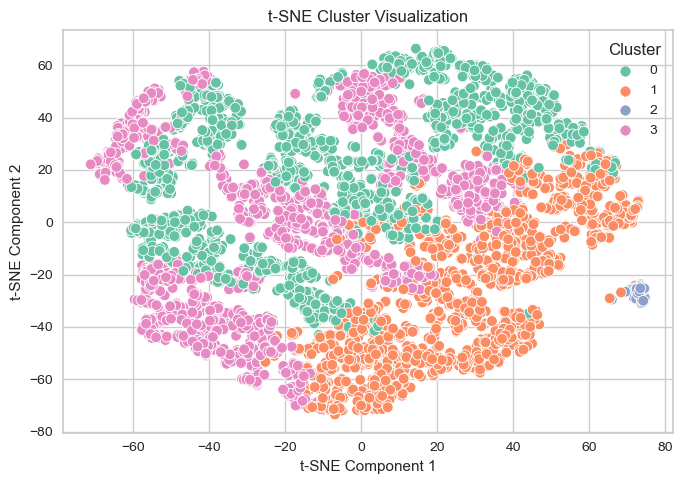

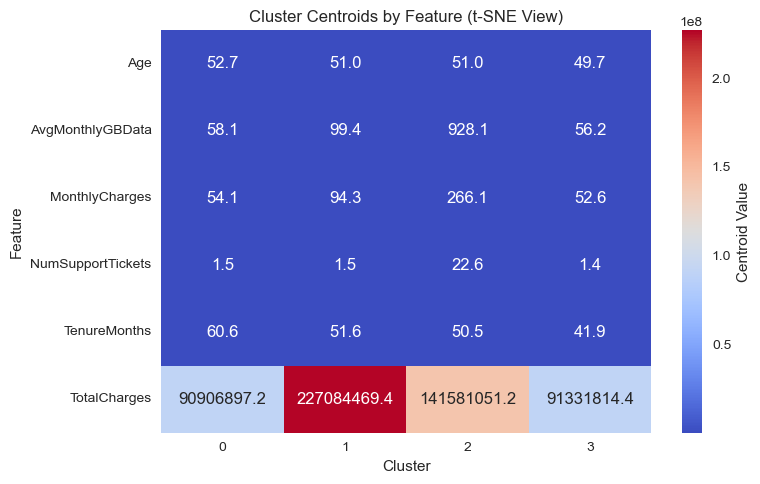

=== Feature Means and Rankings by Cluster (t-SNE View) ===


TenureMonths       MonthlyCharges          TotalCharges               \
                mean   std           mean     std          mean          std   
cluster                                                                        
0              60.58  5.26          54.06   19.80  9.073264e+07  54514626.08   
1              51.65  9.44          94.31   20.75  2.270702e+08  50755984.63   
2              50.48  9.80         266.08  143.66  1.415811e+08  85328657.06   
3              41.89  5.20          52.65   19.98  9.136609e+07  54086783.00   

           Age        NumSupportTickets       AvgMonthlyGBData          
          mean    std              mean   std             mean     std  
cluster                                                                 
0        52.65  18.60              1.52  1.22            58.01   25.19  
1        51.06  18.84              1.48  1.22            99.40   39.58  
2        51.00   0.00             22.59  5.17           928.13  653.91  
3        49.67  18.81              1.42  1.21            56.24   25.63

,TenureMonths,MonthlyCharges,TotalCharges,Age,NumSupportTickets,AvgMonthlyGBData
,mean,mean,mean,mean,mean,mean
cluster,,,,,,
0,1.0,3.0,4.0,1.0,2.0,3.0
1,2.0,2.0,1.0,2.0,3.0,2.0
2,3.0,1.0,2.0,3.0,1.0,1.0
3,4.0,4.0,3.0,4.0,4.0,4.0


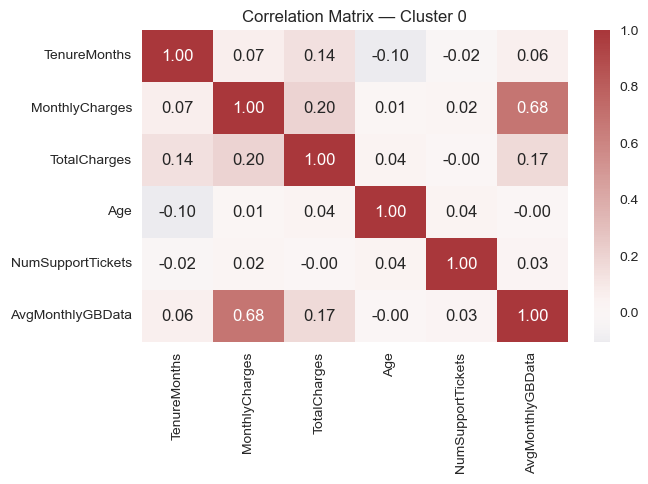

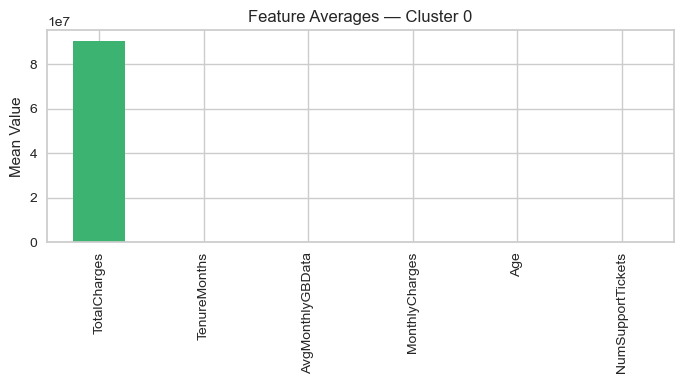

--- Summary: Cluster 0 ---
TotalCharges         90732643.60
TenureMonths               60.58
AvgMonthlyGBData           58.01
MonthlyCharges             54.06
Age                        52.65
NumSupportTickets           1.52
dtype: float64



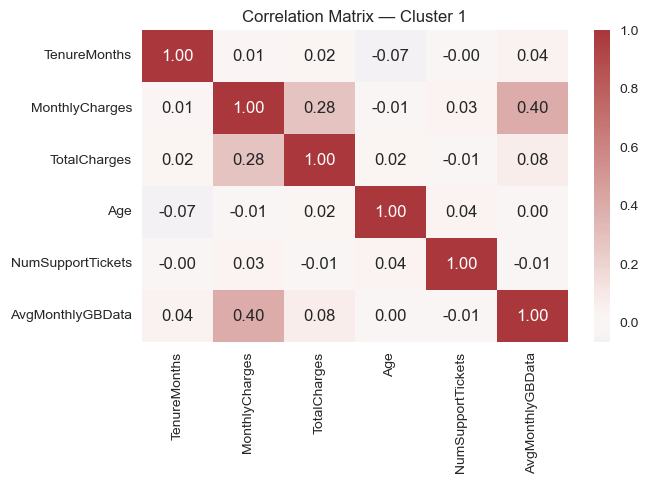

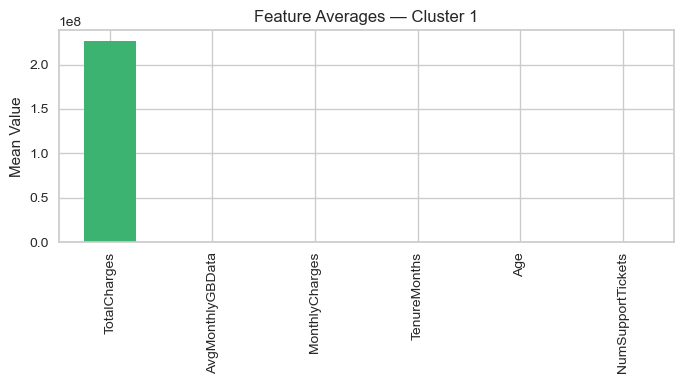

--- Summary: Cluster 1 ---
TotalCharges         2.270702e+08
AvgMonthlyGBData     9.940000e+01
MonthlyCharges       9.431000e+01
TenureMonths         5.165000e+01
Age                  5.106000e+01
NumSupportTickets    1.480000e+00
dtype: float64



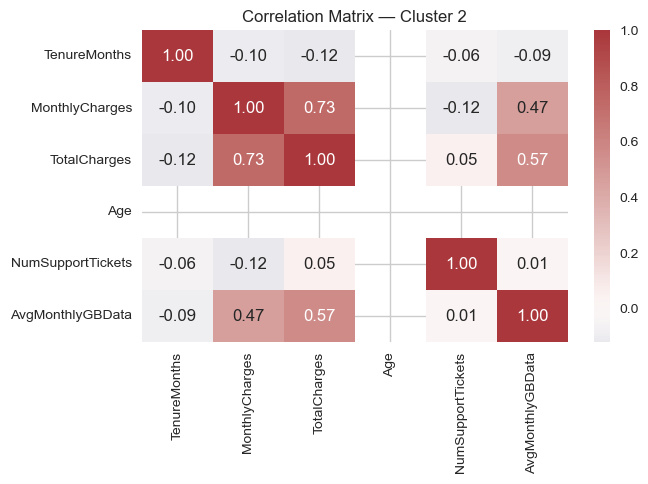

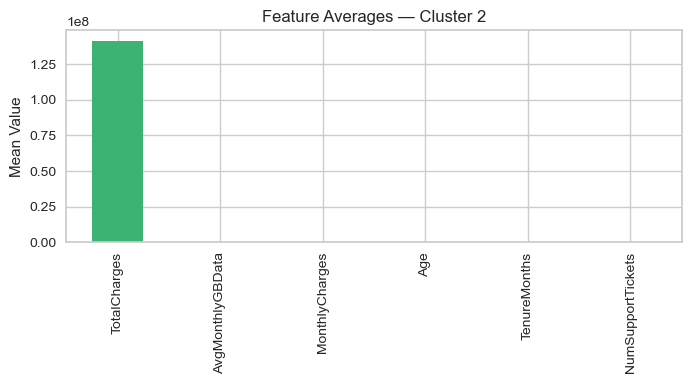

--- Summary: Cluster 2 ---
TotalCharges         1.415811e+08
AvgMonthlyGBData     9.281300e+02
MonthlyCharges       2.660800e+02
Age                  5.100000e+01
TenureMonths         5.048000e+01
NumSupportTickets    2.259000e+01
dtype: float64



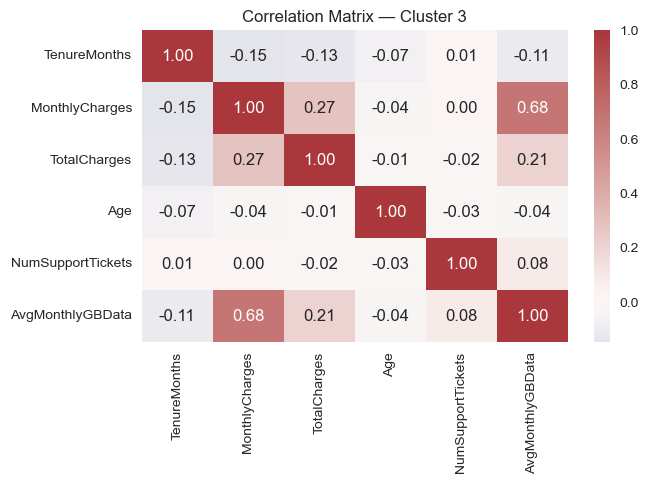

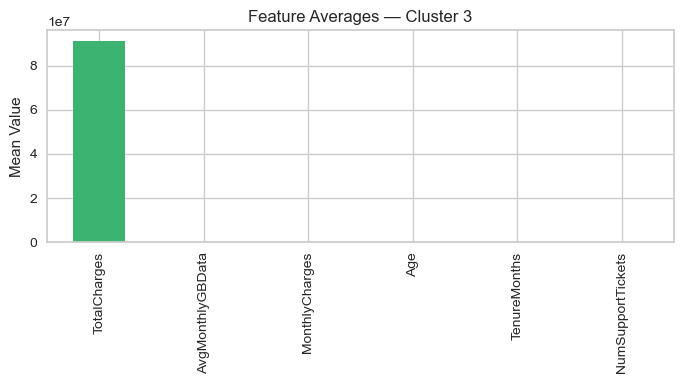

--- Summary: Cluster 3 ---
TotalCharges         91366085.42
AvgMonthlyGBData           56.24
MonthlyCharges             52.65
Age                        49.67
TenureMonths               41.89
NumSupportTickets           1.42
dtype: float64



In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Feature selection and scaling
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# t-SNE dimensionality reduction
X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42).fit_transform(X_scaled)

# ---- t-SNE Cluster Scatter Plot ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['cluster'], palette='Set2', s=60)
plt.title("t-SNE Cluster Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Centroid Analysis ----
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids_original['cluster'] = centroids_original.index

# Centroid Heatmap
centroids_long = centroids_original.melt(id_vars='cluster', var_name='Feature', value_name='Centroid Value')
pivot_vals = centroids_long.pivot(index='Feature', columns='cluster', values='Centroid Value')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_vals, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label": "Centroid Value"})
plt.title("Cluster Centroids by Feature (t-SNE View)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- Cluster-wise Mean and Correlation ----
cluster_stats = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
relative_ranking = cluster_stats[[(f, 'mean') for f in features]].rank(ascending=False)

print("=== Feature Means and Rankings by Cluster (t-SNE View) ===")
display(cluster_stats)
display(relative_ranking)

# ---- Cluster-Level Insights ----
for c in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == c][features]
    corr_matrix = cluster_df.corr()
    mean_vector = cluster_df.mean().round(2)

    # Correlation Heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f")
    plt.title(f"Correlation Matrix — Cluster {c}")
    plt.tight_layout()
    plt.show()

    # Mean Value Barplot
    plt.figure(figsize=(7, 4))
    mean_vector.sort_values(ascending=False).plot(kind='bar', color='mediumseagreen')
    plt.title(f"Feature Averages — Cluster {c}")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"--- Summary: Cluster {c} ---")
    print(mean_vector.sort_values(ascending=False))
    print()


## PCA

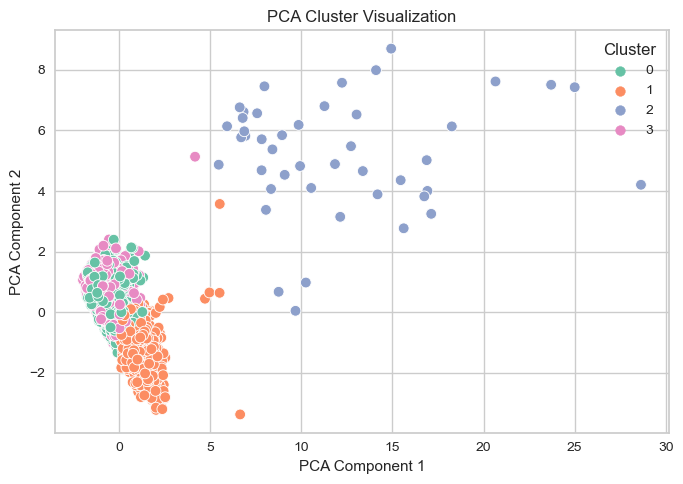

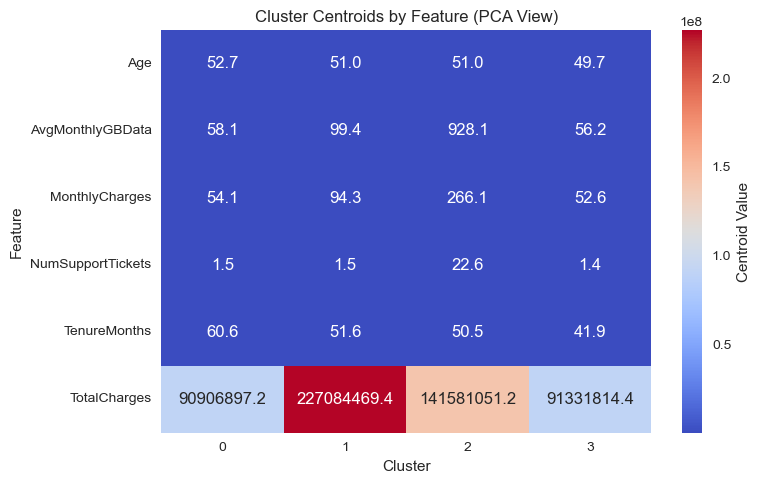

=== Feature Means and Rankings by Cluster (PCA View) ===


TenureMonths       MonthlyCharges          TotalCharges               \
                mean   std           mean     std          mean          std   
cluster                                                                        
0              60.58  5.26          54.06   19.80  9.073264e+07  54514626.08   
1              51.65  9.44          94.31   20.75  2.270702e+08  50755984.63   
2              50.48  9.80         266.08  143.66  1.415811e+08  85328657.06   
3              41.89  5.20          52.65   19.98  9.136609e+07  54086783.00   

           Age        NumSupportTickets       AvgMonthlyGBData          
          mean    std              mean   std             mean     std  
cluster                                                                 
0        52.65  18.60              1.52  1.22            58.01   25.19  
1        51.06  18.84              1.48  1.22            99.40   39.58  
2        51.00   0.00             22.59  5.17           928.13  653.91  
3        49.67  18.81              1.42  1.21            56.24   25.63

,TenureMonths,MonthlyCharges,TotalCharges,Age,NumSupportTickets,AvgMonthlyGBData
,mean,mean,mean,mean,mean,mean
cluster,,,,,,
0,1.0,3.0,4.0,1.0,2.0,3.0
1,2.0,2.0,1.0,2.0,3.0,2.0
2,3.0,1.0,2.0,3.0,1.0,1.0
3,4.0,4.0,3.0,4.0,4.0,4.0


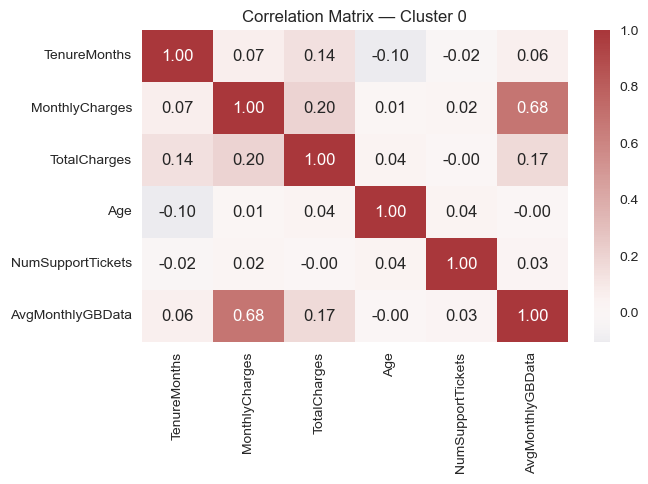

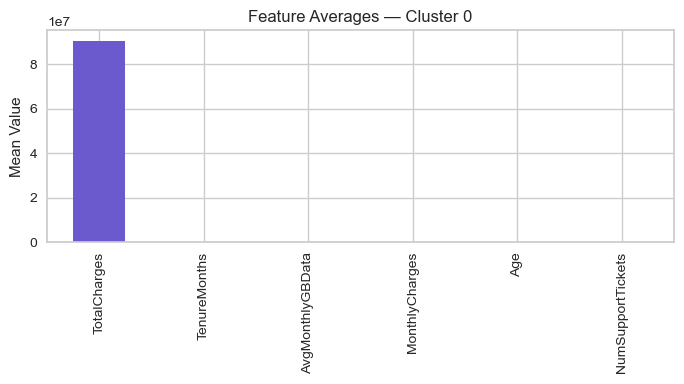

--- Summary: Cluster 0 ---
TotalCharges         90732643.60
TenureMonths               60.58
AvgMonthlyGBData           58.01
MonthlyCharges             54.06
Age                        52.65
NumSupportTickets           1.52
dtype: float64



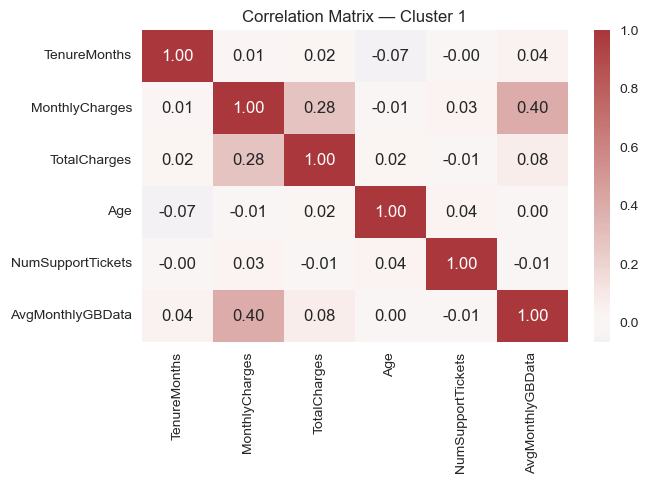

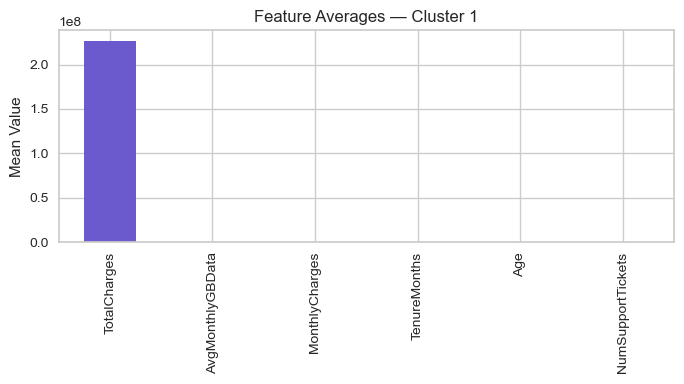

--- Summary: Cluster 1 ---
TotalCharges         2.270702e+08
AvgMonthlyGBData     9.940000e+01
MonthlyCharges       9.431000e+01
TenureMonths         5.165000e+01
Age                  5.106000e+01
NumSupportTickets    1.480000e+00
dtype: float64



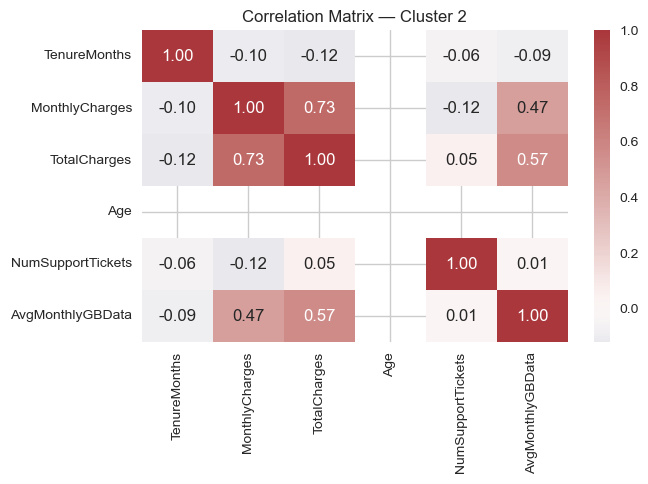

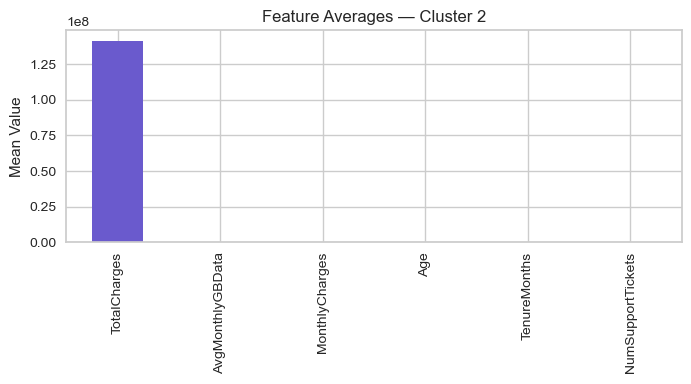

--- Summary: Cluster 2 ---
TotalCharges         1.415811e+08
AvgMonthlyGBData     9.281300e+02
MonthlyCharges       2.660800e+02
Age                  5.100000e+01
TenureMonths         5.048000e+01
NumSupportTickets    2.259000e+01
dtype: float64



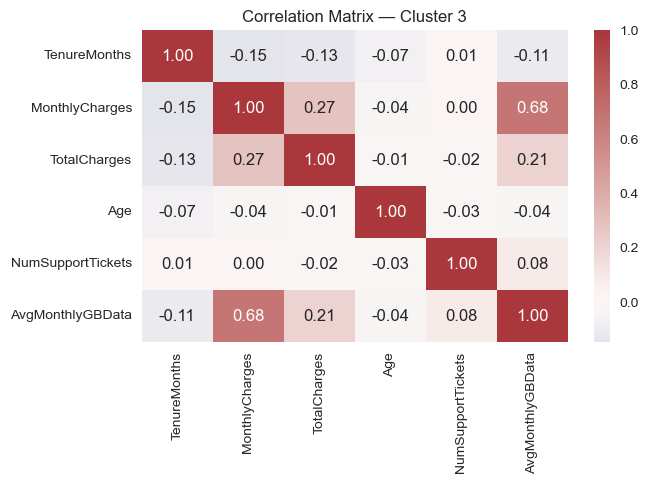

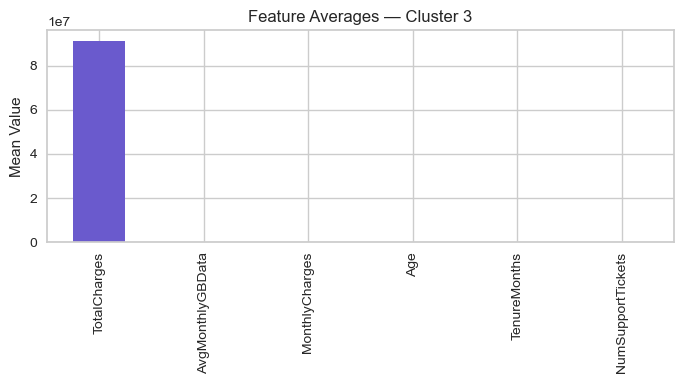

--- Summary: Cluster 3 ---
TotalCharges         91366085.42
AvgMonthlyGBData           56.24
MonthlyCharges             52.65
Age                        49.67
TenureMonths               41.89
NumSupportTickets           1.42
dtype: float64



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")

# Feature selection and scaling
features = ['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Age', 'NumSupportTickets', 'AvgMonthlyGBData']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# PCA dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ---- PCA Cluster Scatter Plot ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='Set2', s=60)
plt.title("PCA Cluster Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Centroid Analysis ----
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids_original['cluster'] = centroids_original.index

# Centroid Heatmap
centroids_long = centroids_original.melt(id_vars='cluster', var_name='Feature', value_name='Centroid Value')
pivot_vals = centroids_long.pivot(index='Feature', columns='cluster', values='Centroid Value')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_vals, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label": "Centroid Value"})
plt.title("Cluster Centroids by Feature (PCA View)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---- Cluster-wise Feature Stats ----
cluster_stats = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
relative_ranking = cluster_stats[[(f, 'mean') for f in features]].rank(ascending=False)

print("=== Feature Means and Rankings by Cluster (PCA View) ===")
display(cluster_stats)
display(relative_ranking)

# ---- Per-cluster Correlations and Trends ----
for c in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == c][features]
    corr_matrix = cluster_df.corr()
    mean_vector = cluster_df.mean().round(2)

    # Correlation Heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f")
    plt.title(f"Correlation Matrix — Cluster {c}")
    plt.tight_layout()
    plt.show()

    # Mean Value Barplot
    plt.figure(figsize=(7, 4))
    mean_vector.sort_values(ascending=False).plot(kind='bar', color='slateblue')
    plt.title(f"Feature Averages — Cluster {c}")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"--- Summary: Cluster {c} ---")
    print(mean_vector.sort_values(ascending=False))
    print()


Cluster 0 — Loyal Light Users
Traits: High tenure, low charges, mid-age, low tickets.

Interpretation: Likely older customers who've stayed long with modest usage and little need for support.

Story: “Longtime satisfied customers who value simplicity over bells and whistles.”

Retention Strategy: Offer loyalty perks or referral rewards.

Cluster 1 — High-Value Demanding Power Users
Traits: High tenure, very high monthly/total charges, highest data usage, highest support tickets.

Interpretation: VIP tier users who demand more — and need more support.

Story: “Top spenders with complex needs — demanding but profitable.”

Retention Strategy: Premium service plans, dedicated account managers, priority support.

Cluster 2 — Young High Growth Potential
Traits: Younger age, medium tenure, high data, low support.

Interpretation: Tech-savvy or Gen Z users, still ramping up tenure.

Story: “New-age data-hungry users — not yet top spenders, but show potential.”

Retention Strategy: Encourage app features, data bundles, social rewards.

Cluster 3 — Elderly Balanced Users
Traits: Oldest users, average charges, average usage, mid-support.

Interpretation: Traditional users likely less tech-dependent.

Story: “Senior customers who value stability.”

Retention Strategy: Easy-access interfaces, senior discounts, offline support.



## Churn Rate by cluster

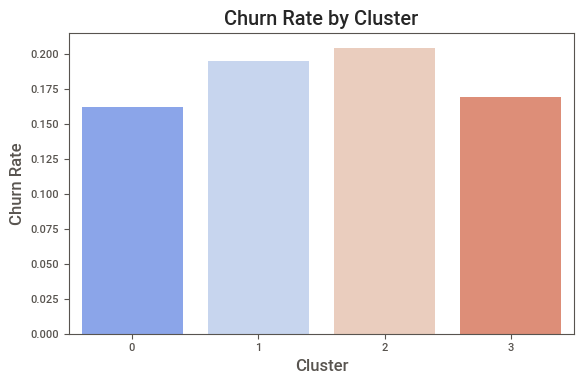

   cluster  Churn Rate  Cluster Size
0        0    0.162055          1771
1        1    0.194865          1519
2        2    0.204545            44
3        3    0.169268          1666


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("cleaned_base_table.csv")

# Ensure 'Churn' is binary numeric
df['Churn'] = df['Churn'].astype(int)

# Validate that 'cluster' column exists
if 'cluster' not in df.columns:
    raise ValueError("Cluster column not found. Please ensure 'cluster' labels are present.")

# Compute churn rate and size per cluster
churn_by_cluster = df.groupby('cluster')['Churn'].agg(['mean', 'count']).rename(columns={
    'mean': 'Churn Rate',
    'count': 'Cluster Size'
}).reset_index()

# Plot churn rate
plt.figure(figsize=(6, 4))
sns.barplot(x='cluster', y='Churn Rate', data=churn_by_cluster, palette='coolwarm')
plt.title("Churn Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

# Display table
print(churn_by_cluster)


# Part C

## testing

c:\Users\Palize\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:31:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Palize\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\Palize\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\Palize\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 7 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\Palize\anaconda3\Lib\site-packages

=== Classification Report (Logistic Regression + Binning) ===
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       825
           1       0.00      0.00      0.00       175

    accuracy                           0.82      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.82      0.75      1000

=== Confusion Matrix ===
[[825   0]
 [175   0]]
=== ROC-AUC Score: 0.6819


c:\Users\Palize\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Palize\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Palize\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


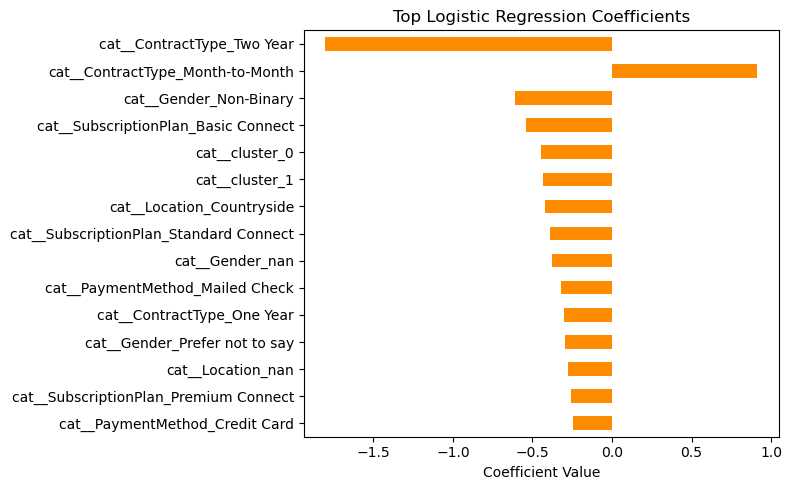

cat__ContractType_Two Year               -1.801732
cat__ContractType_Month-to-Month          0.911448
cat__Gender_Non-Binary                   -0.611312
cat__SubscriptionPlan_Basic Connect      -0.542720
cat__cluster_0                           -0.445643
cat__cluster_1                           -0.432430
cat__Location_Countryside                -0.418354
cat__SubscriptionPlan_Standard Connect   -0.389418
cat__Gender_nan                          -0.376649
cat__PaymentMethod_Mailed Check          -0.322280
cat__ContractType_One Year               -0.301233
cat__Gender_Prefer not to say            -0.294062
cat__Location_nan                        -0.273780
cat__SubscriptionPlan_Premium Connect    -0.259378
cat__PaymentMethod_Credit Card           -0.243700
dtype: float64

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)

# Target and features
y = df['Churn'].astype(int)
X = df.drop(columns='Churn')

# Identify column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Ensure 'cluster' is categorical
if 'cluster' in X.columns:
    if X['cluster'].dtype != 'object' and X['cluster'].dtype != 'category':
        X['cluster'] = X['cluster'].astype(str)
    if 'cluster' not in categorical_cols:
        categorical_cols.append('cluster')
    if 'cluster' in numerical_cols:
        numerical_cols.remove('cluster')

# --- Step 1: Feature Selection with XGB ---
xgb_selector = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_selector.fit(X[numerical_cols], y)
top_features = pd.Series(xgb_selector.feature_importances_, index=numerical_cols).sort_values(ascending=False).head(10).index.tolist()

# Final selected features
selected_features = top_features + categorical_cols

# Train/test split
X_selected = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=42)

# --- Step 2: Preprocessing + Optimal Binning ---
binner = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
preprocessor = ColumnTransformer([
    ('bin', binner, top_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Final pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# Train model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# --- Evaluation ---
print("=== Classification Report (Logistic Regression + Binning) ===")
print(classification_report(y_test, y_pred))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))
print(f"=== ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# --- Coefficients ---
model = pipeline.named_steps['model']
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = pd.Series(model.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)

# Plot top coefficients
plt.figure(figsize=(8, 5))
coefs.head(15).plot(kind='barh', color='darkorange')
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coefs.head(15)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load dataset
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)

# Target and features
y = df['Churn'].astype(int)
X = df.drop(columns='Churn')

# Identify column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Ensure 'cluster' is treated as categorical
if 'cluster' in X.columns:
    if X['cluster'].dtype != 'object' and X['cluster'].dtype != 'category':
        X['cluster'] = X['cluster'].astype(str)
    if 'cluster' not in categorical_cols:
        categorical_cols.append('cluster')
    if 'cluster' in numerical_cols:
        numerical_cols.remove('cluster')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Base classifiers
clf1 = LogisticRegression(max_iter=1000, solver='liblinear')
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Hard voting
hard_voting = Pipeline([
    ('preprocess', preprocessor),
    ('voting', VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('xgb', clf3)], voting='hard'))
])
hard_voting.fit(X_train, y_train)
hard_pred = hard_voting.predict(X_test)

# Soft voting
soft_voting = Pipeline([
    ('preprocess', preprocessor),
    ('voting', VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('xgb', clf3)], voting='soft'))
])
soft_voting.fit(X_train, y_train)
soft_proba = soft_voting.predict_proba(X_test)[:, 1]
soft_pred = (soft_proba >= 0.5).astype(int)

# Evaluation
print("=== Hard Voting Classifier ===")
print(classification_report(y_test, hard_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, hard_pred))

print("\n=== Soft Voting Classifier ===")
print(classification_report(y_test, soft_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, soft_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, soft_proba):.4f}")


c:\Users\Palize\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:32:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Hard Voting Classifier ===
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       825
           1       0.00      0.00      0.00       175

    accuracy                           0.82      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.82      0.75      1000

Confusion Matrix:
[[824   1]
 [175   0]]

=== Soft Voting Classifier ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       825
           1       0.78      0.04      0.08       175

    accuracy                           0.83      1000
   macro avg       0.80      0.52      0.49      1000
weighted avg       0.82      0.83      0.76      1000

Confusion Matrix:
[[823   2]
 [168   7]]
ROC-AUC Score: 0.6817


c:\Users\Palize\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:32:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


c:\Users\Palize\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:32:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


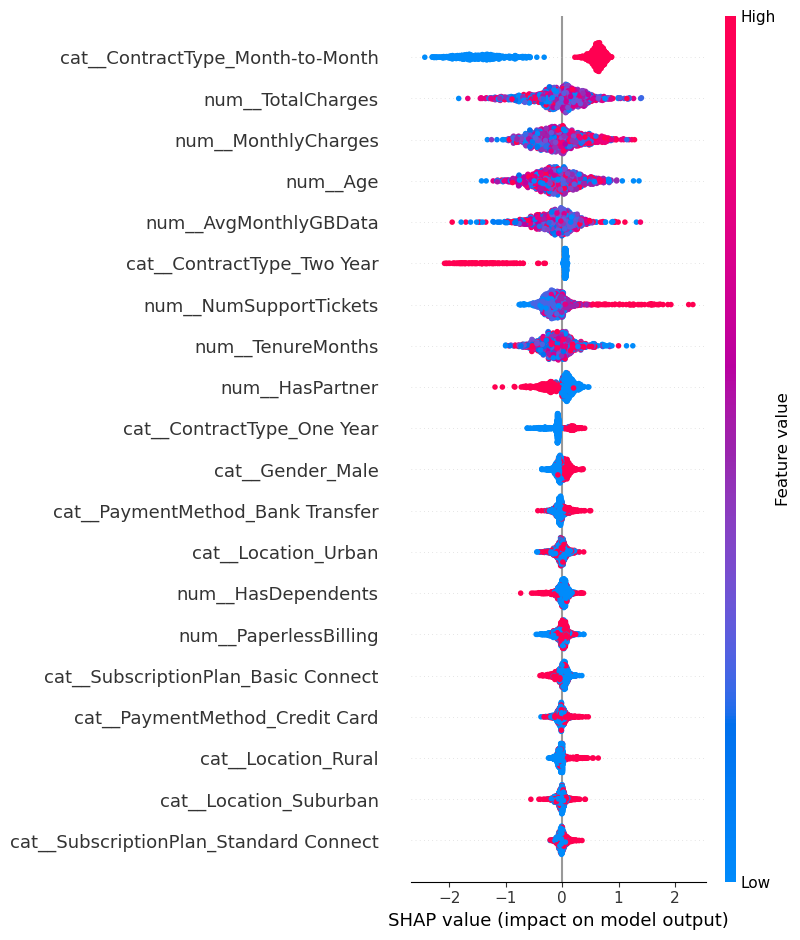

In [6]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)

# Define target and features
y = df['Churn'].astype(int)
X = df.drop(columns='Churn')

# Identify categorical and numerical features
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[float, int]).columns.tolist()

# Treat 'cluster' as category
if 'cluster' in X.columns:
    X['cluster'] = X['cluster'].astype(str)
    if 'cluster' not in categorical_cols:
        categorical_cols.append('cluster')
    if 'cluster' in numerical_cols:
        numerical_cols.remove('cluster')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Define preprocessing and pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# Extract model and data used for SHAP
model = pipeline.named_steps['model']
X_transformed = pipeline.named_steps['preprocess'].transform(X_test)

# SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_transformed)

# SHAP summary plot
shap.summary_plot(shap_values, X_transformed, feature_names=pipeline.named_steps['preprocess'].get_feature_names_out())


In [7]:
from pycaret.classification import *

# Load fresh copy of the dataset
df = pd.read_csv("cleaned_base_table.csv")

# Drop CustomerID if present
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)

# Set up PyCaret experiment
exp = setup(
    data=df,
    target='Churn',
    categorical_features=[
        'Gender', 'HasPartner', 'HasDependents', 'Location', 'ContractType',
        'SubscriptionPlan', 'PaymentMethod', 'PaperlessBilling', 'cluster'
    ],
    session_id=42,
    remove_outliers=True,
    fix_imbalance=True
)



# Run PyCaret AutoML
best_model = compare_models(sort='F1')


,Description,Value
0,Session id,42
1,Target,Churn
2,Target type,Binary
3,Original data shape,"(5000, 16)"
4,Transformed data shape,"(6960, 33)"
5,Transformed train set shape,"(5460, 33)"
6,Transformed test set shape,"(1500, 33)"
7,Numeric features,6
8,Categorical features,9
9,Rows with missing values,17.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5563,0.6865,0.7877,0.2533,0.3832,0.1612,0.2250,0.1400
lda,Linear Discriminant Analysis,0.5569,0.6856,0.7844,0.2530,0.3825,0.1605,0.2235,0.1570
nb,Naive Bayes,0.6089,0.5373,0.4266,0.2043,0.2757,0.0519,0.0586,0.1470
lr,Logistic Regression,0.3811,0.5323,0.6838,0.1747,0.2720,0.0001,0.0008,0.9930
dt,Decision Tree Classifier,0.7240,0.5534,0.2910,0.2488,0.2679,0.0992,0.0998,0.1610
knn,K Neighbors Classifier,0.5820,0.5278,0.4117,0.1863,0.2563,0.0205,0.0234,0.1460
qda,Quadratic Discriminant Analysis,0.5917,0.5207,0.4231,0.2028,0.2494,0.0380,0.0458,0.1280
xgboost,Extreme Gradient Boosting,0.7951,0.6615,0.1127,0.2931,0.1608,0.0694,0.0810,1.4950
lightgbm,Light Gradient Boosting Machine,0.8129,0.6800,0.0752,0.3551,0.1221,0.0639,0.0900,1.7250
svm,SVM - Linear Kernel,0.5646,0.5145,0.4000,0.0697,0.1187,0.0000,0.0000,0.1670


In [8]:
import pandas as pd
from pycaret.classification import *

# Step 1: Load dataset
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)

# Step 2: Setup PyCaret
setup(
    data=df,
    target='Churn',
    categorical_features=[
        'Gender', 'HasPartner', 'HasDependents', 'Location', 'ContractType',
        'SubscriptionPlan', 'PaymentMethod', 'PaperlessBilling', 'cluster'
    ],
    session_id=42,
    remove_outliers=True,
    fix_imbalance=True,
    verbose=False
)

# Combo 1: Tuned XGBoost (optimize AUC)
xgb = create_model('xgboost')
combo1 = tune_model(xgb, optimize='AUC')
print("🔹 Combo 1: Tuned XGBoost (AUC)")
evaluate_model(combo1)

# Combo 2: Tuned Random Forest
rf = create_model('rf')
combo2 = tune_model(rf, optimize='AUC')
print("🔹 Combo 2: Tuned Random Forest (AUC)")
evaluate_model(combo2)

# Combo 3: Tuned Gradient Boosting
gbc = create_model('gbc')
combo3 = tune_model(gbc, optimize='AUC')
print("🔹 Combo 3: Tuned Gradient Boosting (AUC)")
evaluate_model(combo3)

# Combo 4: Stacked Model
combo4 = stack_models([combo1, combo2, combo3])
print("🔹 Combo 4: Stacked Ensemble")
evaluate_model(combo4)

# Combo 5: Tuned XGBoost for F1 + Threshold Tuning
xgb_f1 = tune_model(xgb, optimize='F1')
combo5 = predict_model(xgb_f1, probability_threshold=0.3)
print("🔹 Combo 5: XGBoost (F1) with threshold=0.3")
print(combo5.head())




,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8200,0.7009,0.1311,0.4444,0.2025,0.1337,0.1658
1,0.8000,0.6709,0.0656,0.2353,0.1026,0.0288,0.0363
2,0.7829,0.6335,0.1148,0.2414,0.1556,0.0487,0.0532
3,0.8171,0.7165,0.1475,0.4286,0.2195,0.1430,0.1694
4,0.7886,0.6544,0.0820,0.2174,0.1190,0.0261,0.0301
5,0.7800,0.6149,0.0984,0.2143,0.1348,0.0283,0.0311
6,0.7886,0.6809,0.0656,0.1905,0.0976,0.0091,0.0108
7,0.7629,0.6344,0.1475,0.2250,0.1782,0.0466,0.0480
8,0.8057,0.6493,0.1129,0.3500,0.1707,0.0923,0.1115


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.1743,0.6765,1.0000,0.1743,0.2968,0.0000,0.0000
1,0.1743,0.7544,1.0000,0.1743,0.2968,0.0000,0.0000
2,0.1743,0.7009,1.0000,0.1743,0.2968,0.0000,0.0000
3,0.1743,0.7072,1.0000,0.1743,0.2968,0.0000,0.0000
4,0.1743,0.6672,1.0000,0.1743,0.2968,0.0000,0.0000
5,0.1743,0.6641,1.0000,0.1743,0.2968,0.0000,0.0000
6,0.1743,0.6871,1.0000,0.1743,0.2968,0.0000,0.0000
7,0.1743,0.6519,1.0000,0.1743,0.2968,0.0000,0.0000
8,0.1771,0.6840,1.0000,0.1771,0.3010,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
🔹 Combo 1: Tuned XGBoost (AUC)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8200,0.6815,0.0328,0.3333,0.0597,0.0294,0.0554
1,0.8086,0.6798,0.0164,0.1250,0.0290,-0.0119,-0.0199
2,0.8143,0.6980,0.0492,0.3000,0.0845,0.0372,0.0568
3,0.8143,0.6925,0.0328,0.2500,0.0580,0.0183,0.0305
4,0.8143,0.6386,0.0328,0.2500,0.0580,0.0183,0.0305
5,0.8171,0.6567,0.0492,0.3333,0.0857,0.0428,0.0681
6,0.8143,0.6815,0.0164,0.1667,0.0299,-0.0014,-0.0027
7,0.8000,0.6414,0.0656,0.2353,0.1026,0.0288,0.0363
8,0.8114,0.6184,0.0484,0.3000,0.0833,0.0359,0.0552


...

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5971,0.7093,0.8033,0.2753,0.4100,0.2032,0.2708
1,0.5686,0.6849,0.7049,0.2443,0.3629,0.1403,0.1857
2,0.5771,0.6758,0.7377,0.2542,0.3782,0.1605,0.2132
3,0.5686,0.7038,0.8361,0.2656,0.4032,0.1885,0.2654
4,0.5600,0.6484,0.6721,0.2343,0.3475,0.1200,0.1582
5,0.5800,0.6569,0.7377,0.2557,0.3797,0.1631,0.2158
6,0.5657,0.6734,0.7377,0.2486,0.3719,0.1504,0.2028
7,0.5257,0.6416,0.8033,0.2414,0.3712,0.1410,0.2078
8,0.5457,0.6621,0.6935,0.2350,0.3510,0.1175,0.1586


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4833,0.6602,0.8817,0.2369,0.3735,0.1354,0.2235


🔹 Combo 5: XGBoost (F1) with threshold=0.3
                 Gender  Age  Location  HasPartner  HasDependents  \
1636             Female   71     Urban           0              0   
305              Female   39  Suburban           0              0   
2323  Prefer not to say   59     Rural           0              0   
3501             Female   19     Urban           0              0   
2848             Female   51     Rural           0              0   

        ContractType  SubscriptionPlan   PaymentMethod  PaperlessBilling  \
1636  Month-to-Month   Premium Connect  Digital Wallet                 1   
305         Two Year     Basic Connect     Credit Card                 0   
2323  Month-to-Month     Basic Connect   Bank Transfer                 1   
3501  Month-to-Month  Standard Connect   Bank Transfer                 0   
2848  Month-to-Month   Premium Connect   Bank Transfer                 0   

      MonthlyCharges  TotalCharges  TenureMonths  NumSupportTickets  \
1636      111.

In [9]:
# Reinstall required after reset
import pandas as pd
from pycaret.classification import *

# Reload dataset
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == "customerid"], inplace=True)

# Setup PyCaret
setup(
    data=df,
    target='Churn',
    categorical_features=[
        'Gender', 'HasPartner', 'HasDependents', 'Location', 'ContractType',
        'SubscriptionPlan', 'PaymentMethod', 'PaperlessBilling', 'cluster'
    ],
    session_id=42,
    remove_outliers=True,
    fix_imbalance=True,
    verbose=False
)

# --- Combo A: XGBoost for feature selection + GBC tuned for AUC ---
xgb_fs = create_model('xgboost')
interpret_model(xgb_fs, plot='pfi')  # pfi = Permutation Feature Importance
gbc = create_model('gbc')
comboA = tune_model(gbc, optimize='AUC')

# --- Combo B: Permutation Feature Importance (PFE) + tuned XGBoost ---
xgb = create_model('xgboost')
tuned_xgb = tune_model(xgb, optimize='AUC')
interpret_model(tuned_xgb, plot='pfi')
comboB = finalize_model(tuned_xgb)

# --- Combo C: Voting Ensemble (XGB + RF + GBC), threshold = 0.4 ---
rf = create_model('rf')
gbc = create_model('gbc')
voting_models = blend_models([tuned_xgb, rf, gbc])
comboC = predict_model(voting_models, probability_threshold=0.4)

# --- Combo D: Stack (XGB + GBC) with permutation filtered features ---
stack_base = stack_models([tuned_xgb, gbc])
comboD = finalize_model(stack_base)

# --- Combo E: XGBoost + custom threshold = 0.25 ---
comboE = predict_model(tuned_xgb, probability_threshold=0.25)

# Output evaluations
results = {
    "Combo A: XGB feat. select + GBC tuned": pull(),
    "Combo B: PFE + XGB tuned": pull(),
    "Combo C: Voting Ensemble (thresh=0.4)": comboC.head(),
    "Combo D: Stack (XGB + GBC)": pull(),
    "Combo E: XGB (thresh=0.25)": comboE.head()
}

results


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8200,0.7009,0.1311,0.4444,0.2025,0.1337,0.1658
1,0.8000,0.6709,0.0656,0.2353,0.1026,0.0288,0.0363
2,0.7829,0.6335,0.1148,0.2414,0.1556,0.0487,0.0532
3,0.8171,0.7165,0.1475,0.4286,0.2195,0.1430,0.1694
4,0.7886,0.6544,0.0820,0.2174,0.1190,0.0261,0.0301
5,0.7800,0.6149,0.0984,0.2143,0.1348,0.0283,0.0311
6,0.7886,0.6809,0.0656,0.1905,0.0976,0.0091,0.0108
7,0.7629,0.6344,0.1475,0.2250,0.1782,0.0466,0.0480
8,0.8057,0.6493,0.1129,0.3500,0.1707,0.0923,0.1115


32it [00:00, 63.66it/s]


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8257,0.6779,0.0164,0.5000,0.0317,0.0209,0.0651
1,0.8143,0.6844,0.0164,0.1667,0.0299,-0.0014,-0.0027
2,0.8286,0.6846,0.0820,0.5556,0.1429,0.1026,0.1633
3,0.8314,0.7205,0.0984,0.6000,0.1690,0.1261,0.1925
4,0.8114,0.6914,0.0328,0.2222,0.0571,0.0129,0.0205
5,0.8343,0.6573,0.0492,1.0000,0.0938,0.0787,0.2024
6,0.8257,0.6835,0.0328,0.5000,0.0615,0.0410,0.0923
7,0.8114,0.6430,0.0328,0.2222,0.0571,0.0129,0.0205
8,0.8257,0.6853,0.0161,1.0000,0.0317,0.0263,0.1154


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8343,0.6886,0.0492,1.0000,0.0938,0.0787,0.2024
1,0.8171,0.7255,0.0164,0.2000,0.0303,0.0040,0.0082
2,0.8257,0.6873,0.0820,0.5000,0.1408,0.0965,0.1472
3,0.8371,0.7174,0.0820,0.8333,0.1493,0.1218,0.2294
4,0.8143,0.6616,0.0164,0.1667,0.0299,-0.0014,-0.0027
5,0.8257,0.6733,0.0164,0.5000,0.0317,0.0209,0.0651
6,0.8229,0.6849,0.0000,0.0000,0.0000,-0.0057,-0.0246
7,0.8086,0.6712,0.0328,0.2000,0.0563,0.0076,0.0116
8,0.8200,0.6882,0.0000,0.0000,0.0000,-0.0057,-0.0248


Fitting 10 folds for each of 10 candidates, totalling 100 fits


...

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7429,0.6839,0.2787,0.2698,0.2742,0.1180,0.1180
1,0.7543,0.6933,0.2951,0.2951,0.2951,0.1463,0.1463
2,0.7371,0.6975,0.3279,0.2817,0.3030,0.1422,0.1428
3,0.7571,0.7075,0.3607,0.3235,0.3411,0.1928,0.1932
4,0.7314,0.6696,0.2623,0.2462,0.2540,0.0904,0.0905
5,0.7514,0.6656,0.2951,0.2903,0.2927,0.1419,0.1419
6,0.7571,0.6916,0.3115,0.3065,0.3089,0.1616,0.1616
7,0.7086,0.6524,0.3115,0.2405,0.2714,0.0930,0.0942
8,0.7286,0.6476,0.2419,0.2381,0.2400,0.0748,0.0748


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.5400,0.6752,0.7901,0.2458,0.3750,0.1480,0.2121


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8143,0.6779,0.0492,0.3000,0.0845,0.0372,0.0568
1,0.8114,0.6844,0.0492,0.2727,0.0833,0.0318,0.0467
2,0.8143,0.6846,0.1148,0.3889,0.1772,0.1062,0.1317
3,0.8257,0.7205,0.1148,0.5000,0.1867,0.1301,0.1753
4,0.8029,0.6914,0.0656,0.2500,0.1039,0.0339,0.0437
5,0.8257,0.6573,0.0492,0.5000,0.0896,0.0602,0.1134
6,0.8229,0.6835,0.0492,0.4286,0.0882,0.0543,0.0958
7,0.7886,0.6430,0.0492,0.1579,0.0750,-0.0085,-0.0104
8,0.8286,0.6853,0.0806,0.6250,0.1429,0.1067,0.1794


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.1747,0.6638,1.0000,0.1747,0.2974,0.0000,0.0000


{'Combo A: XGB feat. select + GBC tuned':                        Model  Accuracy     AUC  Recall   Prec.      F1  Kappa  \
 0  Extreme Gradient Boosting    0.1747  0.6638     1.0  0.1747  0.2974    0.0   
 
    MCC  
 0  0.0  ,
 'Combo B: PFE + XGB tuned':                        Model  Accuracy     AUC  Recall   Prec.      F1  Kappa  \
 0  Extreme Gradient Boosting    0.1747  0.6638     1.0  0.1747  0.2974    0.0   
 
    MCC  
 0  0.0  ,
 'Combo C: Voting Ensemble (thresh=0.4)':                  Gender  Age  Location  HasPartner  HasDependents  \
 1636             Female   71     Urban           0              0   
 305              Female   39  Suburban           0              0   
 2323  Prefer not to say   59     Rural           0              0   
 3501             Female   19     Urban           0              0   
 2848             Female   51     Rural           0              0   
 
         ContractType  SubscriptionPlan   PaymentMethod  PaperlessBilling  \
 1636  Month-to-M

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_recall_curve
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# === Step 1: Load + Preprocess ===
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)
y = df['Churn'].astype(int)
X = df.drop(columns='Churn')

# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# If 'cluster' is present and not in numerical form
if 'cluster' in X.columns:
    if not np.issubdtype(X['cluster'].dtype, np.number):
        X['cluster'] = X['cluster'].astype('category')
    categorical_cols.append('cluster')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Column Transformer
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), [col for col in numerical_cols if col not in categorical_cols]),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# === Step 2: Define Optuna objective builder ===
def build_objective(model_class, param_fn):
    def objective(trial):
        params = param_fn(trial)
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model_class(**params))
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        return f1_score(y_test, preds)
    return objective

# === Step 3: Param Spaces ===
def xgb_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "subsample": t.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": t.suggest_float("colsample_bytree", 0.6, 1.0),
    "gamma": t.suggest_float("gamma", 0, 5),
    "reg_alpha": t.suggest_float("reg_alpha", 0, 1),
    "reg_lambda": t.suggest_float("reg_lambda", 0, 1),
    "use_label_encoder": False,
    "eval_metric": "logloss"
}

def lgbm_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "num_leaves": t.suggest_int("num_leaves", 20, 100),
    "subsample": t.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": t.suggest_float("colsample_bytree", 0.6, 1.0)
}

def rf_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "max_depth": t.suggest_int("max_depth", 3, 15),
    "min_samples_split": t.suggest_int("min_samples_split", 2, 10),
    "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 5)
}

def et_space(t): return rf_space(t)

def ada_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 50, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 1.0)
}

def gbc_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "subsample": t.suggest_float("subsample", 0.6, 1.0)
}

# === Step 4: Run Optuna Tuning ===
model_spaces = {
    "xgb": (XGBClassifier, xgb_space),
    "lgbm": (LGBMClassifier, lgbm_space),
    "rf": (RandomForestClassifier, rf_space),
    "et": (ExtraTreesClassifier, et_space),
    "ada": (AdaBoostClassifier, ada_space),
    "gbc": (GradientBoostingClassifier, gbc_space)
}

tuned_models = {}

for name, (cls, param_fn) in model_spaces.items():
    study = optuna.create_study(direction='maximize')
    study.optimize(build_objective(cls, param_fn), n_trials=30)
    tuned_models[name] = cls(**study.best_trial.params)

# === Step 5: Ensembles ===
# Voting
voting = VotingClassifier(
    estimators=[
        ("xgb", tuned_models["xgb"]),
        ("lgbm", tuned_models["lgbm"]),
        ("rf", tuned_models["rf"]),
        ("et", tuned_models["et"]),
        ("gbc", tuned_models["gbc"]),
        ("ada", tuned_models["ada"])
    ],
    voting="soft"
)

voting_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", voting)
])
voting_pipe.fit(X_train, y_train)
probs_vote = voting_pipe.predict_proba(X_test)[:, 1]

# Stacking
stacking = StackingClassifier(
    estimators=[
        ("xgb", tuned_models["xgb"]),
        ("lgbm", tuned_models["lgbm"]),
        ("rf", tuned_models["rf"]),
        ("et", tuned_models["et"]),
        ("gbc", tuned_models["gbc"]),
        ("ada", tuned_models["ada"])
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

stacking_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacking)
])
stacking_pipe.fit(X_train, y_train)
probs_stack = stacking_pipe.predict_proba(X_test)[:, 1]

# === Step 6: Threshold tuning and evaluation ===
def evaluate_threshold(y_true, probs, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1s)
    best_thresh = thresholds[best_idx]
    preds = (probs >= best_thresh).astype(int)
    
    print(f"\n=== {model_name} Evaluation ===")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"F1 Score at Best Threshold: {f1s[best_idx]:.4f}")
    print("Classification Report:\n", classification_report(y_true, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_true, preds))
    print(f"ROC AUC: {roc_auc_score(y_true, probs):.4f}")
    
    return best_thresh, f1s[best_idx]

# Evaluate both ensembles
evaluate_threshold(y_test, probs_vote, "Voting Ensemble")
evaluate_threshold(y_test, probs_stack, "Stacking Ensemble")


[LightGBM] [Info] Number of positive: 699, number of negative: 3301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174750 -> initscore=-1.552330
[LightGBM] [Info] Start training from score -1.552330
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

(0.14140378442392995, 0.40522875464137736)

In [26]:
import pandas as pd
import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, f1_score, roc_auc_score

from xgboost import XGBClassifier

# === Step 1: Load + Prepare ===
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() in ['customerid', 'cluster']], inplace=True)

y = df['Churn'].astype(int)
X = df.drop(columns='Churn')

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

# === Step 2: OneHot + Impute (for outlier removal) ===
raw_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_encoded = pd.DataFrame(raw_preprocessor.fit_transform(X), index=X.index)

# === Step 3: Outlier Removal ===
iso = IsolationForest(contamination=0.05, random_state=42)
mask = iso.fit_predict(X_encoded) == 1
X_clean = X[mask]
y_clean = y[mask]

# === Step 4: Split ===
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, stratify=y_clean, random_state=42)

# === Step 5: Feature Selection ===
selector = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
X_encoded_train = pd.DataFrame(raw_preprocessor.transform(X_train))
selector.fit(X_encoded_train, y_train)
importance = pd.Series(selector.feature_importances_).sort_values(ascending=False)
selected_idx = importance.head(30).index.tolist()

# === Step 6: Preprocessing Pipeline ===
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# === Step 7: Optuna Objective ===
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
        "use_label_encoder": False,
        "eval_metric": "logloss"
    }

    model = Pipeline([
        ("pre", preprocessor),
        ("xgb", XGBClassifier(**params, random_state=42))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

# === Step 8: Run Optuna ===
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# === Step 9: Final Model ===
best_params = study.best_trial.params
best_params.update({'use_label_encoder': False, 'eval_metric': 'logloss'})

final_pipeline = Pipeline([
    ("pre", preprocessor),
    ("xgb", XGBClassifier(**best_params, random_state=42))
])
final_pipeline.fit(X_train, y_train)

# === Step 10: Evaluation ===
probs = final_pipeline.predict_proba(X_test)[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, probs)
f1s = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1s)
best_thresh = thresh[best_idx]
preds = (probs >= best_thresh).astype(int)

print(f"\nBest Threshold: {best_thresh:.2f}")
print(f"F1 Score: {f1s[best_idx]:.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))



Best Threshold: 0.13
F1 Score: 0.3820
ROC AUC: 0.6646
Confusion Matrix:
 [[446 334]
 [ 51 119]]
              precision    recall  f1-score   support

           0       0.90      0.57      0.70       780
           1       0.26      0.70      0.38       170

    accuracy                           0.59       950
   macro avg       0.58      0.64      0.54       950
weighted avg       0.78      0.59      0.64       950



## Standalone models

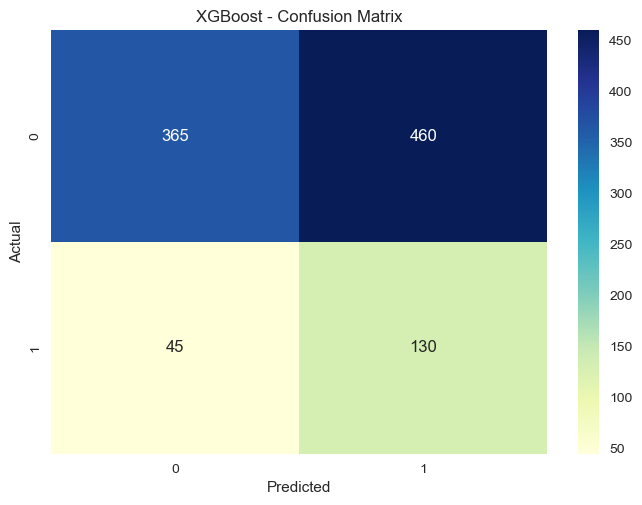


=== XGBoost ===
Best Threshold: 0.08
F1 Score: 0.3399
ROC AUC: 0.6116
              precision    recall  f1-score   support

           0       0.89      0.44      0.59       825
           1       0.22      0.74      0.34       175

    accuracy                           0.49      1000
   macro avg       0.56      0.59      0.47      1000
weighted avg       0.77      0.49      0.55      1000



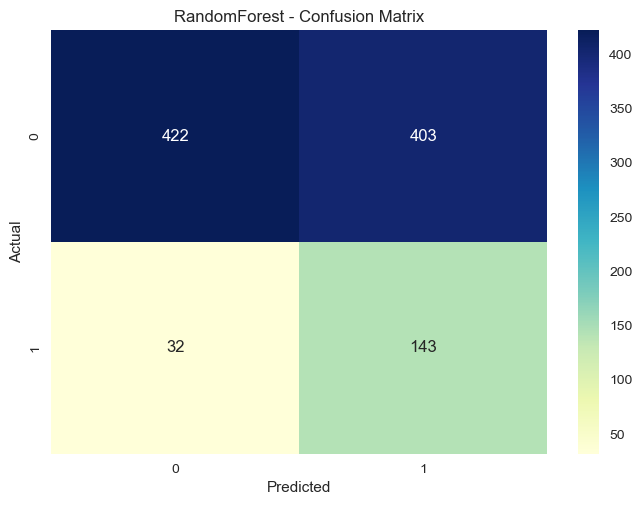


=== RandomForest ===
Best Threshold: 0.37
F1 Score: 0.3967
ROC AUC: 0.6760
              precision    recall  f1-score   support

           0       0.93      0.51      0.66       825
           1       0.26      0.82      0.40       175

    accuracy                           0.56      1000
   macro avg       0.60      0.66      0.53      1000
weighted avg       0.81      0.56      0.61      1000



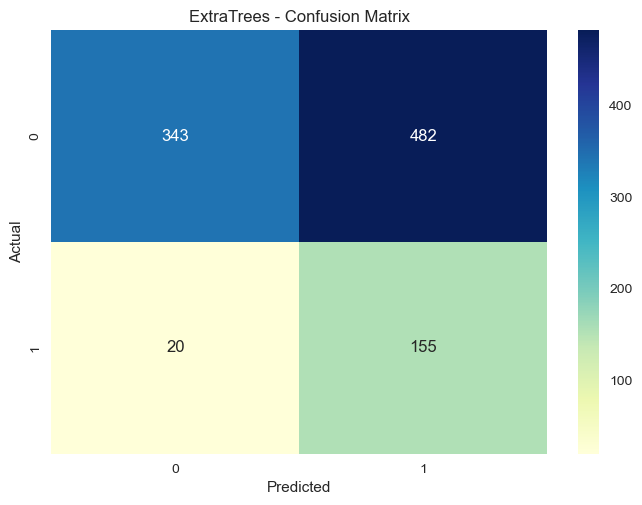


=== ExtraTrees ===
Best Threshold: 0.20
F1 Score: 0.3818
ROC AUC: 0.6673
              precision    recall  f1-score   support

           0       0.94      0.42      0.58       825
           1       0.24      0.89      0.38       175

    accuracy                           0.50      1000
   macro avg       0.59      0.65      0.48      1000
weighted avg       0.82      0.50      0.54      1000



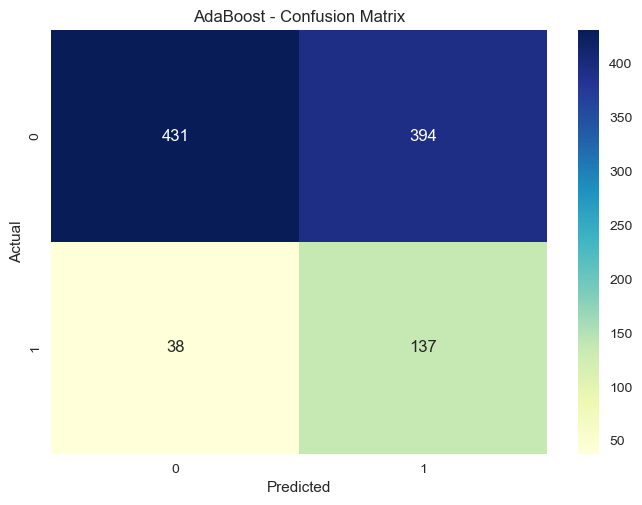


=== AdaBoost ===
Best Threshold: 0.50
F1 Score: 0.3881
ROC AUC: 0.6635
              precision    recall  f1-score   support

           0       0.92      0.52      0.67       825
           1       0.26      0.78      0.39       175

    accuracy                           0.57      1000
   macro avg       0.59      0.65      0.53      1000
weighted avg       0.80      0.57      0.62      1000



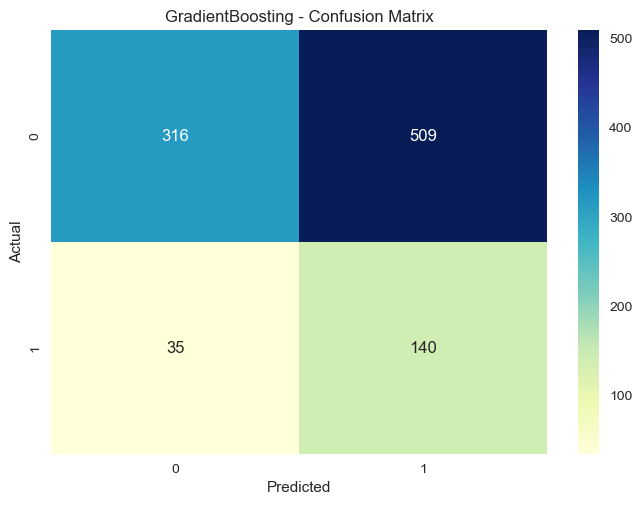


=== GradientBoosting ===
Best Threshold: 0.02
F1 Score: 0.3398
ROC AUC: 0.5924
              precision    recall  f1-score   support

           0       0.90      0.38      0.54       825
           1       0.22      0.80      0.34       175

    accuracy                           0.46      1000
   macro avg       0.56      0.59      0.44      1000
weighted avg       0.78      0.46      0.50      1000



,Model,Threshold,F1 Score,ROC AUC
0,XGBoost,0.08,0.3399,0.6116
1,RandomForest,0.37,0.3967,0.6760
2,ExtraTrees,0.20,0.3818,0.6673
3,AdaBoost,0.50,0.3881,0.6635
4,GradientBoosting,0.02,0.3398,0.5924


In [23]:
# Re-imports due to kernel reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, IsolationForest
)
from xgboost import XGBClassifier

# Step 1: Load Data
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)
y = df['Churn'].astype(int)
X = df.drop(columns=['Churn', 'cluster'])  # Drop both Churn and cluster

# Step 2: Identify column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Step 3: Isolation Forest outlier removal (OneHot + Scale for IsolationForest)
iso_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), [col for col in numerical_cols if col not in categorical_cols]),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train_encoded = iso_preprocessor.fit_transform(X_train)
iso = IsolationForest(contamination=0.05, random_state=42)
inliers_mask = iso.fit_predict(X_train_encoded) == 1
X_train_clean = X_train[inliers_mask]
y_train_clean = y_train[inliers_mask]

# Step 4: Preprocessing for pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]), [col for col in numerical_cols if col not in categorical_cols]),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Step 5: Optuna Tuning Functions
def build_objective(model_class, param_fn):
    def objective(trial):
        params = param_fn(trial)
        pipe = Pipeline([
            ("pre", preprocessor),
            ("model", model_class(**params))
        ])
        pipe.fit(X_train_clean, y_train_clean)
        preds = pipe.predict(X_test)
        return f1_score(y_test, preds)
    return objective

def xgb_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "subsample": t.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": t.suggest_float("colsample_bytree", 0.6, 1.0),
    "gamma": t.suggest_float("gamma", 0, 5),
    "reg_alpha": t.suggest_float("reg_alpha", 0, 1),
    "reg_lambda": t.suggest_float("reg_lambda", 0, 1),
    "use_label_encoder": False,
    "eval_metric": "logloss"
}

def rf_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "max_depth": t.suggest_int("max_depth", 3, 15),
    "min_samples_split": t.suggest_int("min_samples_split", 2, 10),
    "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 5)
}

def et_space(t): return rf_space(t)

def ada_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 50, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 1.0)
}

def gbc_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "subsample": t.suggest_float("subsample", 0.6, 1.0)
}

# Step 6: Tune and evaluate all individual models
model_spaces = {
    "XGBoost": (XGBClassifier, xgb_space),
    "RandomForest": (RandomForestClassifier, rf_space),
    "ExtraTrees": (ExtraTreesClassifier, et_space),
    "AdaBoost": (AdaBoostClassifier, ada_space),
    "GradientBoosting": (GradientBoostingClassifier, gbc_space)
}

results = []

for name, (model_class, param_func) in model_spaces.items():
    study = optuna.create_study(direction="maximize")
    study.optimize(build_objective(model_class, param_func), n_trials=30)
    best_model = model_class(**study.best_trial.params)

    pipe = ImbPipeline([
        ("pre", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", best_model)
    ])

    pipe.fit(X_train_clean, y_train_clean)
    probs = pipe.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1s)
    best_thresh = thresh[best_idx]
    preds = (probs >= best_thresh).astype(int)

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(f"\n=== {name} ===")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"F1 Score: {f1s[best_idx]:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")
    print(classification_report(y_test, preds))

    results.append({
        "Model": name,
        "Threshold": round(best_thresh, 2),
        "F1 Score": round(f1s[best_idx], 4),
        "ROC AUC": round(roc_auc_score(y_test, probs), 4)
    })

pd.DataFrame(results)


## ensemble models

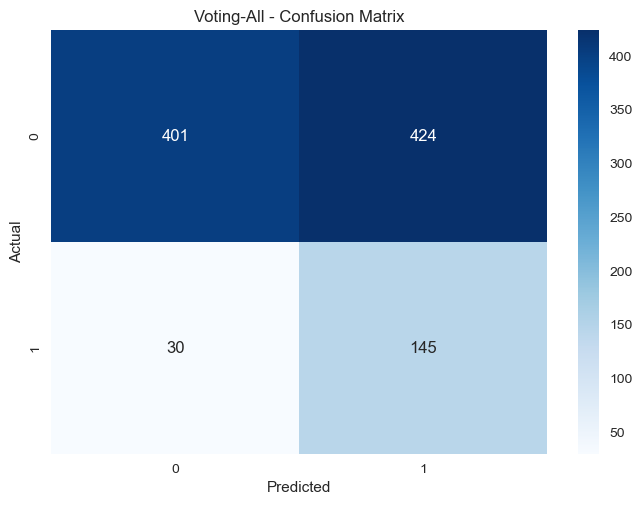


=== Voting-All ===
Best Threshold: 0.24
F1 Score: 0.3898
ROC AUC: 0.6613
              precision    recall  f1-score   support

           0       0.93      0.49      0.64       825
           1       0.25      0.83      0.39       175

    accuracy                           0.55      1000
   macro avg       0.59      0.66      0.51      1000
weighted avg       0.81      0.55      0.60      1000



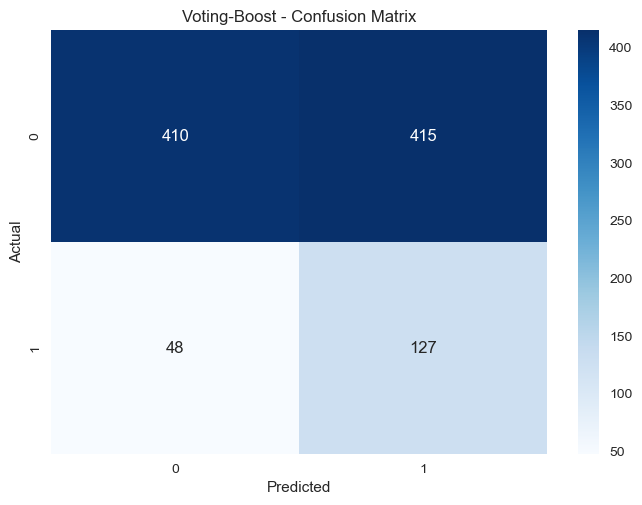


=== Voting-Boost ===
Best Threshold: 0.19
F1 Score: 0.3543
ROC AUC: 0.6276
              precision    recall  f1-score   support

           0       0.90      0.50      0.64       825
           1       0.23      0.73      0.35       175

    accuracy                           0.54      1000
   macro avg       0.56      0.61      0.50      1000
weighted avg       0.78      0.54      0.59      1000



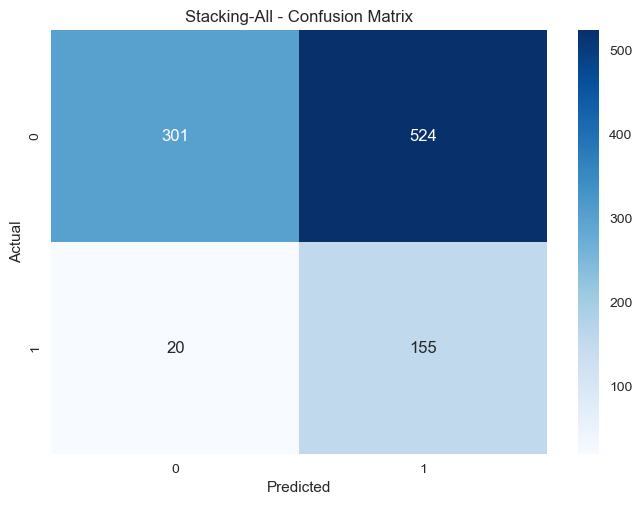


=== Stacking-All ===
Best Threshold: 0.06
F1 Score: 0.3630
ROC AUC: 0.6501
              precision    recall  f1-score   support

           0       0.94      0.36      0.53       825
           1       0.23      0.89      0.36       175

    accuracy                           0.46      1000
   macro avg       0.58      0.63      0.44      1000
weighted avg       0.81      0.46      0.50      1000



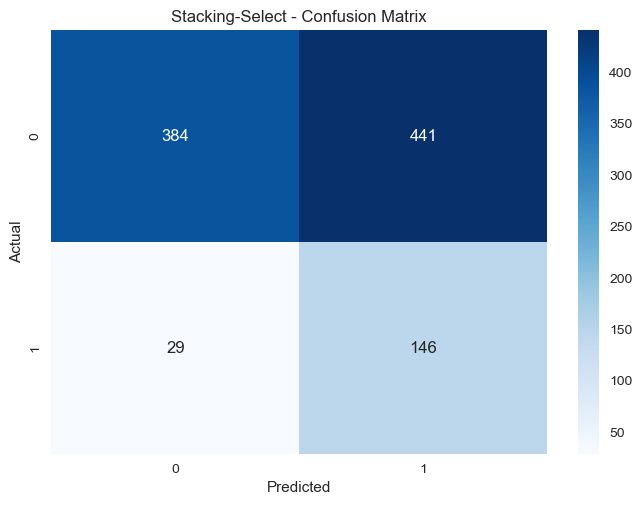


=== Stacking-Select ===
Best Threshold: 0.13
F1 Score: 0.3832
ROC AUC: 0.6545
              precision    recall  f1-score   support

           0       0.93      0.47      0.62       825
           1       0.25      0.83      0.38       175

    accuracy                           0.53      1000
   macro avg       0.59      0.65      0.50      1000
weighted avg       0.81      0.53      0.58      1000



,Model,Threshold,F1,ROC_AUC
0,Voting-All,0.24,0.3898,0.6613
1,Voting-Boost,0.19,0.3543,0.6276
2,Stacking-All,0.06,0.3630,0.6501
3,Stacking-Select,0.13,0.3832,0.6545


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier, IsolationForest
)
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder

# === Step 1: Load Data ===
df = pd.read_csv("cleaned_base_table.csv")
df.drop(columns=[col for col in df.columns if col.lower() == 'customerid'], inplace=True)
y = df['Churn'].astype(int)
X = df.drop(columns=['Churn', 'cluster'])


from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Define preprocessors for IsolationForest ---
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Add 'cluster' to categorical if not numeric
if 'cluster' in X.columns and not np.issubdtype(X['cluster'].dtype, np.number):
    categorical_cols.append('cluster')

# OneHot + Scale everything (required for IsolationForest)
iso_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), [col for col in numerical_cols if col not in categorical_cols]),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

# Transform data for outlier detection
X_train_encoded = pd.DataFrame(
    iso_preprocessor.fit_transform(X_train),
)

# Apply IsolationForest on transformed data
iso = IsolationForest(contamination=0.05, random_state=42)
inliers_mask = iso.fit_predict(X_train_encoded) == 1

# Filter training data
X_train_clean = X_train[inliers_mask]
y_train_clean = y_train[inliers_mask]

# === Step 3: Preprocessing ===
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler())
    ]), [col for col in numerical_cols if col not in categorical_cols]),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# === Step 4: Optuna Spaces ===
def build_objective(model_class, param_fn):
    def objective(trial):
        params = param_fn(trial)
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model_class(**params))
        ])
        pipe.fit(X_train_clean, y_train_clean)
        preds = pipe.predict(X_test)
        return f1_score(y_test, preds)
    return objective

def xgb_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "subsample": t.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": t.suggest_float("colsample_bytree", 0.6, 1.0),
    "gamma": t.suggest_float("gamma", 0, 5),
    "reg_alpha": t.suggest_float("reg_alpha", 0, 1),
    "reg_lambda": t.suggest_float("reg_lambda", 0, 1),
    "use_label_encoder": False,
    "eval_metric": "logloss"
}


def rf_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "max_depth": t.suggest_int("max_depth", 3, 15),
    "min_samples_split": t.suggest_int("min_samples_split", 2, 10),
    "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 5)
}

def et_space(t): return rf_space(t)

def ada_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 50, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 1.0)
}

def gbc_space(t): return {
    "n_estimators": t.suggest_int("n_estimators", 100, 300),
    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3),
    "max_depth": t.suggest_int("max_depth", 3, 10),
    "subsample": t.suggest_float("subsample", 0.6, 1.0)
}

# === Step 5: Tune Models ===
model_spaces = {
    "xgb": (XGBClassifier, xgb_space),
    "rf": (RandomForestClassifier, rf_space),
    "et": (ExtraTreesClassifier, et_space),
    "ada": (AdaBoostClassifier, ada_space),
    "gbc": (GradientBoostingClassifier, gbc_space)
}

tuned_models = {}
for name, (cls, param_fn) in model_spaces.items():
    study = optuna.create_study(direction="maximize")
    study.optimize(build_objective(cls, param_fn), n_trials=30)
    tuned_models[name] = cls(**study.best_trial.params)

# === Step 6: Define Ensembles ===
# 1. Voting - All
voting_all = VotingClassifier(estimators=[
    ("xgb", tuned_models["xgb"]),
    ("rf", tuned_models["rf"]),
    ("et", tuned_models["et"]),
    ("gbc", tuned_models["gbc"]),
    ("ada", tuned_models["ada"])
], voting="soft")

# 2. Voting - Boosters Only
voting_boost = VotingClassifier(estimators=[
    ("xgb", tuned_models["xgb"]),
    ("gbc", tuned_models["gbc"]),
    ("ada", tuned_models["ada"])
], voting="soft")

# 3. Stacking - All
stack_all = StackingClassifier(
    estimators=[
        ("xgb", tuned_models["xgb"]),
        ("rf", tuned_models["rf"]),
        ("et", tuned_models["et"]),
        ("gbc", tuned_models["gbc"]),
        ("ada", tuned_models["ada"])
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# 4. Stacking - Select Few
stack_sel = StackingClassifier(
    estimators=[
        ("xgb", tuned_models["xgb"]),
        ("gbc", tuned_models["gbc"]),
        ("rf", tuned_models["rf"])
    ],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# === Step 7: Build and Fit Pipelines ===
def build_pipe(model): return ImbPipeline([
    ("pre", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", model)
])

pipes = {
    "Voting-All": build_pipe(voting_all),
    "Voting-Boost": build_pipe(voting_boost),
    "Stacking-All": build_pipe(stack_all),
    "Stacking-Select": build_pipe(stack_sel)
}

probs = {}
for name, pipe in pipes.items():
    pipe.fit(X_train_clean, y_train_clean)
    probs[name] = pipe.predict_proba(X_test)[:, 1]

# === Step 8: Evaluation ===
def evaluate(name, y_true, y_probs):
    prec, rec, thresh = precision_recall_curve(y_true, y_probs)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1s)
    best_thresh = thresh[best_idx]
    preds = (y_probs >= best_thresh).astype(int)
    
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(f"\n=== {name} ===")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"F1 Score: {f1s[best_idx]:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_probs):.4f}")
    print(classification_report(y_true, preds))
    
    return {
        "Model": name,
        "Threshold": round(best_thresh, 2),
        "F1": round(f1s[best_idx], 4),
        "ROC_AUC": round(roc_auc_score(y_true, y_probs), 4)
    }

summary = []
for name, prob in probs.items():
    summary.append(evaluate(name, y_test, prob))

# === Step 9: Summary Table ===
pd.DataFrame(summary)
